# Определение стоимости автомобилей

## Подготовка данных

###  Загрузка библиотек

In [1]:
!pip install -q pyod
!pip install -q feature_engine
!pip install -q phik
!pip install -q sweetviz
!pip install --upgrade -q scikit-learn
!pip install -q category_encoders
!pip install -q catboost
!pip install lightgbm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 9.4 MB/s eta 0:00:00:00:0100:01


In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Lasso, Ridge

import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv
import phik
from phik import phik_matrix
from phik.report import plot_correlation_matrix
from phik import report

import time

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from catboost import Pool, CatBoostRegressor, cv
import category_encoders as ce
import lightgbm as lgb
from sklearn.metrics import mean_squared_error

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler
)

import warnings
warnings.filterwarnings('ignore')

### Загрузка файла с данными

In [3]:
data = pd.read_csv('/datasets/autos.csv')

In [4]:
data.head()

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Kilometer          354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  Repaired           283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtypes: int64(7), object(

В нашем распоряжении данные о технических характеристиках, комплектации и ценах других автомобилей.  
В датасете 16 столбцов и 354369 строк.

**числовые признаки:**

* Price - цена (евро)
* RegistrationYear - год регистрации автомобиля
* Power — мощность (л. с.)  
* Kilometer - пробег (км)  
* RegistrationMonth — месяц регистрации автомобиля 
* NumberOfPictures — количество фотографий автомобиля  
* PostalCode - почтовый индекс владельца анкеты (пользователя)

**категориальные признаки:**  

* DateCrawled — дата скачивания анкеты из базы  
* VehicleType — тип автомобильного кузова
* Gearbox — тип коробки передач 
* Model — модель автомобиля 
* FuelType — тип топлива  
* Brand — марка автомобиля  
* Repaired — была машина в ремонте или нет  
* DateCreated — дата создания анкеты  
* LastSeen — дата последней активности пользователя   

### Предобработка данных

Заменим тип данных в столбцах с датами с object на datetime

In [6]:
date = ['DateCrawled', 'DateCreated', 'LastSeen']

for i in date:
    data[i] = pd.to_datetime(data[i], format='%Y.%m.%dT%H:%M:%S')

In [7]:
data['DateCrawled'].dtypes
data['DateCreated'].dtypes
data['LastSeen'].dtypes

dtype('<M8[ns]')

Проверим количество пропущенных значений для каждого столбца

In [8]:
data.isna().sum()

DateCrawled              0
Price                    0
VehicleType          37490
RegistrationYear         0
Gearbox              19833
Power                    0
Model                19705
Kilometer                0
RegistrationMonth        0
FuelType             32895
Brand                    0
Repaired             71154
DateCreated              0
NumberOfPictures         0
PostalCode               0
LastSeen                 0
dtype: int64

В датасете есть пропуски в 5 столбцах с категориальными значениями:  
VehicleType, Gearbox, Model, FuelType, Repaired.

Изучим данные в этих столбцах внимательнее:

In [9]:
# Выведем уникальные значения в колонке VehicleType
data['VehicleType'].unique()

array([nan, 'coupe', 'suv', 'small', 'sedan', 'convertible', 'bus',
       'wagon', 'other'], dtype=object)

Всего 8 уникальных значений, остальное - пропуски

In [10]:
# Выведем уникальные значения в колонке Gearbox
data['Gearbox'].unique()

array(['manual', 'auto', nan], dtype=object)

2 уникальных значения, остальное - пропуски

In [11]:
# Выведем уникальные значения в колонке Model
data['Model'].sort_values(ascending=True).unique()

array(['100', '145', '147', '156', '159', '1_reihe', '1er', '200',
       '2_reihe', '300c', '3_reihe', '3er', '4_reihe', '500', '5_reihe',
       '5er', '601', '6_reihe', '6er', '7er', '80', '850', '90', '900',
       '9000', '911', 'a1', 'a2', 'a3', 'a4', 'a5', 'a6', 'a8',
       'a_klasse', 'accord', 'agila', 'alhambra', 'almera', 'altea',
       'amarok', 'antara', 'arosa', 'astra', 'auris', 'avensis', 'aveo',
       'aygo', 'b_klasse', 'b_max', 'beetle', 'berlingo', 'bora',
       'boxster', 'bravo', 'c1', 'c2', 'c3', 'c4', 'c5', 'c_klasse',
       'c_max', 'c_reihe', 'caddy', 'calibra', 'captiva', 'carisma',
       'carnival', 'cayenne', 'cc', 'ceed', 'charade', 'cherokee',
       'citigo', 'civic', 'cl', 'clio', 'clk', 'clubman', 'colt', 'combo',
       'cooper', 'cordoba', 'corolla', 'corsa', 'cr_reihe', 'croma',
       'crossfire', 'cuore', 'cx_reihe', 'defender', 'delta', 'discovery',
       'doblo', 'ducato', 'duster', 'e_klasse', 'elefantino', 'eos',
       'escort', 'espac

In [12]:
data['Model'].nunique()

250

250 уникальных моделей автомобилей в том числе пропуски. 
Каких-либо ошибок, неявных дублей не выявлено.

In [13]:
# Выведем уникальные значения в колонке FuelType
data['FuelType'].unique()

array(['petrol', 'gasoline', nan, 'lpg', 'other', 'hybrid', 'cng',
       'electric'], dtype=object)

7 уникальных значения, остальное - пропуски.

In [14]:
# Выведем уникальные значения в колонке Repaired
data['Repaired'].unique()

array([nan, 'yes', 'no'], dtype=object)

2 уникальных значения, остальное - пропуски.

Пропуски в данных скорее всего допушены из-за отсутсутствия информации об автомобилях или по невнимательности.  
Пропуски можно попробовать восстановить, обратившись к клиенту. Самостоятельно же мы не можем восстановить эти данные.  

Предлагается не удалять такие строки, а воспользоваться "заглушками". В столбцах Gearbox, Repaired вместо пропусков поставим 'unknown'. В FuelType, VehicleType, Model для некоторых значений определена категория 'other'. Подставим это значение для пропусков.  

In [15]:
nans = ['Gearbox', 'Repaired']
data[nans] = data[nans].fillna('unknown')

In [16]:
nans = ['FuelType', 'VehicleType', 'Model']

data[nans] = data[nans].fillna('other')

Снова проверим датасет на пропущенные значения:

In [17]:
data.isna().sum()

DateCrawled          0
Price                0
VehicleType          0
RegistrationYear     0
Gearbox              0
Power                0
Model                0
Kilometer            0
RegistrationMonth    0
FuelType             0
Brand                0
Repaired             0
DateCreated          0
NumberOfPictures     0
PostalCode           0
LastSeen             0
dtype: int64

Избавились от пропусков

In [18]:
# Дополнительно проверим на уникальность, неявные дубли еще один категориальный признак Brand
data['Brand'].unique()

array(['volkswagen', 'audi', 'jeep', 'skoda', 'bmw', 'peugeot', 'ford',
       'mazda', 'nissan', 'renault', 'mercedes_benz', 'opel', 'seat',
       'citroen', 'honda', 'fiat', 'mini', 'smart', 'hyundai',
       'sonstige_autos', 'alfa_romeo', 'subaru', 'volvo', 'mitsubishi',
       'kia', 'suzuki', 'lancia', 'toyota', 'chevrolet', 'dacia',
       'daihatsu', 'trabant', 'saab', 'chrysler', 'jaguar', 'daewoo',
       'porsche', 'rover', 'land_rover', 'lada'], dtype=object)

In [19]:
data['Brand'].nunique()

40

40 брендов автомобилей. Ошибок, неявных дублей не обнаружено.

Проверим данные на явные дубликаты

In [20]:
data.duplicated().sum()

4

In [21]:
# Удалим явные дубли
data = data.drop_duplicates()

In [22]:
data.duplicated().sum()

0

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 354365 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   DateCrawled        354365 non-null  datetime64[ns]
 1   Price              354365 non-null  int64         
 2   VehicleType        354365 non-null  object        
 3   RegistrationYear   354365 non-null  int64         
 4   Gearbox            354365 non-null  object        
 5   Power              354365 non-null  int64         
 6   Model              354365 non-null  object        
 7   Kilometer          354365 non-null  int64         
 8   RegistrationMonth  354365 non-null  int64         
 9   FuelType           354365 non-null  object        
 10  Brand              354365 non-null  object        
 11  Repaired           354365 non-null  object        
 12  DateCreated        354365 non-null  datetime64[ns]
 13  NumberOfPictures   354365 non-null  int64   

Проверим даты выгрузки анкет

In [24]:
data['DateCrawled'].sort_values(ascending=True).unique()

array(['2016-03-05T14:06:22.000000000', '2016-03-05T14:06:23.000000000',
       '2016-03-05T14:06:24.000000000', ...,
       '2016-04-07T14:36:55.000000000', '2016-04-07T14:36:56.000000000',
       '2016-04-07T14:36:58.000000000'], dtype='datetime64[ns]')

Все данные относятся к 2016 г.

Удалим также признаки, не повлияющих на обучение моделей в дальнейшем

In [25]:
data.drop(columns=['DateCrawled', 'DateCreated', 'NumberOfPictures',
                    'PostalCode', 'LastSeen', 'RegistrationMonth'],
           axis=1,
           inplace=True)

Еще раз проверим датасет на явные дубликаты

In [26]:
data.duplicated().sum()

45187

Пока что оставим эти дубли в датасете

In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 354365 entries, 0 to 354368
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Price             354365 non-null  int64 
 1   VehicleType       354365 non-null  object
 2   RegistrationYear  354365 non-null  int64 
 3   Gearbox           354365 non-null  object
 4   Power             354365 non-null  int64 
 5   Model             354365 non-null  object
 6   Kilometer         354365 non-null  int64 
 7   FuelType          354365 non-null  object
 8   Brand             354365 non-null  object
 9   Repaired          354365 non-null  object
dtypes: int64(4), object(6)
memory usage: 29.7+ MB


### Исследовательский анализ данных

Воспользуемся библиотекой sweetviz для визуализации основной информации о данных датасета

                                             |          | [  0%]   00:00 -> (? left)


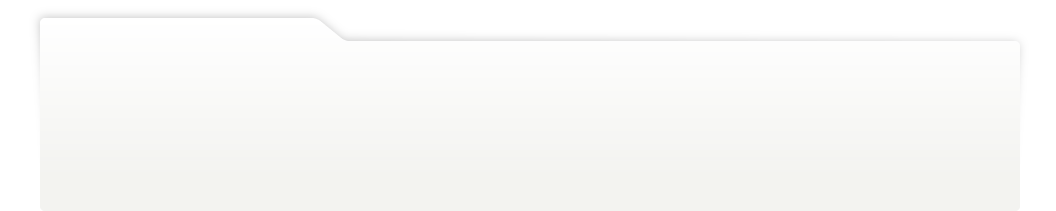
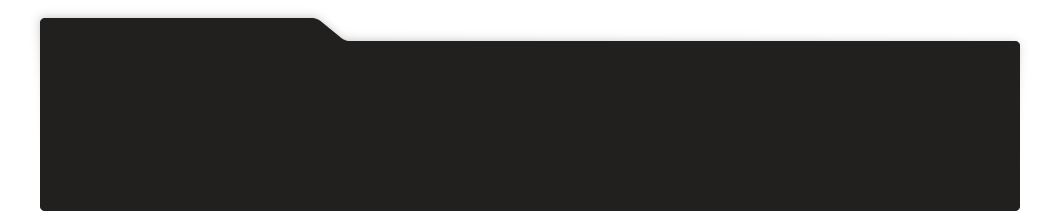
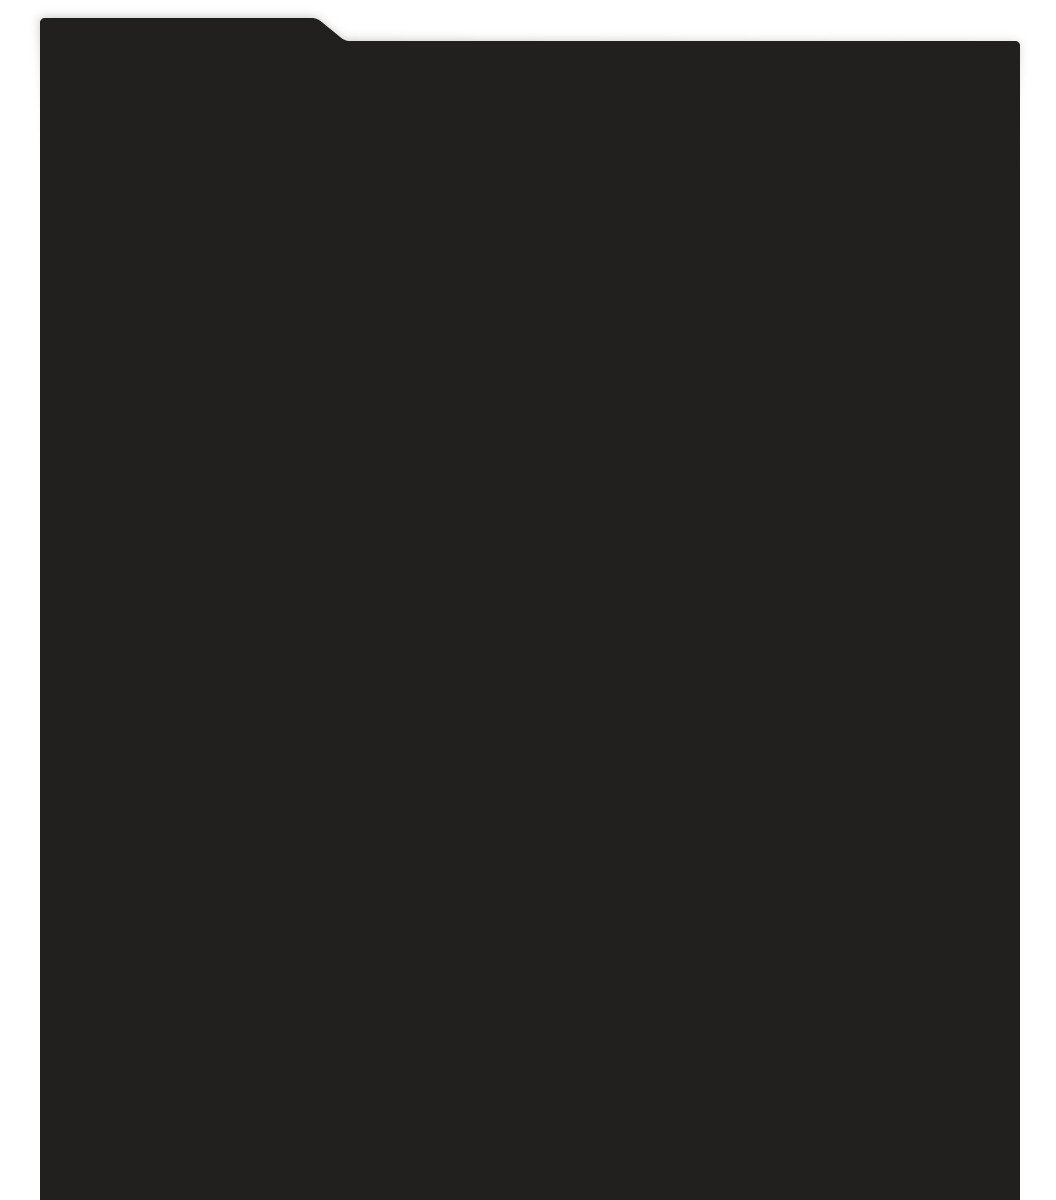
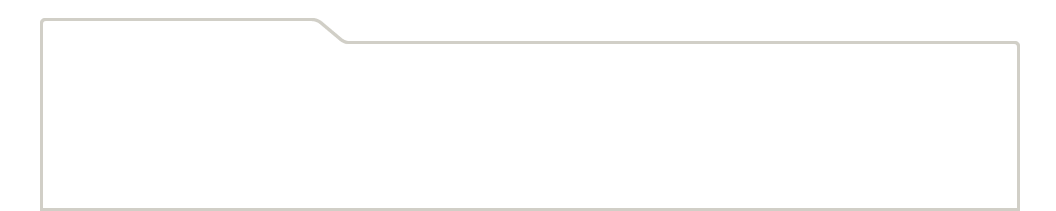
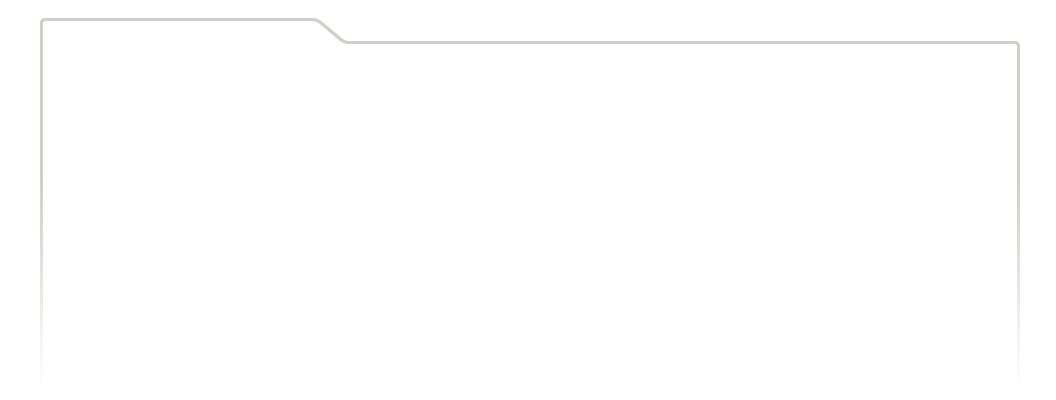
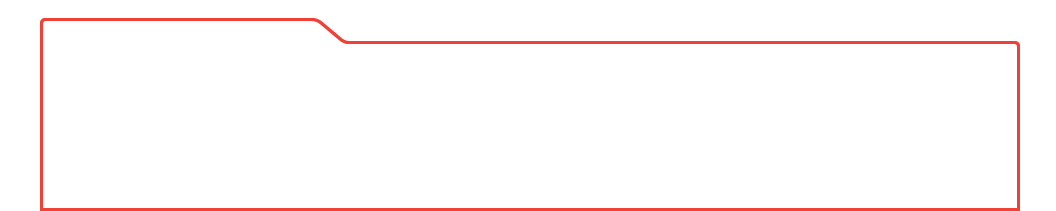
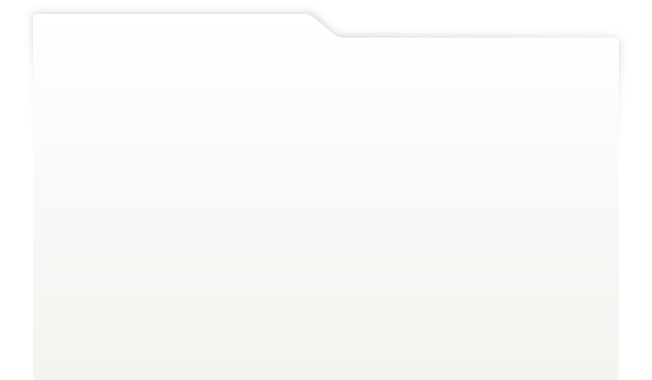
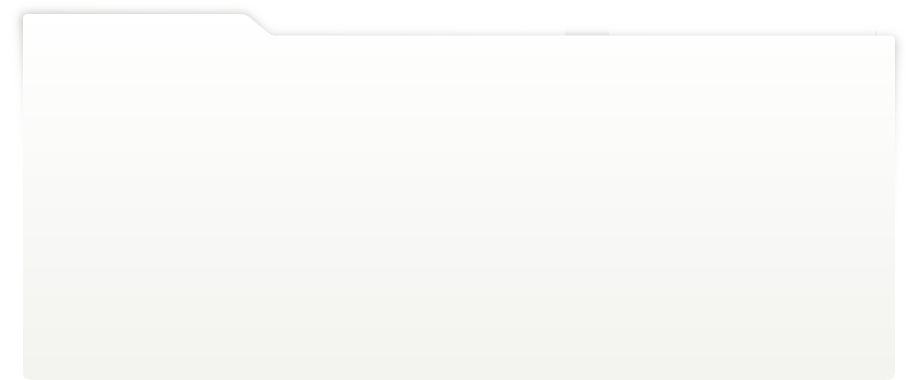
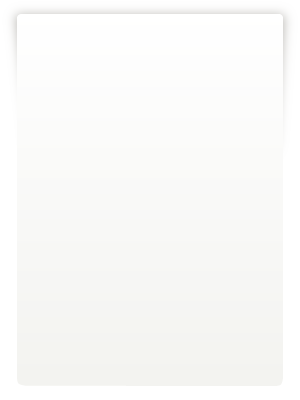
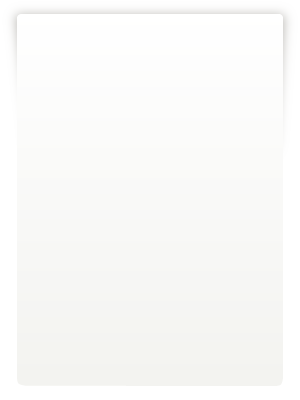
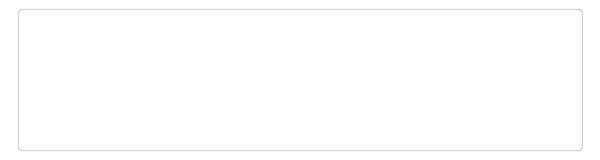
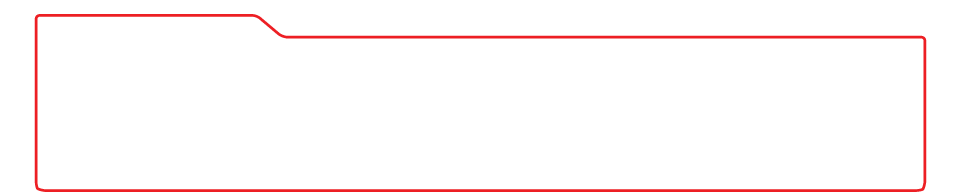
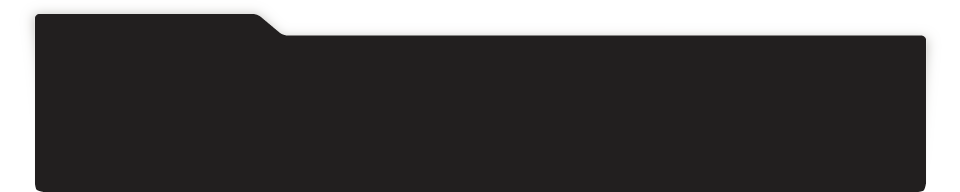
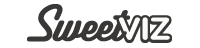
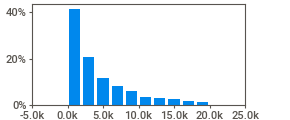
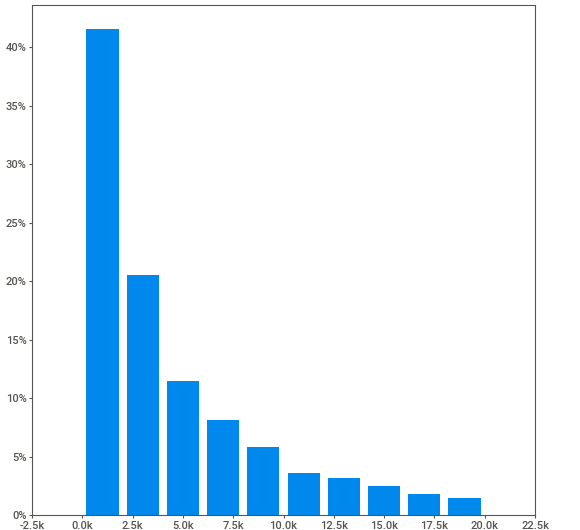
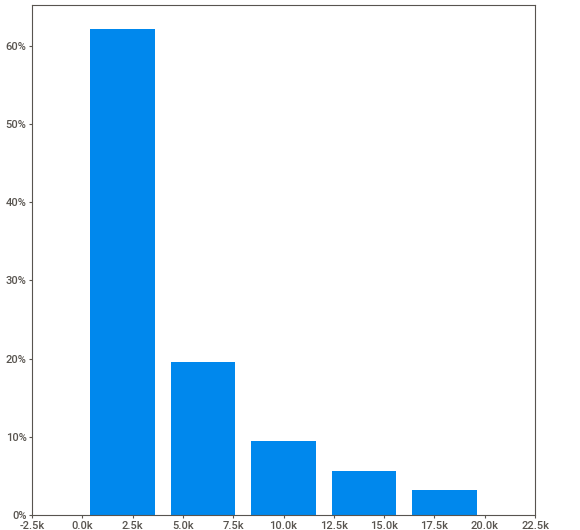
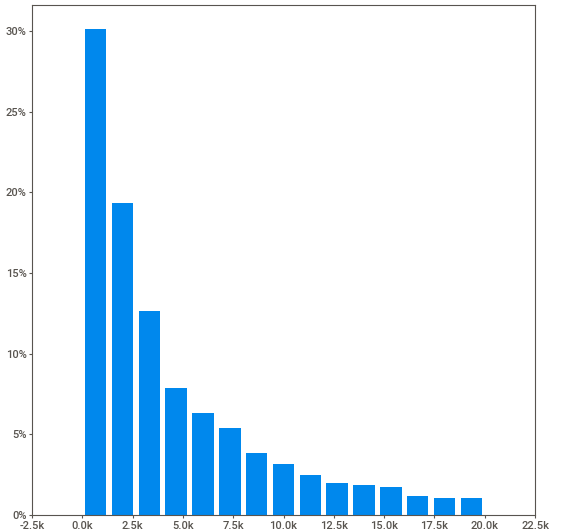
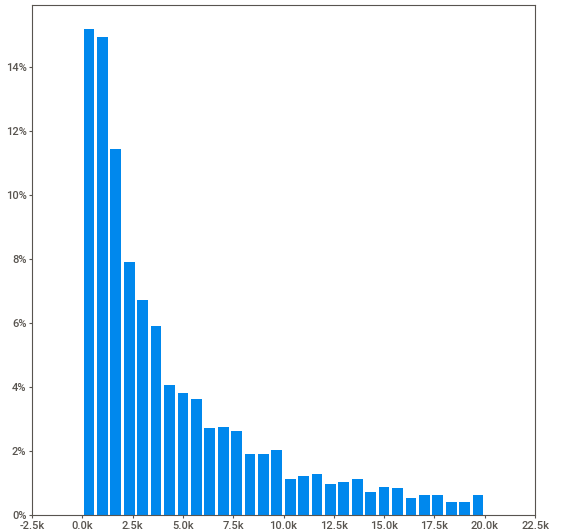
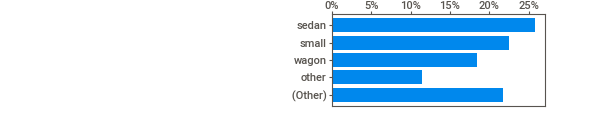
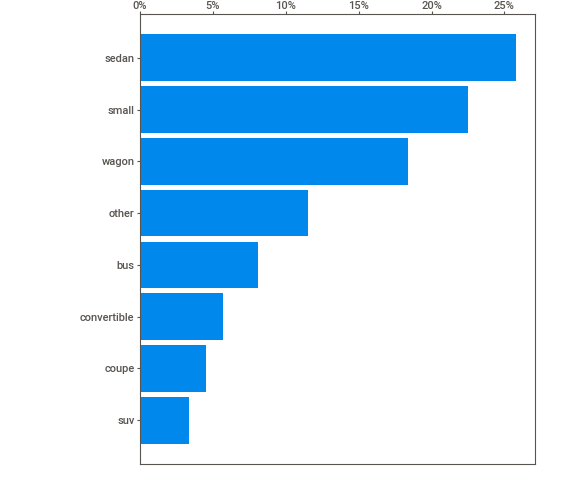
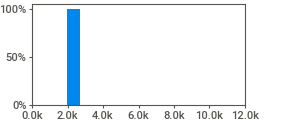
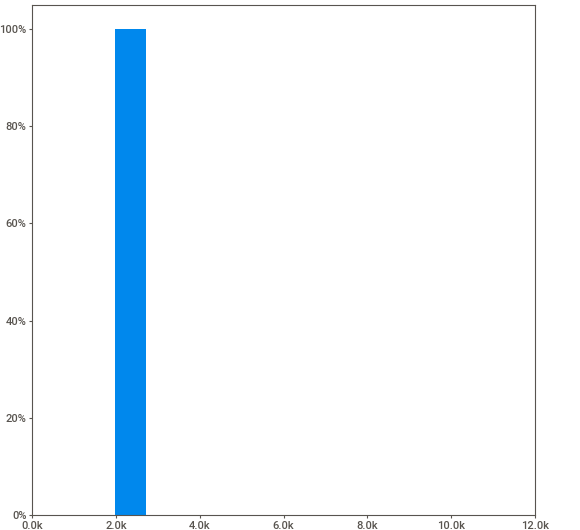
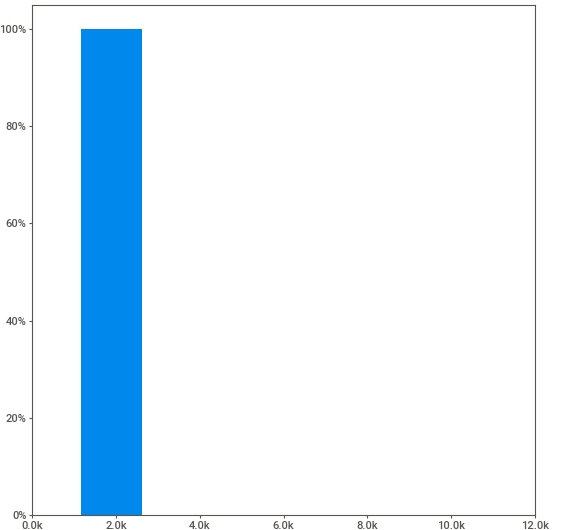
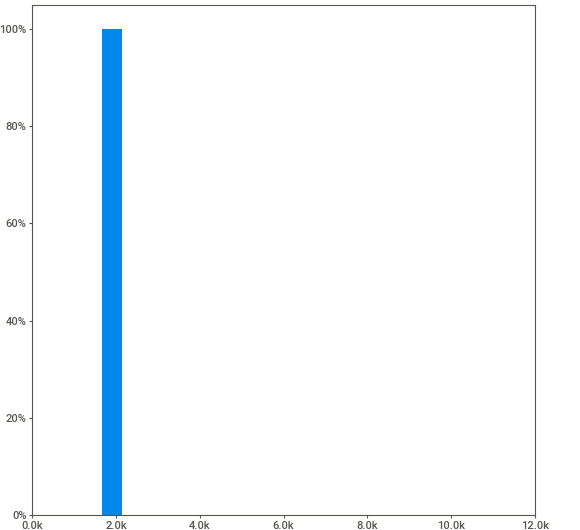
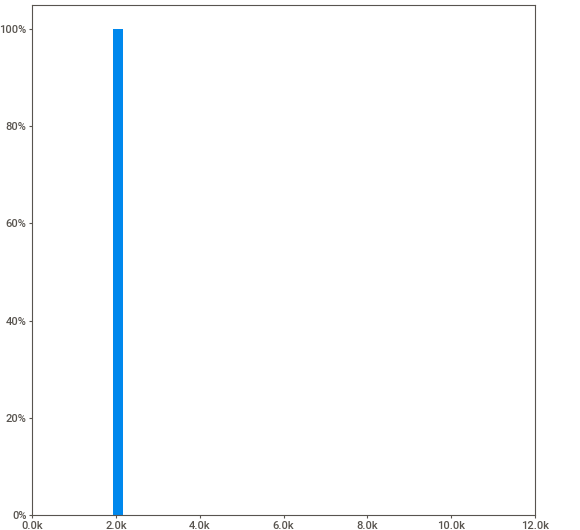
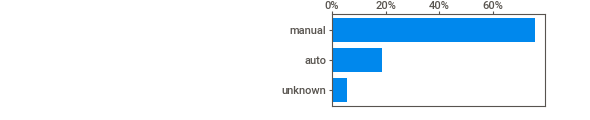
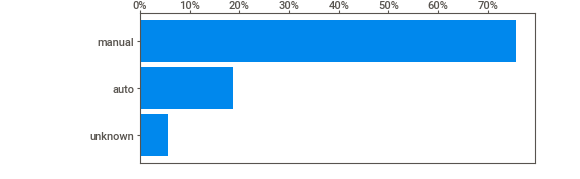
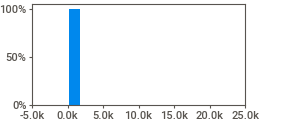
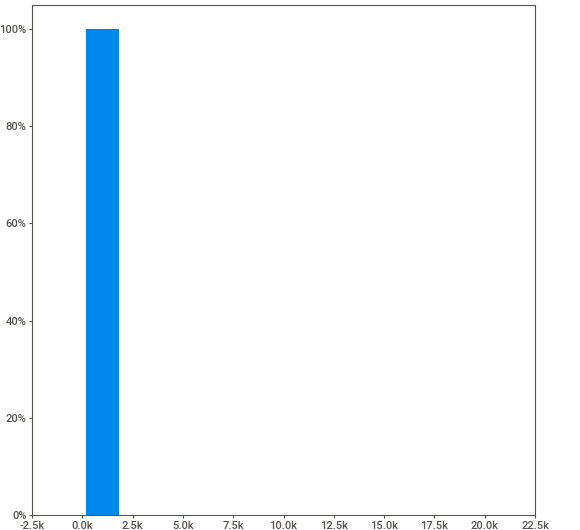
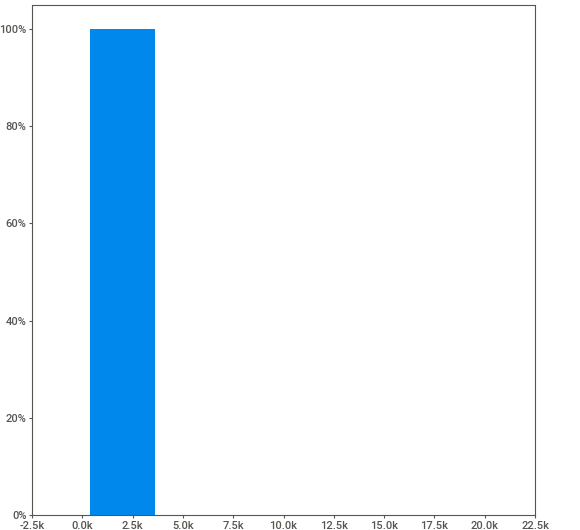
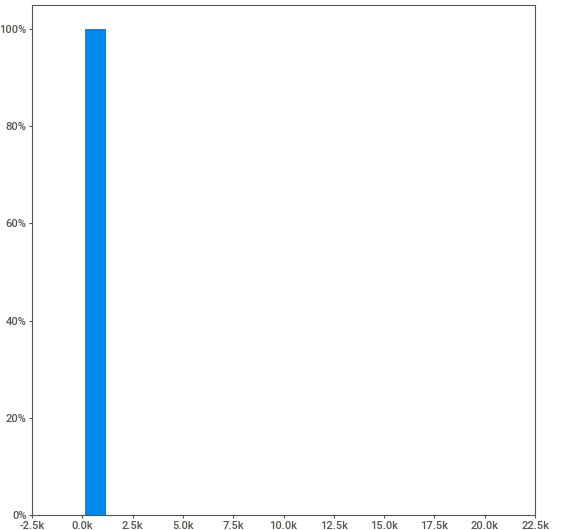
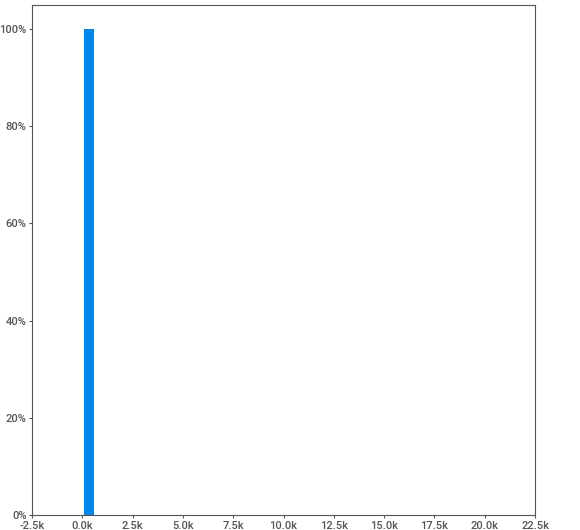
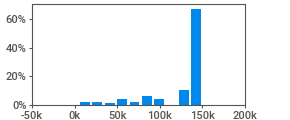
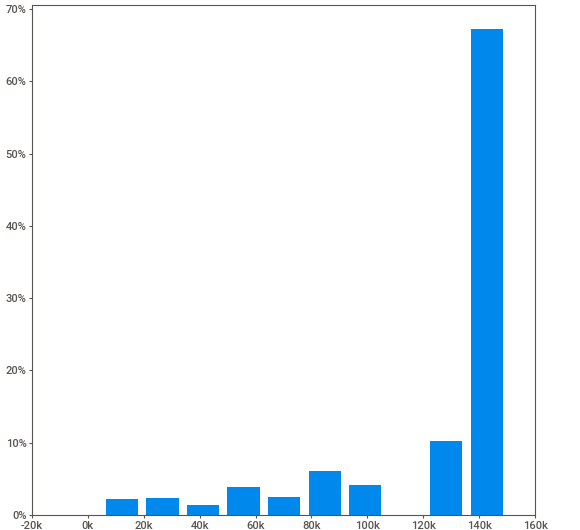
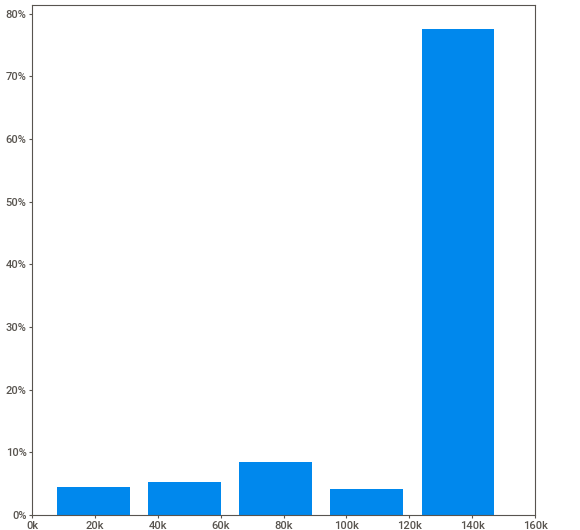
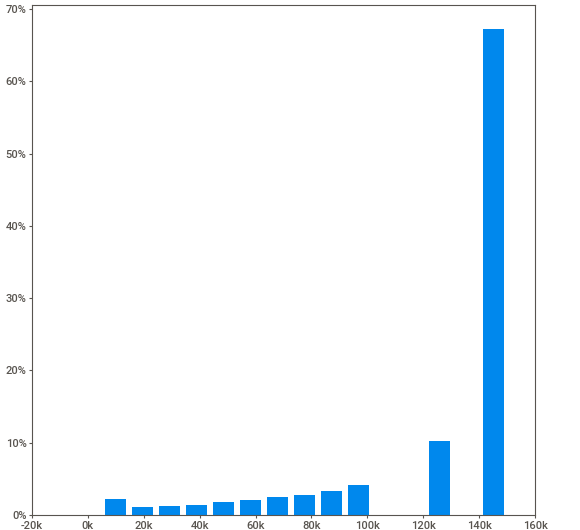
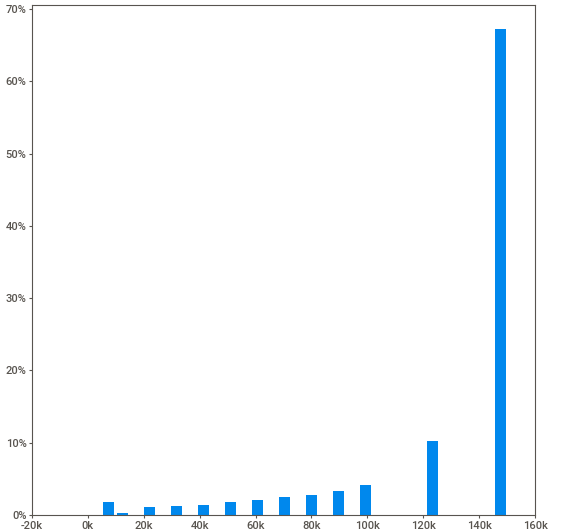
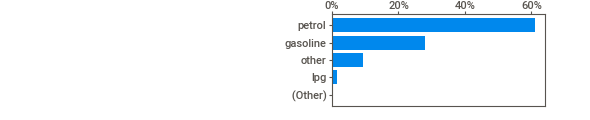
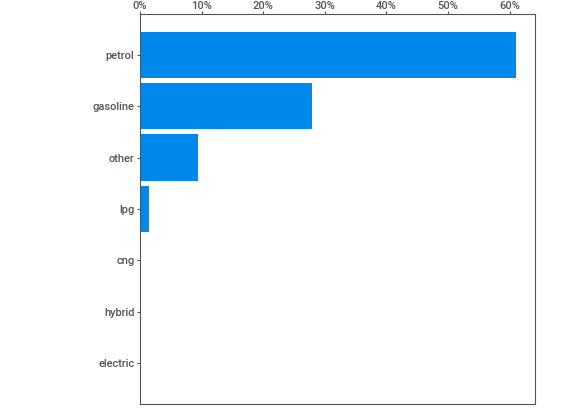
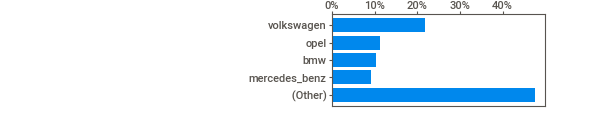
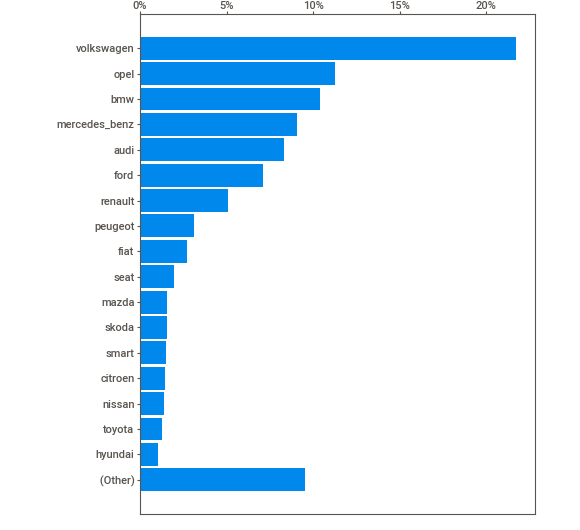
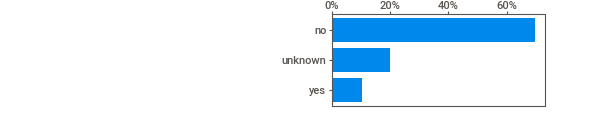
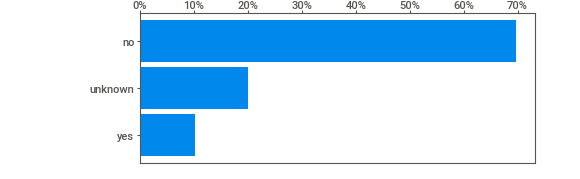
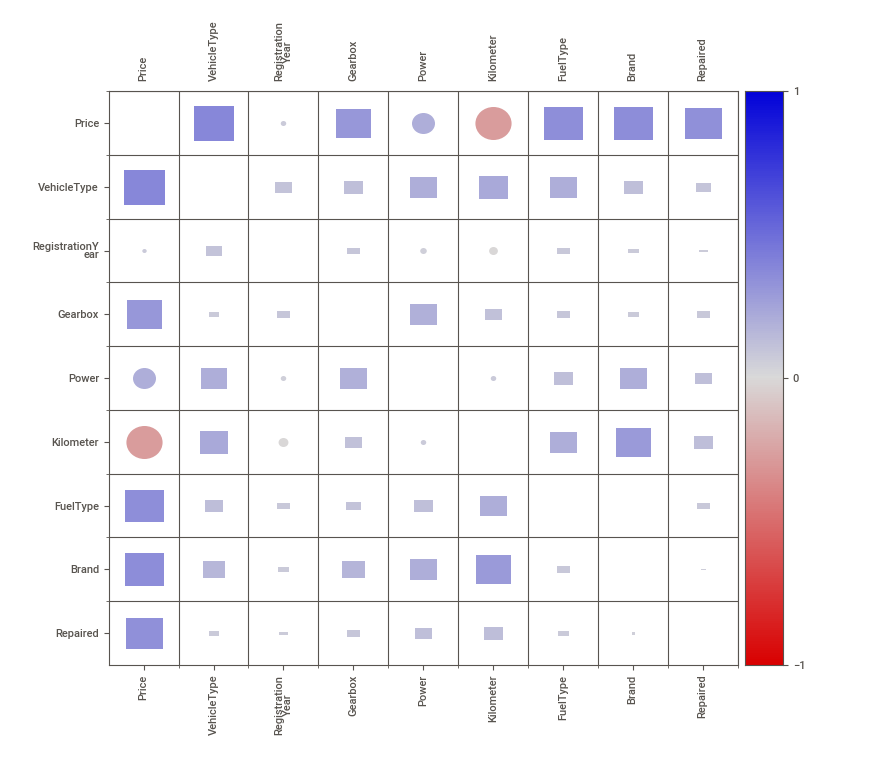
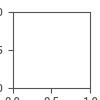

In [28]:
report = sv.analyze(data)
report.show_notebook()

Получили информативный и наглядный отчет о данных автомобилей.   

Наблюдаются некоторые аномалии и выбросы в числовых значениях:   

* Price: min стоимость автомобиля 0 евро (то есть бесплатно)  
* RegistrationYear: min год регистрации автомобиля 1000 г, max - 9999 г.  
* Power: min мощность (л. с.) автомобиля 0 и max - 20000  

Рассмотрим данные их этих столбцов внимательнее.  

In [29]:
# Выведем уникальные значения столбца RegistrationYear
data['RegistrationYear'].sort_values(ascending=True).unique()

array([1000, 1001, 1039, 1111, 1200, 1234, 1253, 1255, 1300, 1400, 1500,
       1600, 1602, 1688, 1800, 1910, 1915, 1919, 1920, 1923, 1925, 1927,
       1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938,
       1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949, 1950,
       1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961,
       1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972,
       1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983,
       1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994,
       1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005,
       2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016,
       2017, 2018, 2019, 2066, 2200, 2222, 2290, 2500, 2800, 2900, 3000,
       3200, 3500, 3700, 3800, 4000, 4100, 4500, 4800, 5000, 5300, 5555,
       5600, 5900, 5911, 6000, 6500, 7000, 7100, 7500, 7800, 8000, 8200,
       8455, 8500, 8888, 9000, 9229, 9450, 9996, 99

В данных присутствуют нереалистичные значения годов регистрации автомобиля.  
Для начала исключим все данные до 1950 г и после 2019 г.   
Затем построим график "ящик с усами", чтобы посмотреть разброс данных по годам.  

Исправила границу года до 2016

In [30]:
data = data[(data['RegistrationYear'] >= 1950) & (data['RegistrationYear'] <= 2016)]

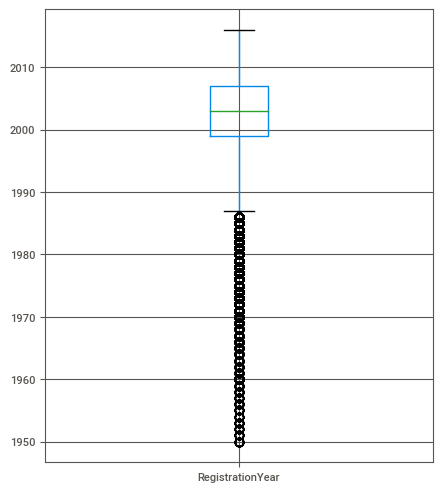

In [31]:
data['RegistrationYear'].plot(kind='box',
                             figsize=(5,6),
                             grid=True,
                             legend=True,
                             title='');

Наблюдаем выбросы на графике (редко встречаются автомобили старше 1985г), удалим их.

In [32]:
data = data[(data['RegistrationYear'] >= 1985)]

Построим такой же график для значений Power

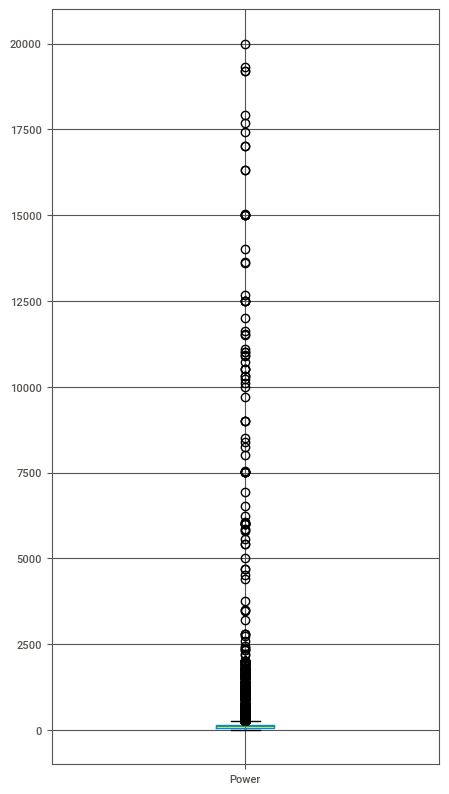

In [33]:
data['Power'].plot(kind='box',
                             figsize=(5,10),
                             grid=True,
                             legend=True,
                             title='');

В колонке Power очень необычные значения.   
Обычно мощность автомобилей находится в диапазоне от нескольких десятков до нескольких сотен лошадиных сил. В нашем же датасете мощность измеряется от 0 до 20000.  
Возможно здесь была допущена ошибка, пропущен какой-то разделитель между числами или стоят лишние нули.   
Просто 0, может быть, является заглушкой для данных, где отсутствуют значения.    

На практике можно было бы уточнить информацию у клиента. Самостоятельно восстановить значения будет сложно. 
Предлагается удалить аномалии и выбросы.  

In [34]:
# Посмотрим данные до 1000
data = data[(data['Power'] <= 1000)]

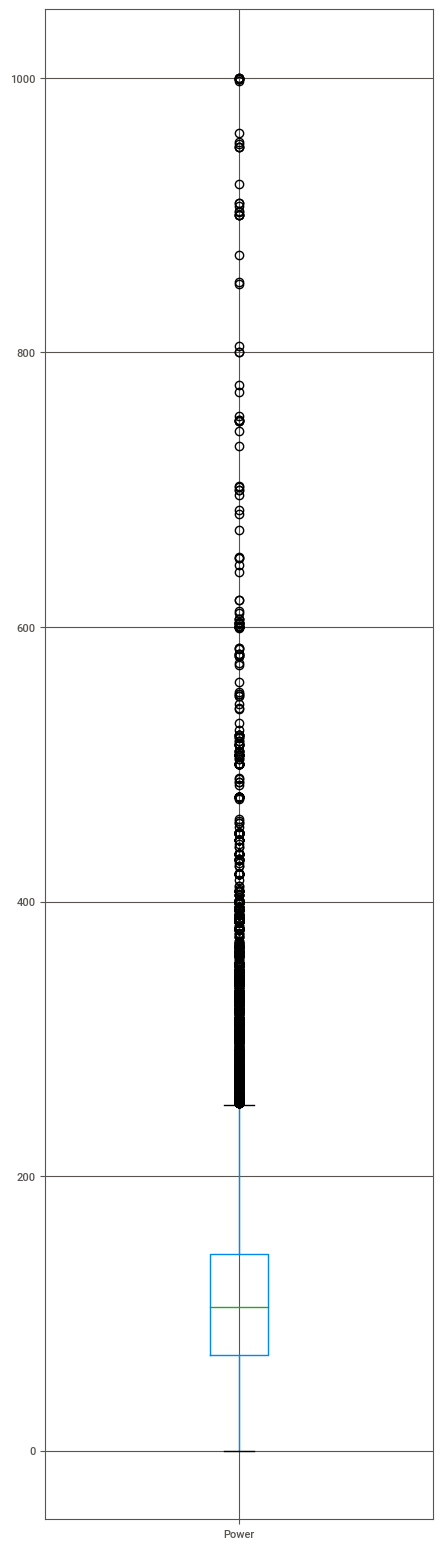

In [35]:
data['Power'].plot(kind='box',
                             figsize=(5,20),
                             grid=True,
                             legend=True,
                             title='');

In [36]:
# Оставим данные с мощностью до 400 (после 400 - редкие значения)
data = data[(data['Power'] <= 400)]

In [37]:
filtered_data = data[(data['Power'] >= 0) & (data['Power'] <= 57)]
counts_by_power = filtered_data['Power'].value_counts()
sorted_data = counts_by_power.sort_index()
print(sorted_data)

0     34859
1        27
2         9
3         7
4        30
5       102
6        10
7        11
8         6
9         3
10       10
11       26
12       13
13        3
14        9
15       13
16        6
17        6
18        5
19        8
20       11
21        1
22        1
23        7
24       14
25       10
26      183
27       28
28        2
29       14
30       10
31        7
32        4
33       45
34       60
35        5
36        4
37       42
38        5
39      112
40      285
41      429
42       46
43      104
44      307
45     2810
46       47
47       30
48       66
49       18
50     4215
51       89
52      286
53      195
54     5443
55     1929
56      258
57      123
Name: Power, dtype: int64


Большое количество 0 в данной колонке, скорее всего, это заглушка. Удалять не будем. Остальные данные тоже предлагается оставить.

Посмотрим распределение данных в колонке Kilometer

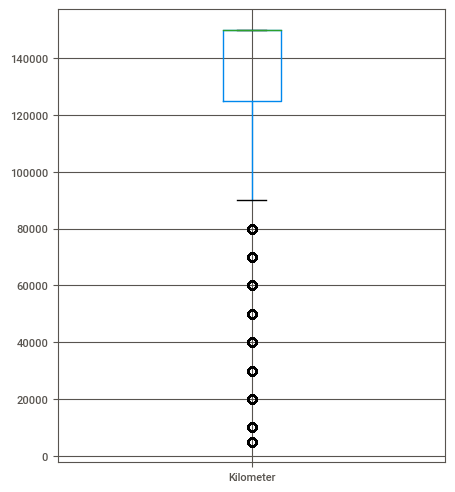

In [38]:
data['Kilometer'].plot(kind='box',
                             figsize=(5,6),
                             grid=True,
                             legend=True,
                             title='');

Удалим выбросы (значения до 90000)

In [39]:
data = data[data['Kilometer'] >= 90000]

In [40]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 284535 entries, 0 to 354368
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Price             284535 non-null  int64 
 1   VehicleType       284535 non-null  object
 2   RegistrationYear  284535 non-null  int64 
 3   Gearbox           284535 non-null  object
 4   Power             284535 non-null  int64 
 5   Model             284535 non-null  object
 6   Kilometer         284535 non-null  int64 
 7   FuelType          284535 non-null  object
 8   Brand             284535 non-null  object
 9   Repaired          284535 non-null  object
dtypes: int64(4), object(6)
memory usage: 23.9+ MB


Посмотрим распределение цен на автомобили (столбец Price)

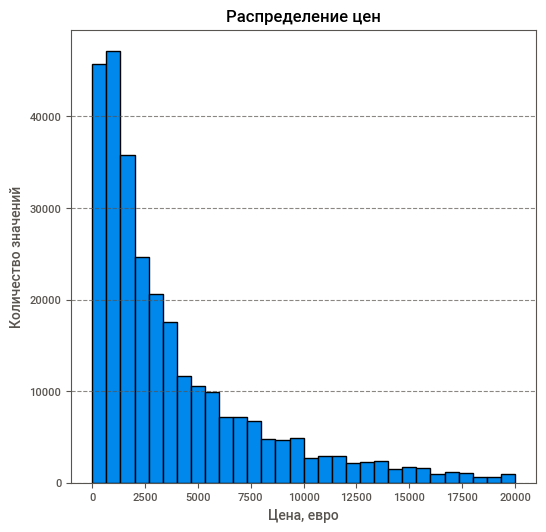

In [41]:
data['Price'].plot(kind='hist', bins=30, edgecolor='black', figsize=(6, 6))
plt.title('Распределение цен')
plt.xlabel('Цена, евро')
plt.ylabel('Количество значений')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Посмотрим внимательнее значения в диапазоне 0-2500 евро

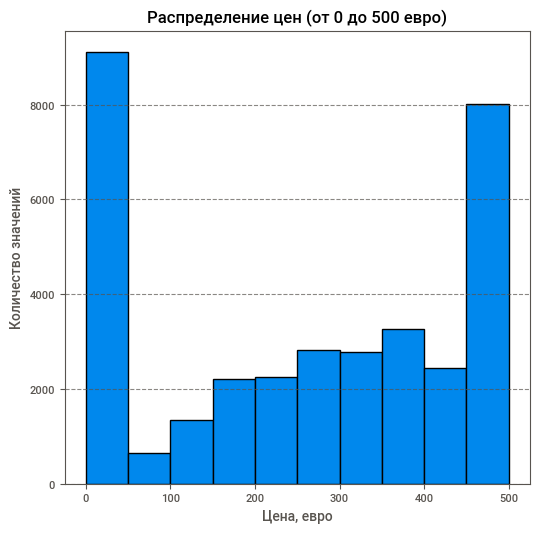

In [42]:
price_range = (0, 500)
filtered_data = data[(data['Price'] >= price_range[0]) & (data['Price'] <= price_range[1])]

filtered_data['Price'].plot(kind='hist', bins=10, edgecolor='black', figsize=(6, 6))
plt.title('Распределение цен (от 0 до 500 евро)')
plt.xlabel('Цена, евро')
plt.ylabel('Количество значений')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [43]:
filtered_data = data[(data['Price'] >= 0) & (data['Price'] <= 200)]
counts_by_power = filtered_data['Price'].value_counts()
sorted_data = counts_by_power.sort_index()
print(sorted_data)

0      8064
1       833
2         6
3         6
5        18
       ... 
195      11
196       1
198       3
199     247
200    1775
Name: Price, Length: 92, dtype: int64


Возможно, 0 в этом датасете тоже работают "заглушкой". Однако данных не так много, их можно будет удалить.  
Вызывают вопросы цены от 1 до 500 евро.

In [44]:
# Проверим еще раз основную информацию по колонке Price
data['Price'].describe().T

count    284535.000000
mean       3838.860312
std        4000.582905
min           0.000000
25%         999.000000
50%        2400.000000
75%        5300.000000
max       20000.000000
Name: Price, dtype: float64

In [45]:
# Проверим 5%
quantiles = data['Price'].quantile([0.05])
quantiles

0.05    200.0
Name: Price, dtype: float64

In [46]:
data = data[data['Price'] > 199]

In [47]:
# Проверим, какое количество данных у нас осталось после удаления части данных
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 271228 entries, 0 to 354368
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Price             271228 non-null  int64 
 1   VehicleType       271228 non-null  object
 2   RegistrationYear  271228 non-null  int64 
 3   Gearbox           271228 non-null  object
 4   Power             271228 non-null  int64 
 5   Model             271228 non-null  object
 6   Kilometer         271228 non-null  int64 
 7   FuelType          271228 non-null  object
 8   Brand             271228 non-null  object
 9   Repaired          271228 non-null  object
dtypes: int64(4), object(6)
memory usage: 22.8+ MB


Визуализируем взаимосвязь признаков с целевым ('Price')

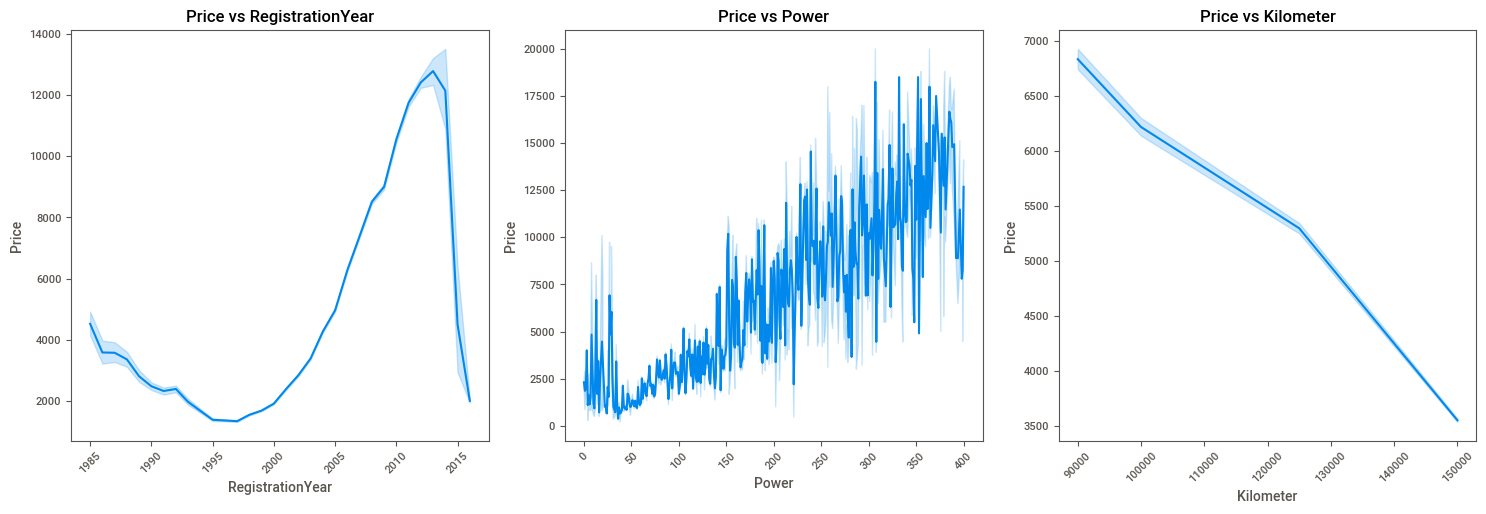

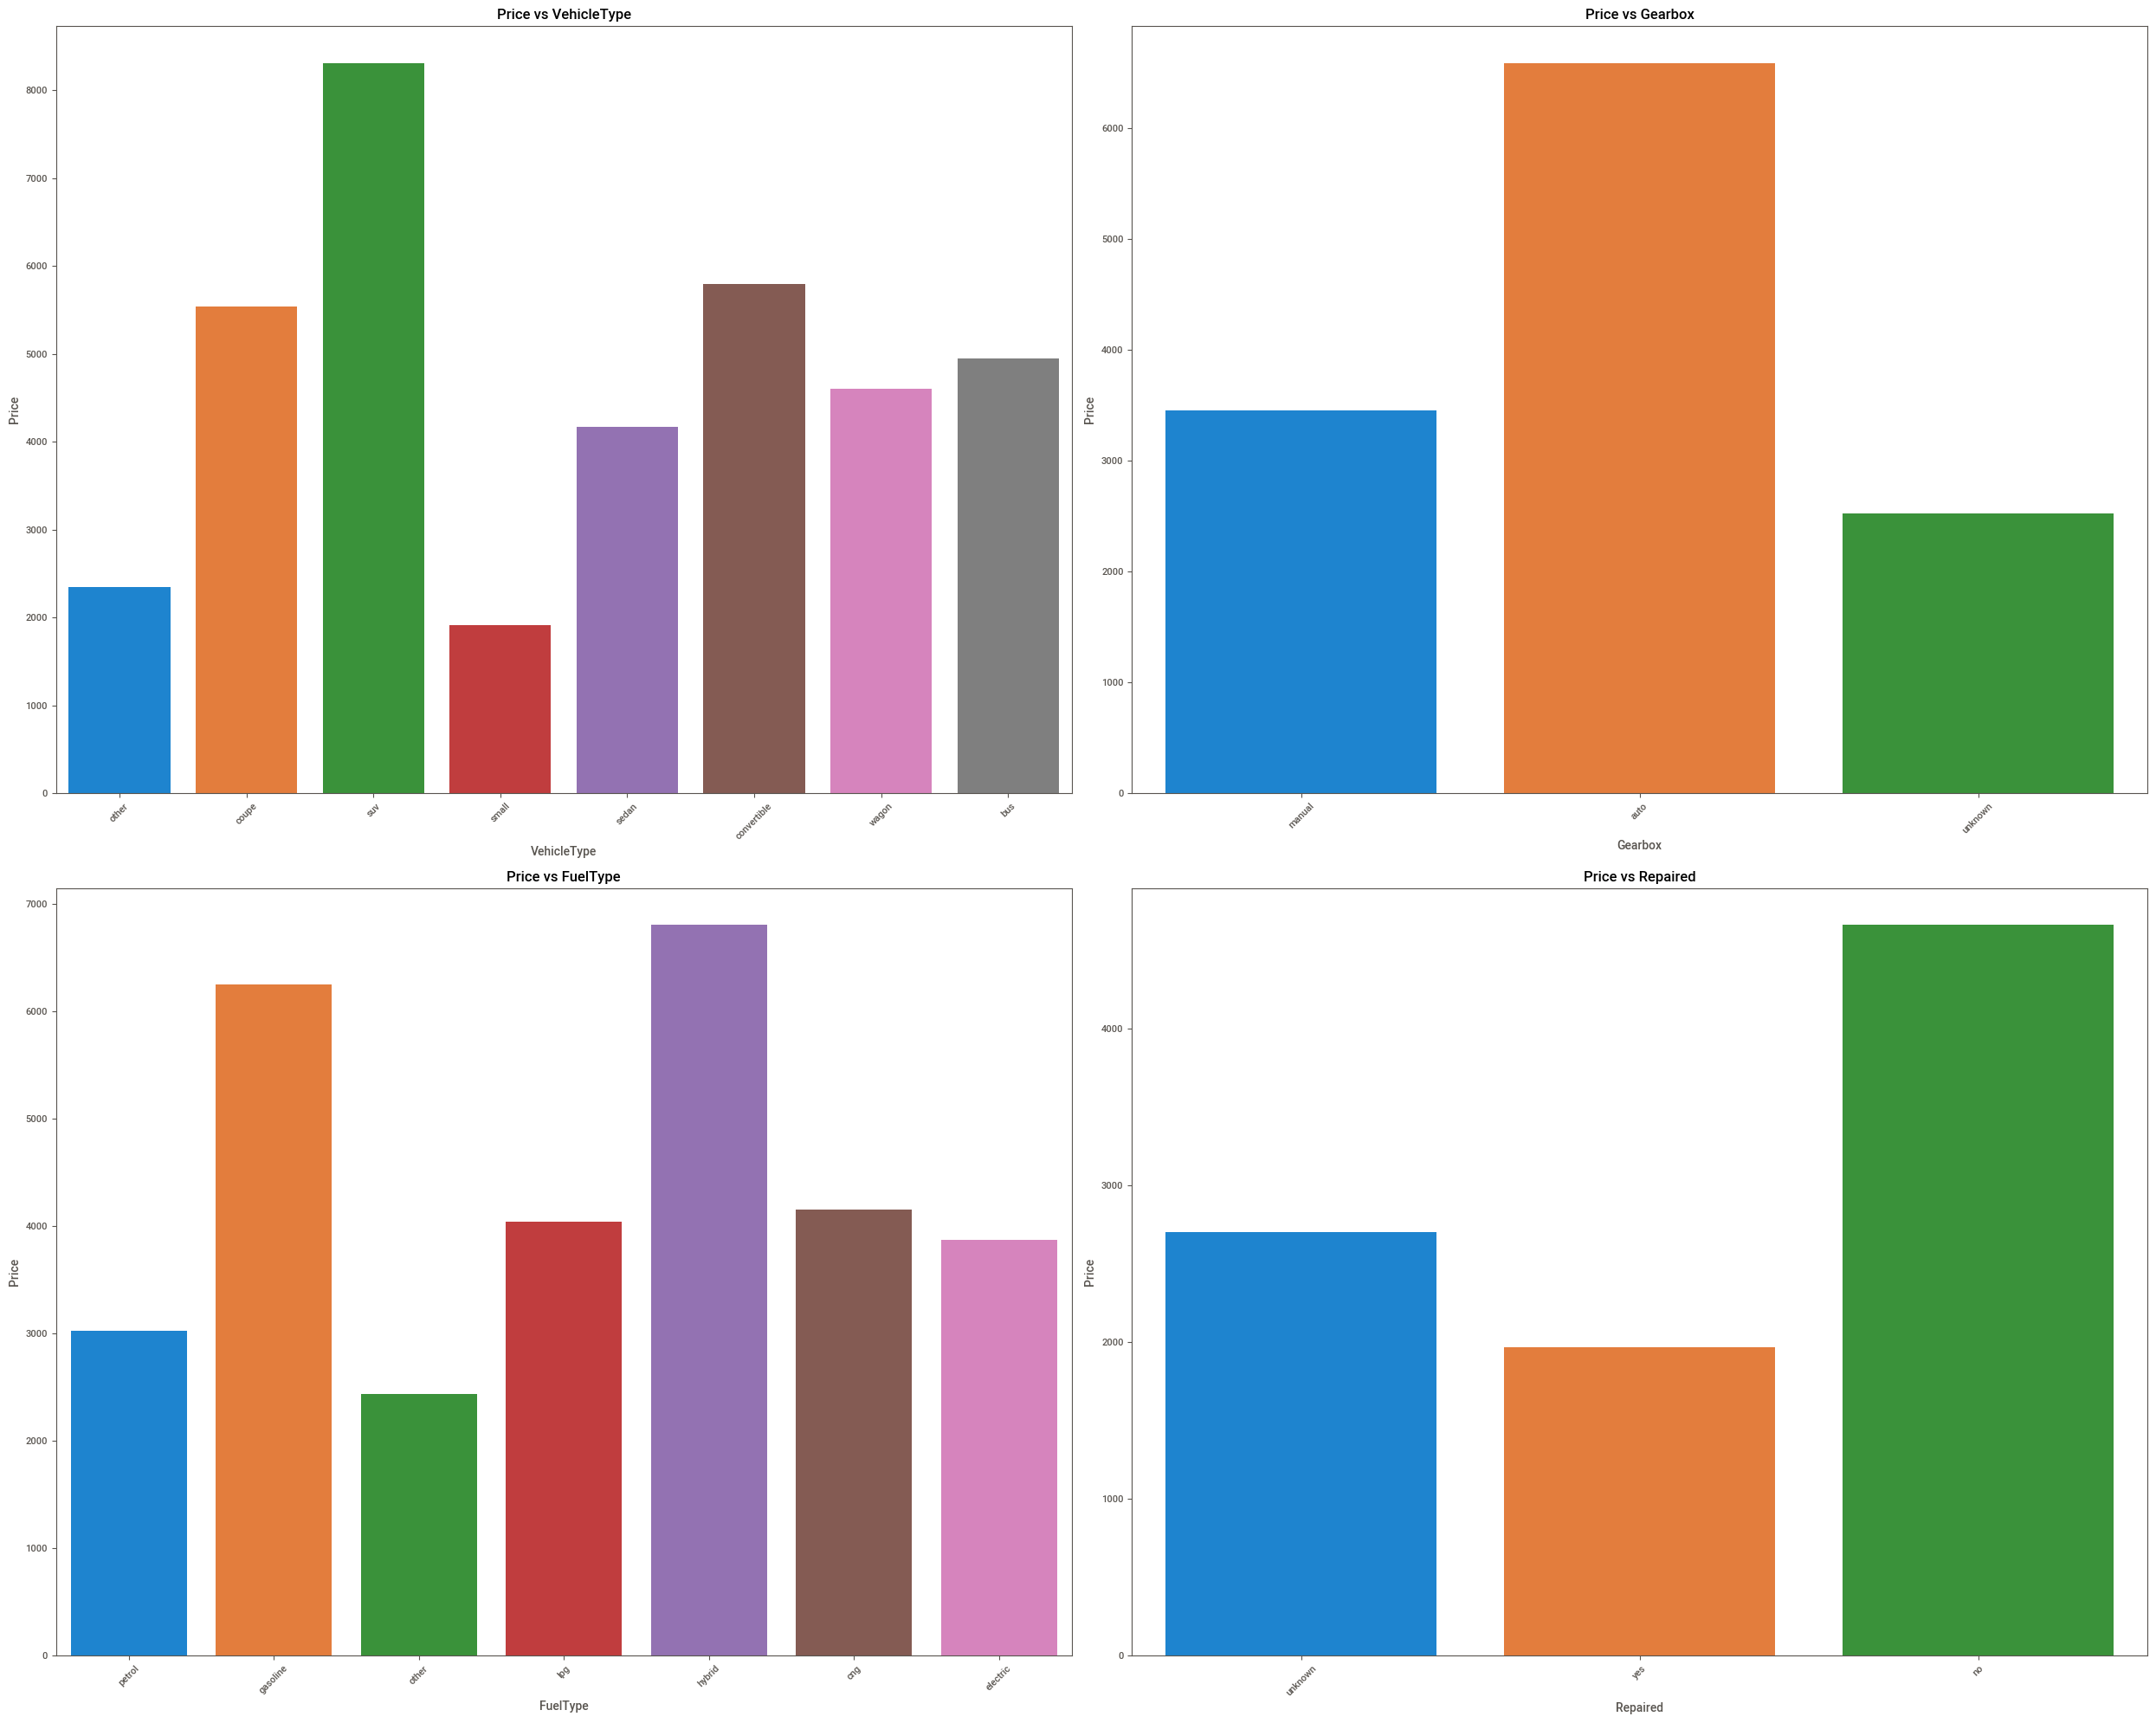

In [48]:
# Сгруппируем категориальные и числовые данные
columns_of_interest_numeric = ['RegistrationYear', 'Power', 'Kilometer']
columns_of_interest_categorical = ['VehicleType', 'Gearbox', 'FuelType', 'Repaired']

# Создадим сетку графиков для числовых признаков
fig, axes_numeric = plt.subplots(1, 3, figsize=(15, 5))

# Разместим каждый линейный график на своем подграфике
for i, col in enumerate(columns_of_interest_numeric):
    sns.lineplot(x=data[col], y=data['Price'], ax=axes_numeric[i])
    axes_numeric[i].set_title(f'Price vs {col}')

# Отрегулируем расположение графиков
plt.tight_layout()

# Повернем названия на оси X для лучшей читаемости
for ax in axes_numeric:
    ax.tick_params(axis='x', rotation=45)

# Создадим сетку графика для категориальных признаков
fig_categorical, axes_categorical = plt.subplots(2, 2, figsize=(25, 20))

# Разместим каждый bar-график на своем подграфике
for i, col in enumerate(['VehicleType', 'Gearbox', 'FuelType', 'Repaired']):
    sns.barplot(x=data[col], y=data['Price'], ax=axes_categorical[i // 2, i % 2], ci=None)
    axes_categorical[i // 2, i % 2].set_title(f'Price vs {col}')
    axes_categorical[i // 2, i % 2].tick_params(axis='x', rotation=45)

# Отрегулируем расположение графиков
plt.tight_layout()

# Отобразим графики
plt.show()

* Цены стремительно растут на автомобили, зарегистрированне с 1995г, резкий спад цен на автомобили, зарегистрированных после 2010-2012 гг

* Чем больше мощность автомобиля, тем выше цена (пропускаем интервал значений от 0 до 50 - это ошибки или заглушки для отсутствующих данных)

* Чем меньше пробег у автомобилей, тем они дороже

* Дороже всего автомобили с типом кузова:  'suv', дешевле всего - 'small'

* Дороже всего автомобили с автоматической коробкой передач

* Дороже всего автомобили с типом топлива:  'hybrid', 'gasoline', дешевле с 'petrol' и 'other'

* Дороже стоят автомобили, не подвергавшиеся ремонту

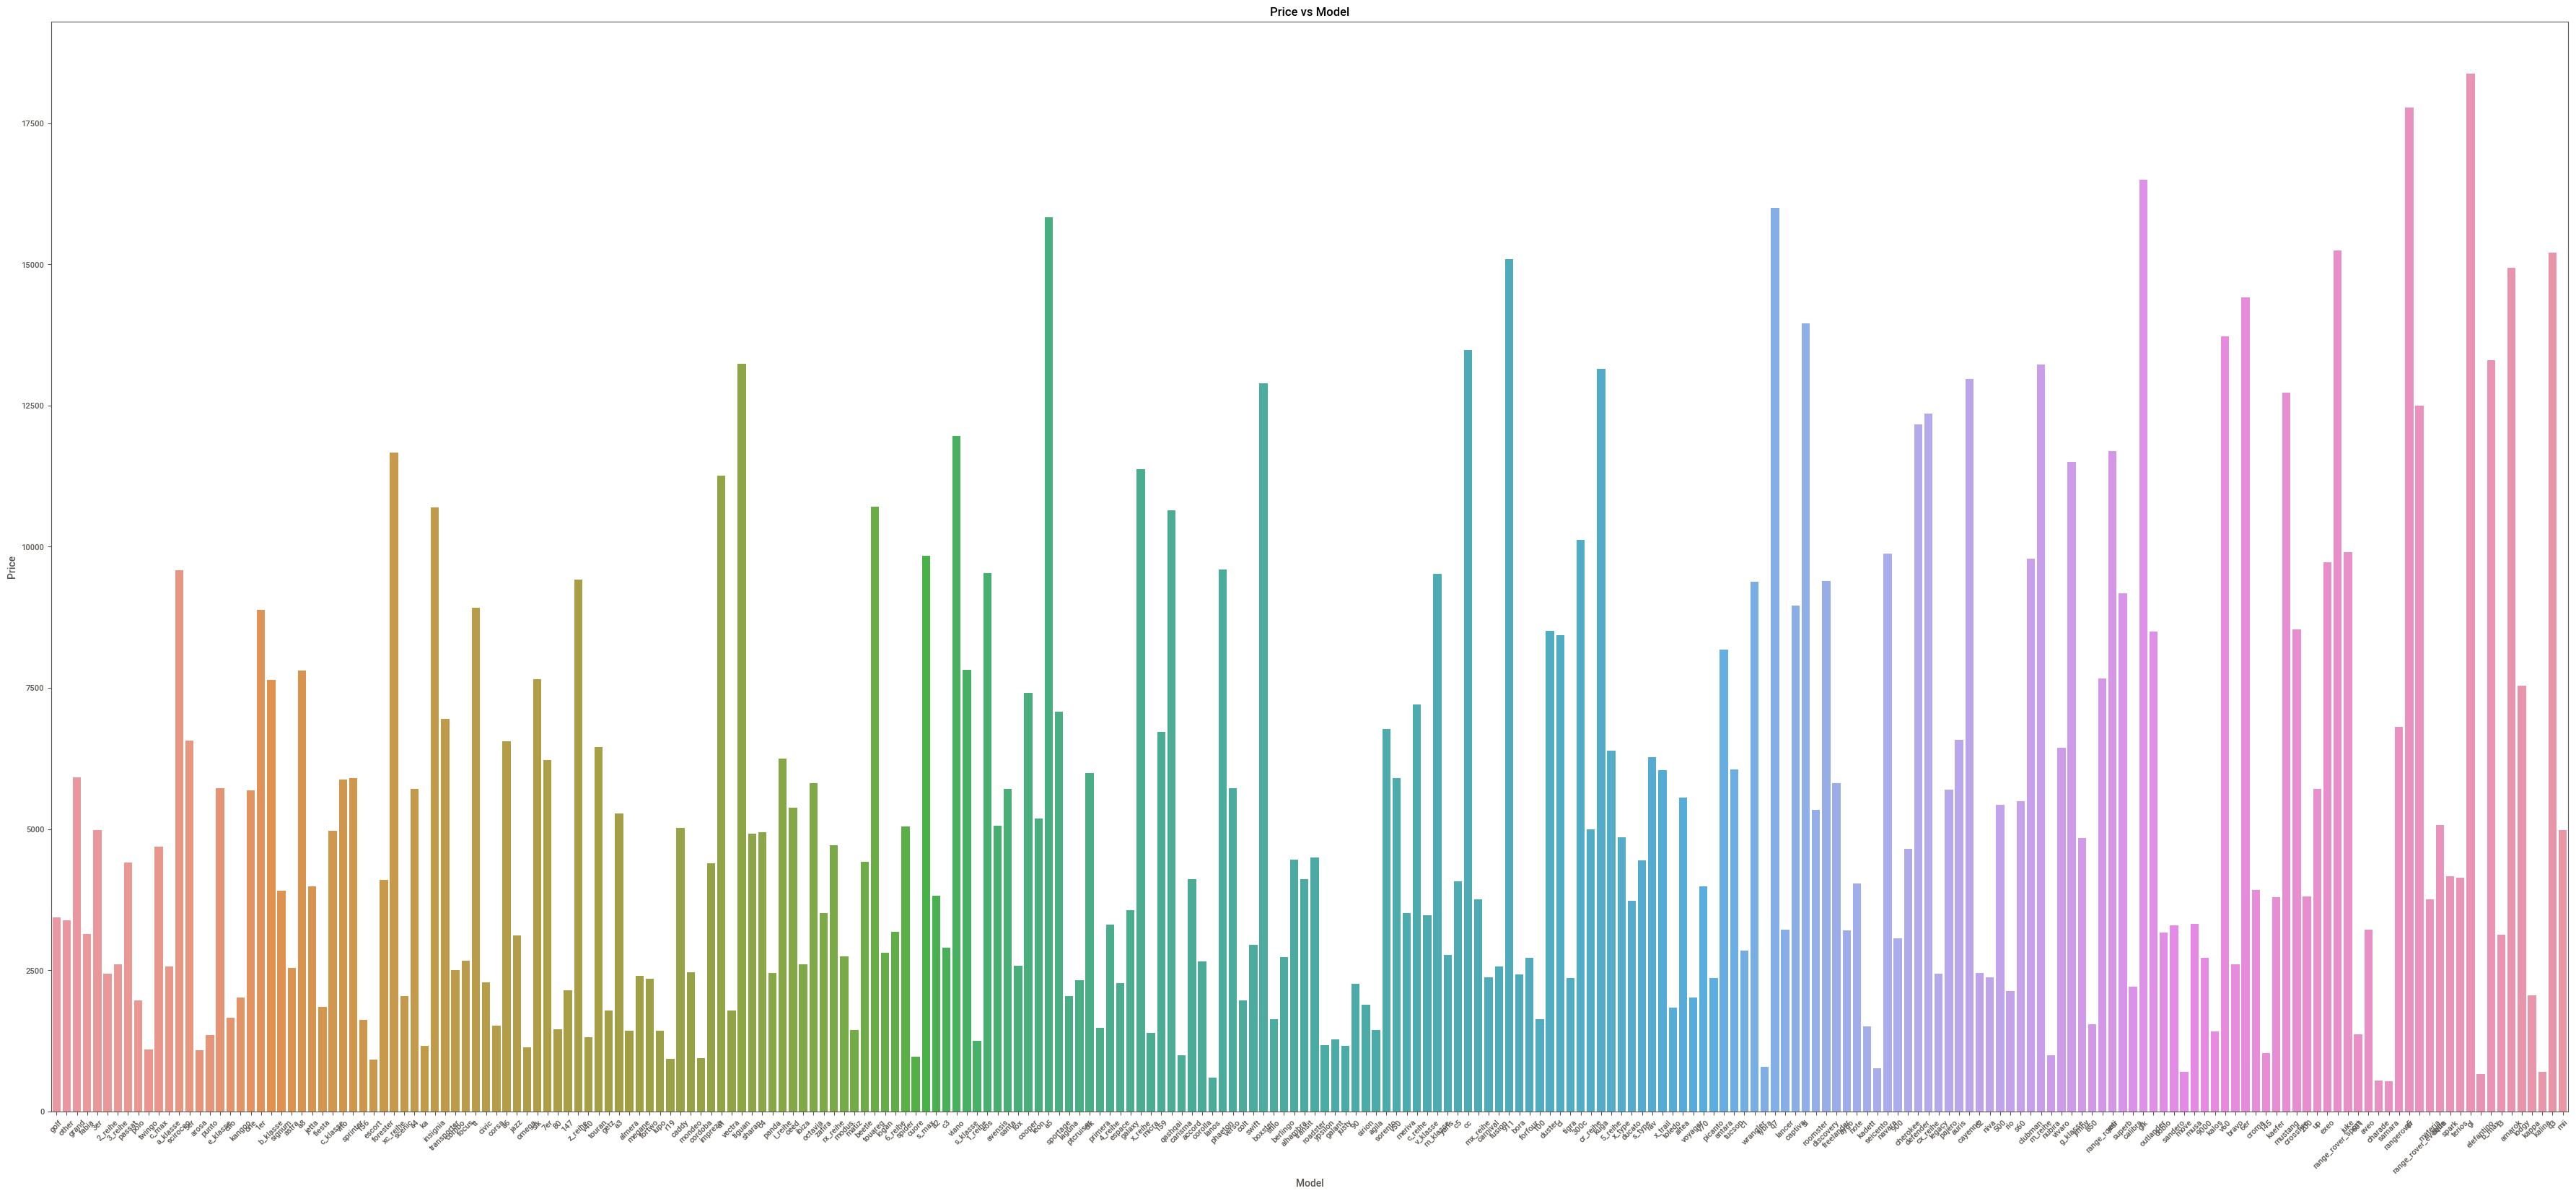

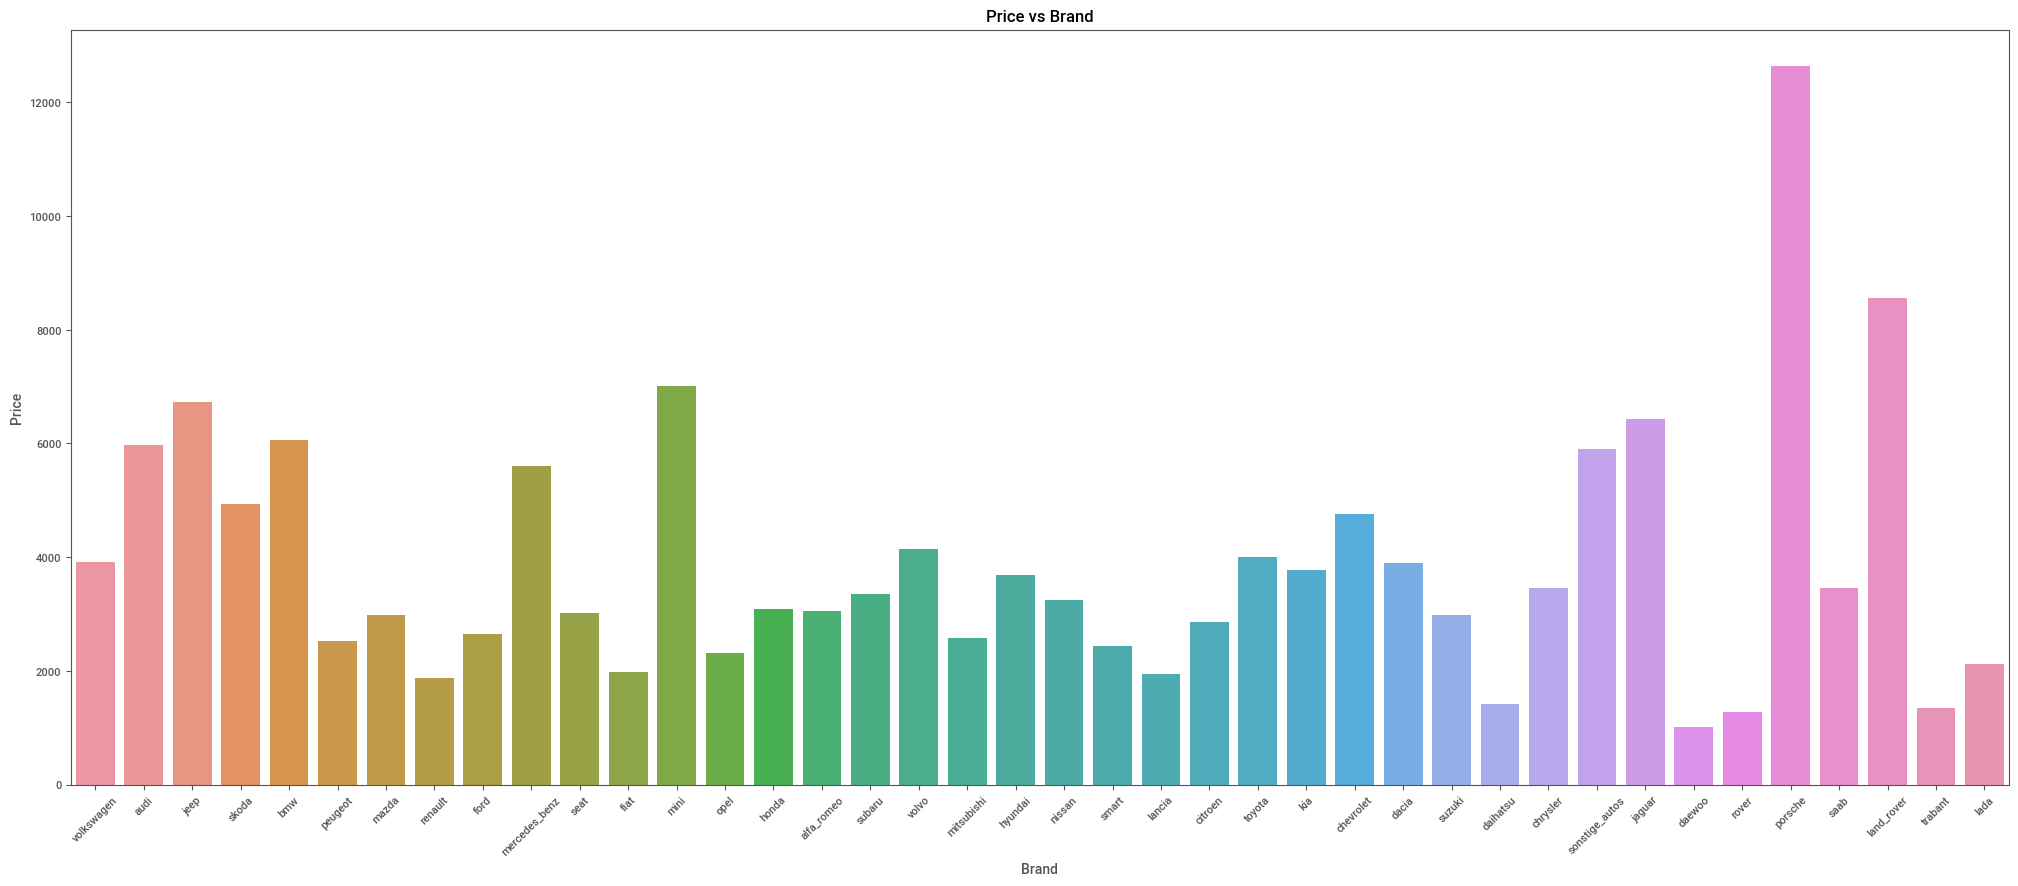

In [49]:
# Построим отдельные графики для 'Model', 'Brand'
columns_of_interest_categorical = ['Model', 'Brand']

fig_model, ax_model = plt.subplots(figsize=(45, 20))
sns.barplot(x=data['Model'], y=data['Price'], ax=ax_model, ci=None)
ax_model.set_title('Price vs Model')
ax_model.tick_params(axis='x', rotation=45)
    
fig_brand, ax_brand = plt.subplots(figsize=(25, 10))
sns.barplot(x=data['Brand'], y=data['Price'], ax=ax_brand, ci=None)
ax_brand.set_title('Price vs Brand')
ax_brand.tick_params(axis='x', rotation=45)

plt.show()

In [50]:
# Сгруппируем данные по цене и модели авто
grouped_data = data.groupby('Model')['Price'].mean().reset_index()
sorted_data = grouped_data.sort_values(by='Price', ascending=False)
sorted_data

,Model,Price
113,gl,18378.833333
177,q5,17776.633333
114,glk,16503.310345
178,q7,16003.890244
30,a5,15832.098876
...,...,...
130,kalina,700.000000
95,elefantino,669.833333
137,lanos,594.833333
70,charade,549.277778


* Самый дорогой бренд автомобилей: porshe, самый дешевый: daewoo

* Самая дорогая модель: gl, самая дешевая -  samara

Проверим все значения на мультиколлинеарность  

Будем использовать phik, так как он позволяет обнаружить корреляцию не только между количественными, но и между качественными признаками.  

interval columns not set, guessing: ['Price', 'RegistrationYear', 'Power', 'Kilometer']


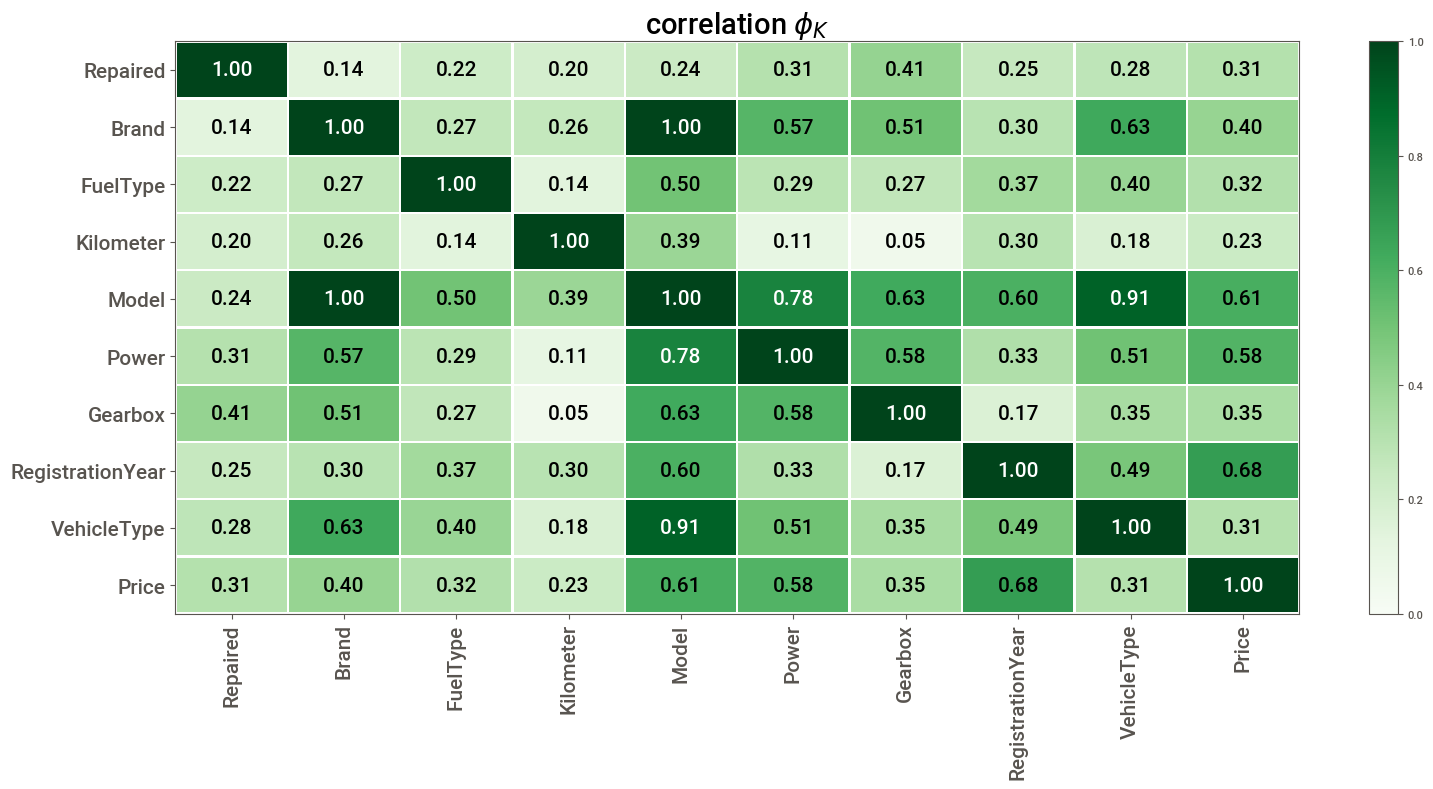

In [51]:
phik_overview = data.phik_matrix()

plot_correlation_matrix(phik_overview.values,
                        x_labels=phik_overview.columns,
                        y_labels=phik_overview.index,
                        vmin=0, vmax=1, color_map="Greens",
                        title=r"correlation $\phi_K$",
                        fontsize_factor=1.5,
                        figsize=(16, 8))
plt.tight_layout();

Обнаружена корреляция между признаками:

* Brand и Model
* Brand и VehicleType, Power
* Model и Power, Gearbox, RegistrationYear, VehicleType, Price
* RegistrationYear и VehicleType, Price

Построим дополнительные графики, чтобы посмотреть корреляцию между целевым и прочими признаками

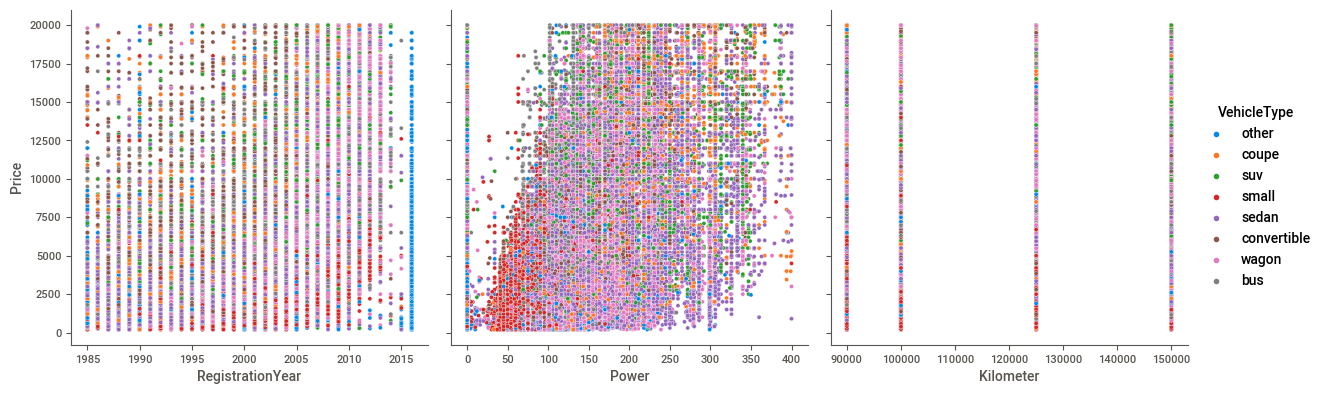

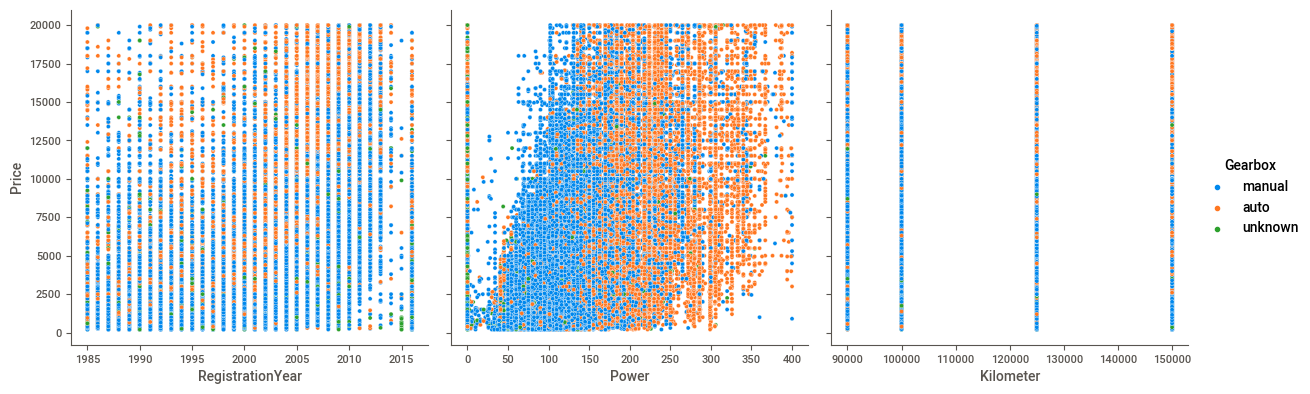

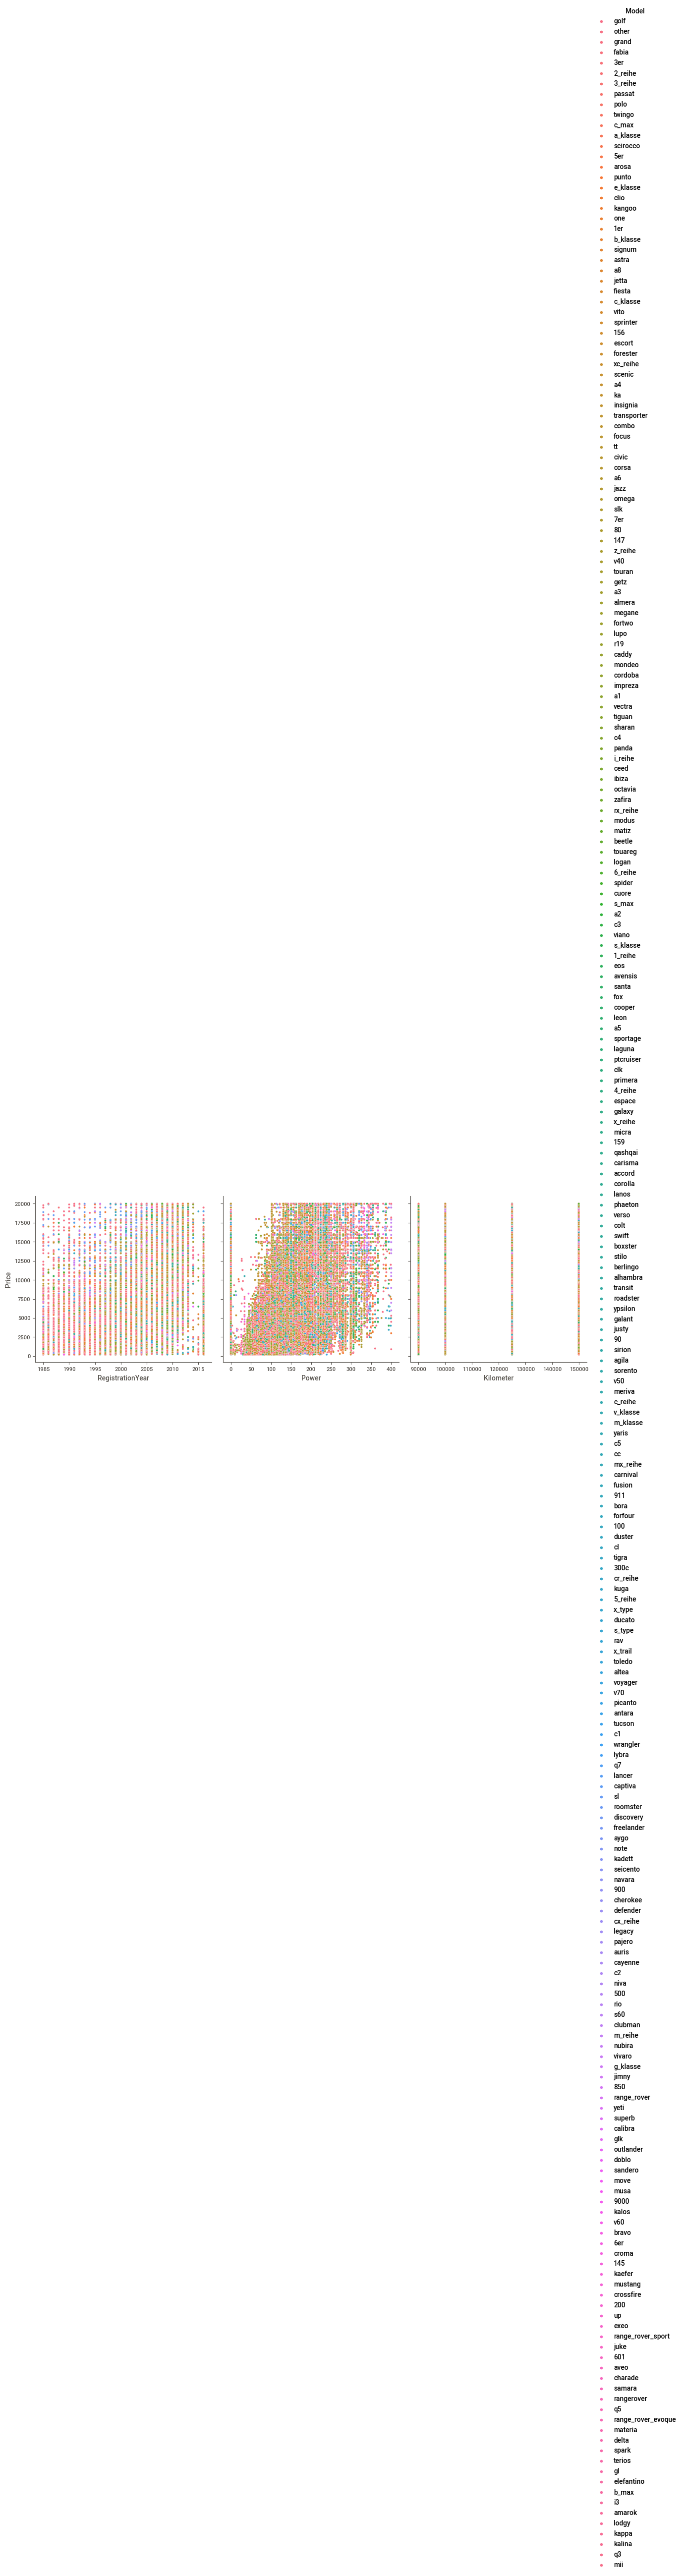

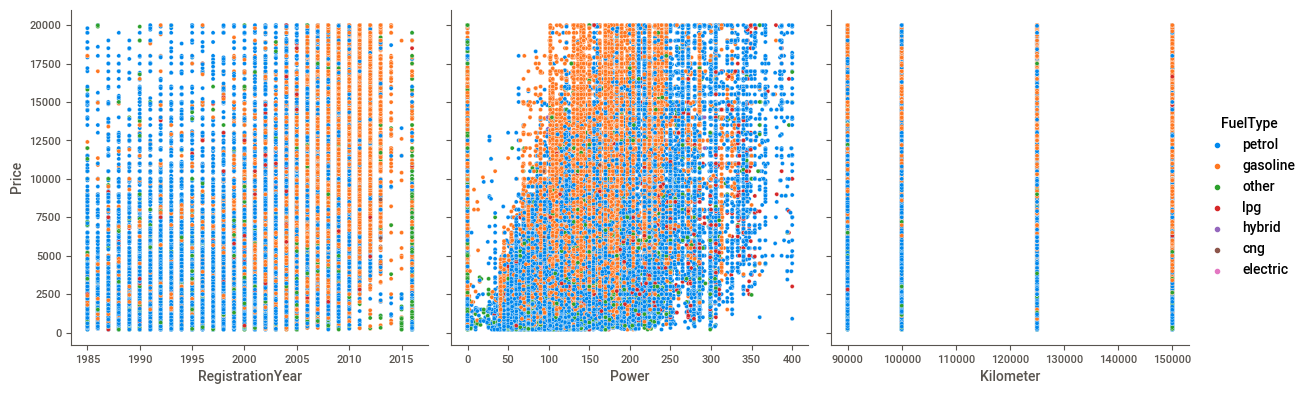

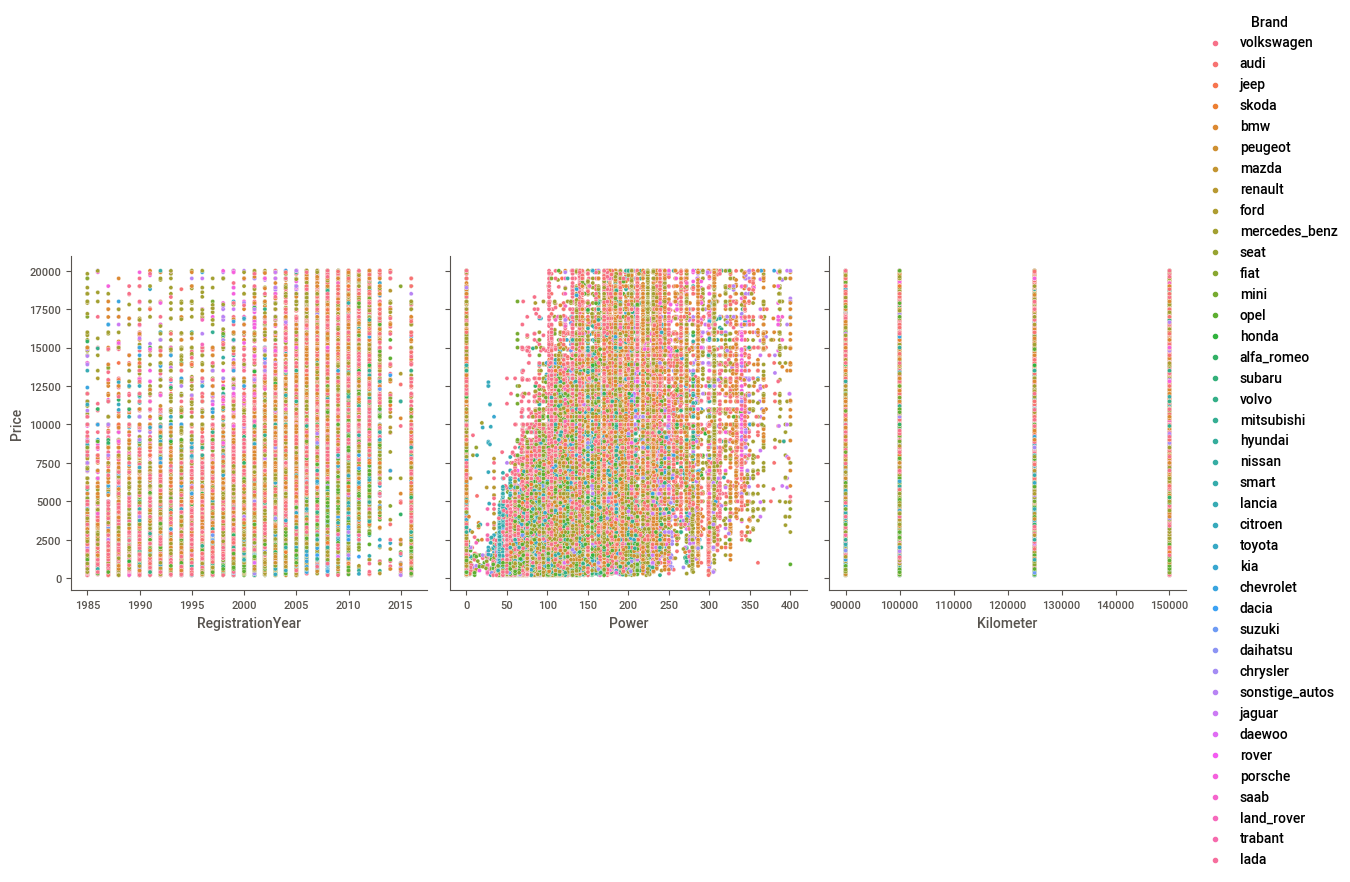

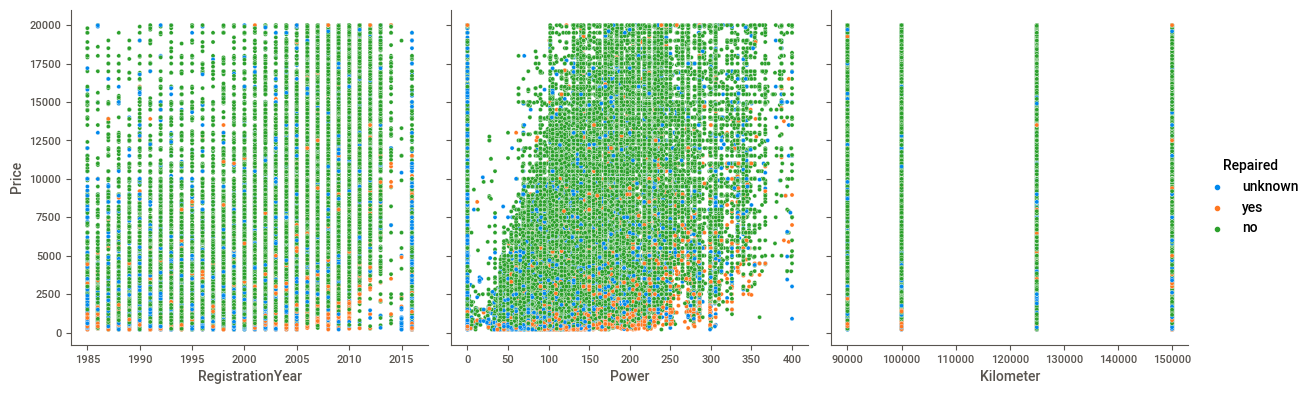

In [52]:
cat = ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Brand', 'Repaired']
factor = ['RegistrationYear', 'Power', 'Kilometer']
targ = 'Price'

for category in cat:
    g = sns.PairGrid(data, hue=category, x_vars=factor, y_vars=targ, height=4)
    g.map(sns.scatterplot)
    g.add_legend()

Удалим столбец Model, так как он коррелирует с несколькими признаками, преодолевает пороговое значение 0.7

In [53]:
data = data.drop(['Model'], axis=1)

Еще раз проверим количество явных дубликатов

In [54]:
data.duplicated().sum()

43459

43459 - это 16% данных, довольно много. Но все же удалим их, так как повторяющиеся значения не играют роли для обучения моделей. Также нам важно замерить время обучения и предсказания, освободив датасет от всего лишнего, мы сможем оптимизировать эти показатели.

In [55]:
data = data.drop_duplicates()

In [56]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 227769 entries, 0 to 354368
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Price             227769 non-null  int64 
 1   VehicleType       227769 non-null  object
 2   RegistrationYear  227769 non-null  int64 
 3   Gearbox           227769 non-null  object
 4   Power             227769 non-null  int64 
 5   Kilometer         227769 non-null  int64 
 6   FuelType          227769 non-null  object
 7   Brand             227769 non-null  object
 8   Repaired          227769 non-null  object
dtypes: int64(4), object(5)
memory usage: 17.4+ MB


Таким образом от первоначальных 354369 строк, у нас осталось 227769. В результате предобработки и исследовательского анализа данных сократили датасет на 36%. Это существенно, но в данных было достаточно много аномалий и дублей.

### Отбор обучающих признаков

Зафиксируем целевой признак (target) и признаки (features), которые будут задействованы в обучении моделей

In [57]:
data.columns

Index(['Price', 'VehicleType', 'RegistrationYear', 'Gearbox', 'Power',
       'Kilometer', 'FuelType', 'Brand', 'Repaired'],
      dtype='object')

In [58]:
features = ['VehicleType', 'RegistrationYear', 'Gearbox', 'Power',
       'Kilometer', 'FuelType', 'Brand', 'Repaired']

In [59]:
target = ['Price']

Таким образом, после предобработки у нас осталась примерно 9 признаков из первоначальных 16.

### Вывод

**На этапе предобработки и исследовательского анализа данных:** 

* Заменили тип данных в столбцах с датами с object на datetime 

  
* Проверим количество пропущенных значений для каждого столбца.   
    - В столбцах Gearbox, Repaired вместо пропусков поставим заглушку 'unknown'. 
    - В FuelType, VehicleType, Model для воспользовались существующей категорией 'other'.
  
  
* Удалили признаки, не влияющие на обучение моделей: 
'DateCrawled', 'DateCreated', 'NumberOfPictures', 'PostalCode', 'LastSeen', 'RegistrationMonth'.
  
  
* Обработали аномалии и выбросы в числовых значениях: 
Price, RegistrationYear, Power, Kilometer
  
  
* Изучили взаимосвязь между целевым и прочими признаками: 
    - Цены стремительно растут на автомобили, зарегистрированне с 1995г, резкий спад цен на автомобили, зарегистрированных после 2016 г (т.к. анкеты, выгруженные из базы относятся к 2016 г)
    - Чем больше мощность автомобиля, тем выше цена (пропускаем интервал значений от 0 до 50 - это ошибки или заглушки для отсутствующих данных)
    - Чем меньше пробег у автомобилей, тем они дороже
    - Дороже всего автомобили с типом кузова: 'suv', дешевле всего - 'small'
    - Дороже всего автомобили с автоматической коробкой передач
    - Дороже всего автомобили с типом топлива: 'hybrid', 'gasoline', дешевле с 'petrol' и 'other'
    - Дороже стоят автомобили, не подвергавшиеся ремонту
    - Самый дорогой бренд автомобилей: porshe, самый дешевый: daewoo
    - Самая дорогая модель: gl, самая дешевая - samara
  
  
* Проверили значения на мультиколлинеарность. Обнаружили корреляцию между признаками:
    - Brand и Model
    - Brand и VehicleType, Power
    - Model и Power, Gearbox, RegistrationYear, VehicleType, Price
    - RegistrationYear и VehicleType, Price
  
  
Удалили Model, так как он коррелирует с несколькими признаками, преодолевает пороговое значение 0.7


* Проверили датасет и удалили явные дубликаты


* Отобрали признаки для обучения моделей:
    - features = 'VehicleType', 'RegistrationYear', 'Gearbox', 'Power', 'Kilometer', 'FuelType', 'Brand', 'Repaired'
Целевой признак
    - target = 'Price'

## Обучение моделей

### Разбиение обучающей выборки

Разделим данные на целевое значение ('Price') и прочие

In [60]:
X = data.drop(['Price'], axis=1)
y = data['Price']

Сгруппируем категориальные и числовые значения

In [61]:
categorical_cols = X.select_dtypes(include='object').columns
categorical_cols

Index(['VehicleType', 'Gearbox', 'FuelType', 'Brand', 'Repaired'], dtype='object')

In [62]:
numerical_cols = X.select_dtypes(exclude='object').columns
numerical_cols

Index(['RegistrationYear', 'Power', 'Kilometer'], dtype='object')

Разделим исходные данные на обучающую и тестовую выборки

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(182215, 8) (45554, 8) (182215,) (45554,)


### Выбор моделей для обучения и предсказания на тестовой выборке

Цель нашего исследования построить модель для определения стоимости автомобиля. Значит нам предстоит решить задачу **регрессии**.

Для достижения цели мы будем тестировать четыре модели:

* LinearRegression
* Random Forest Regressor
* LGBM Regressor
* CatBoost Regressor

Для оценки качества моделей будем применять метрику RMSE. Значение RMSE должно быть меньше 2500.

Для анализа и выбора лучшей модели будем опираться на критерии:

* качество предсказания
* скорость предсказания
* время обучения

### LinearRegression

Для разработки модели будем использовать Pipeline и GridSearchCV

In [64]:
# категориальные признаки обработаем OneHotEncoder
cat_pipeline = make_pipeline(
    OneHotEncoder(drop='first')
)

# числовые признаки обработаем StandardScaler
num_pipeline = make_pipeline(
    StandardScaler()
)

# Строим ColumnTransformer
col_transf = ColumnTransformer(transformers=[
    ('num_pipeline', num_pipeline, numerical_cols),
    ('cat_pipeline', cat_pipeline, categorical_cols)
    ],
    n_jobs=-1)

# Строим Pipeline для модели LinearRegression
pipeline_lr = Pipeline(
    steps=[
    ('col_transf', col_transf),
    ('model_lr', LinearRegression())
]
    )

In [65]:
# Параметры LinearRegression для поиска по сетке
param_lr = {
    'model_lr__fit_intercept': [True, False],
    'model_lr__positive': [True, False],
}

# Поиск по сетке. В качестве оценки используем 'neg_root_mean_squared_error' (RMSE со знаком "-")
grid_lr = GridSearchCV(pipeline_lr, param_grid=param_lr, cv=5, 
                       scoring='neg_root_mean_squared_error')

# Обучаем модель
grid_lr.fit(X_train, y_train)

# Получаем cv_results_
cv_results = pd.DataFrame(grid_lr.cv_results_)

# Выводим информацию о кросс-валидации
print("Результаты кросс-валидации:")
print(cv_results[['param_model_lr__fit_intercept', 
                  'param_model_lr__positive', 
                  'mean_test_score', 
                  'std_test_score', 
                  'mean_fit_time', 
                  'std_fit_time', 
                  'mean_score_time', 
                  'std_score_time']])

# Получаем лучшие параметры и оценку
best_params_lr = grid_lr.best_params_
score_lr = -grid_lr.best_score_

print(f'\nЛучшие параметры LinearRegression: {best_params_lr}')
print(f'Лучшая оценка RMSE: {score_lr}')

# Обучаем модель с лучшими гиперпараметрами
best_lr_model = grid_lr.best_estimator_

# Оцениваем скорость обучения и предсказания с использованием кросс-валидации 
# Оценка проводится на уровне кросс-валидации, внутри GridSearchCV для каждого фолда
training_time_lr = cv_results['mean_fit_time'].mean()
prediction_time_lr = cv_results['mean_score_time'].mean()

print(f'Среднее время обучения: {training_time_lr} секунд')
print(f'Скорость предсказания: {prediction_time_lr} секунд')

Результаты кросс-валидации:
  param_model_lr__fit_intercept param_model_lr__positive  mean_test_score  \
0                          True                     True              NaN   
1                          True                    False     -2465.956408   
2                         False                     True              NaN   
3                         False                    False     -2470.196417   

   std_test_score  mean_fit_time  std_fit_time  mean_score_time  \
0             NaN       0.805480      0.263570         0.000000   
1        7.144723       1.261444      0.059472         0.130882   
2             NaN       0.615841      0.033323         0.000000   
3        6.909493       1.206953      0.019204         0.121133   

   std_score_time  
0        0.000000  
1        0.010427  
2        0.000000  
3        0.000975  

Лучшие параметры LinearRegression: {'model_lr__fit_intercept': True, 'model_lr__positive': False}
Лучшая оценка RMSE: 2465.95640800449
Среднее время 

### Модель RandomForestRegressor

In [66]:
# категориальные признаки обработаем OrdinalEncoder
cat_pipeline = make_pipeline(
    OrdinalEncoder()
)

# числовые данные обработаем StandardScaler
num_pipeline = make_pipeline(
    StandardScaler()
)

col_transf = ColumnTransformer(transformers=[
    ('num_pipeline', num_pipeline, numerical_cols),
    ('cat_pipeline', cat_pipeline, categorical_cols)
], n_jobs=-1)

pipeline_fr = Pipeline(
    steps=[
        ('col_transf', col_transf),
        ('model_fr', RandomForestRegressor())
    ]
)

In [67]:
param_fr = {'model_fr__n_estimators': [10, 50],
            'model_fr__max_depth': [None, 3, 5],
            'model_fr__min_samples_leaf': [1, 2, 4],
            'model_fr__random_state': [42]}

grid_fr = GridSearchCV(pipeline_fr, param_grid=param_fr, cv=5, 
                       scoring='neg_root_mean_squared_error')

grid_fr.fit(X_train, y_train)

cv_results = pd.DataFrame(grid_fr.cv_results_)

print("Результаты кросс-валидации:")
print(cv_results[['param_model_fr__n_estimators', 
                  'param_model_fr__max_depth', 
                  'param_model_fr__min_samples_leaf',
                  'param_model_fr__random_state',
                  'std_test_score', 
                  'mean_fit_time', 
                  'std_fit_time', 
                  'mean_score_time', 
                  'std_score_time']])

best_params_fr = grid_fr.best_params_
score_fr = -grid_fr.best_score_

print(f'\nЛучшие параметры RandomForestRegressor: {best_params_fr}')
print(f'Лучшая оценка RMSE: {score_fr}')

best_fr_model = grid_fr.best_estimator_

training_time_fr = cv_results['mean_fit_time'].mean()
prediction_time_fr = cv_results['mean_score_time'].mean()

print(f'Среднее время обучения: {training_time_fr} секунд')
print(f'Скорость предсказания: {prediction_time_fr} секунд')

Результаты кросс-валидации:
   param_model_fr__n_estimators param_model_fr__max_depth  \
0                            10                      None   
1                            50                      None   
2                            10                      None   
3                            50                      None   
4                            10                      None   
5                            50                      None   
6                            10                         3   
7                            50                         3   
8                            10                         3   
9                            50                         3   
10                           10                         3   
11                           50                         3   
12                           10                         5   
13                           50                         5   
14                           10                         5

### Модель LGBMRegressor

In [68]:
cat_pipeline = make_pipeline(
    OrdinalEncoder()
)

num_pipeline = make_pipeline(
    StandardScaler()
)

col_transf = ColumnTransformer(transformers=[
    ('num_pipeline', num_pipeline, numerical_cols),
    ('cat_pipeline', cat_pipeline, categorical_cols)
], n_jobs=-1)

pipeline_lgbmr = Pipeline(
    steps=[
        ('col_transf', col_transf),
        ('model_lgbmr', LGBMRegressor())
    ]
)

In [69]:
param_lgbmr = {'model_lgbmr__learning_rate': [0.01, 0.1, 0.3],
               'model_lgbmr__num_leaves': [11, 50, 100],
               'model_lgbmr__max_depth': [None, 10, 20, 30],
               'model_lgbmr__random_state': [42]}

grid_lgbmr = GridSearchCV(pipeline_lgbmr, param_grid=param_lgbmr, cv=5, 
                       scoring='neg_root_mean_squared_error')

grid_lgbmr.fit(X_train, y_train)

cv_results = pd.DataFrame(grid_lgbmr.cv_results_)

print("Результаты кросс-валидации:")
print(cv_results[['param_model_lgbmr__learning_rate', 
                  'param_model_lgbmr__num_leaves', 
                  'param_model_lgbmr__max_depth',
                  'param_model_lgbmr__random_state',
                  'mean_test_score', 
                  'std_test_score', 
                  'mean_fit_time', 
                  'std_fit_time', 
                  'mean_score_time', 
                  'std_score_time']])

best_params_lgbmr = grid_lgbmr.best_params_
score_lgbmr = -grid_lgbmr.best_score_

print(f'\nЛучшие параметры LGBMRegressor: {best_params_lgbmr}')
print(f'Лучшая оценка RMSE: {score_lgbmr}')

best_lgbmr_model = grid_lgbmr.best_estimator_

training_time_lgbmr = cv_results['mean_fit_time'].mean()
prediction_time_lgbmr = cv_results['mean_score_time'].mean()

print(f'Среднее время обучения: {training_time_lgbmr} секунд')
print(f'Скорость предсказания: {prediction_time_lgbmr} секунд')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006244 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 329
[LightGBM] [Info] Number of data points in the train set: 145772, number of used features: 8
[LightGBM] [Info] Start training from score 4121.030527
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006666 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 331
[LightGBM] [Info] Number of data points in the train set: 145772, number of used features: 8
[LightGBM] [Info] Start training from score 4116.145913
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006454 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not e

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007190 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 331
[LightGBM] [Info] Number of data points in the train set: 145772, number of used features: 8
[LightGBM] [Info] Start training from score 4116.145913
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016460 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 331
[LightGBM] [Info] Number of data points in the train set: 145772, number of used features: 8
[LightGBM] [Info] Start training from score 4111.674300
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009588 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not e

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007328 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 331
[LightGBM] [Info] Number of data points in the train set: 145772, number of used features: 8
[LightGBM] [Info] Start training from score 4111.674300
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007669 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 330
[LightGBM] [Info] Number of data points in the train set: 145772, number of used features: 8
[LightGBM] [Info] Start training from score 4113.294028
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008687 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not e

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006841 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 330
[LightGBM] [Info] Number of data points in the train set: 145772, number of used features: 8
[LightGBM] [Info] Start training from score 4113.294028
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007521 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 333
[LightGBM] [Info] Number of data points in the train set: 145772, number of used features: 8
[LightGBM] [Info] Start training from score 4116.870736
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008331 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not e

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007837 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 333
[LightGBM] [Info] Number of data points in the train set: 145772, number of used features: 8
[LightGBM] [Info] Start training from score 4116.870736
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010463 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 329
[LightGBM] [Info] Number of data points in the train set: 145772, number of used features: 8
[LightGBM] [Info] Start training from score 4121.030527
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing co

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007639 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 330
[LightGBM] [Info] Number of data points in the train set: 145772, number of used features: 8
[LightGBM] [Info] Start training from score 4113.294028
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007030 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 333
[LightGBM] [Info] Number of data points in the train set: 145772, number of used features: 8
[LightGBM] [Info] Start training from score 4116.870736
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009149 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not e

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006523 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 333
[LightGBM] [Info] Number of data points in the train set: 145772, number of used features: 8
[LightGBM] [Info] Start training from score 4116.870736
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006516 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 329
[LightGBM] [Info] Number of data points in the train set: 145772, number of used features: 8
[LightGBM] [Info] Start training from score 4121.030527
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007138 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not e

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006994 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 333
[LightGBM] [Info] Number of data points in the train set: 145772, number of used features: 8
[LightGBM] [Info] Start training from score 4116.870736
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007769 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 329
[LightGBM] [Info] Number of data 

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006157 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 330
[LightGBM] [Info] Number of data points in the train set: 145772, number of used features: 8
[LightGBM] [Info] Start training from score 4113.294028
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006469 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 333
[LightGBM] [Info] Number of data points in the train set: 145772, number of used features: 8
[LightGBM] [Info] Start training from score 4116.870736
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007394 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not e

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008157 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 333
[LightGBM] [Info] Number of data points in the train set: 145772, number of used features: 8
[LightGBM] [Info] Start training from score 4116.870736
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008211 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 329
[LightGBM] [Info] Number of data points in the train set: 145772, number of used features: 8
[LightGBM] [Info] Start training from score 4121.030527
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015583 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not e

### Модель CatBoostRegressor

In [70]:
# Числовые признаки обрабатывать отдельно для модели CatBoostRegressor не нужно
# Будем использовать внутренний обработчик категориальных признаков CatBoostEncoder
cat_pipeline = make_pipeline(
    ce.CatBoostEncoder()
)

col_transf = ColumnTransformer(transformers=[
    ('num_pipeline', 'passthrough', numerical_cols), 
    ('cat_pipeline', cat_pipeline, categorical_cols)
])

pipeline_catboost = Pipeline(
    steps=[
        ('col_transf', col_transf),
        ('model_catboost', CatBoostRegressor()) 
    ]
)

In [71]:
param_catboost = {'model_catboost__learning_rate': [0.01, 0.1, 0.3],
                  'model_catboost__depth': [4, 6, 8, 10],
                  'model_catboost__iterations': [50, 100, 200],
                  'model_catboost__random_state': [42]}

grid_catboost = GridSearchCV(pipeline_catboost, param_grid=param_catboost, cv=5, 
                       scoring='neg_root_mean_squared_error')

grid_catboost.fit(X_train, y_train)

cv_results = pd.DataFrame(grid_catboost.cv_results_)

print("Результаты кросс-валидации:")
print(cv_results[['param_model_catboost__learning_rate', 
                  'param_model_catboost__depth', 
                  'param_model_catboost__iterations',
                  'param_model_catboost__random_state',
                  'mean_test_score', 
                  'std_test_score', 
                  'mean_fit_time', 
                  'std_fit_time', 
                  'mean_score_time', 
                  'std_score_time']])

best_params_catboost = grid_catboost.best_params_
score_catboost = -grid_catboost.best_score_

print(f'\nЛучшие параметры CatBoostRegressor: {best_params_catboost}')
print(f'Лучшая оценка RMSE: {score_catboost}')

best_catboost_model = grid_catboost.best_estimator_

training_time_catboost = cv_results['mean_fit_time'].mean()
prediction_time_catboost = cv_results['mean_score_time'].mean()

print(f'Среднее время обучения: {training_time_catboost} секунд')
print(f'Скорость предсказания: {prediction_time_catboost} секунд')

0:	learn: 4051.9985220	total: 79.8ms	remaining: 3.91s
1:	learn: 4028.3756618	total: 93.4ms	remaining: 2.24s
2:	learn: 4004.2015667	total: 119ms	remaining: 1.86s
3:	learn: 3980.8614485	total: 134ms	remaining: 1.54s
4:	learn: 3956.9227584	total: 168ms	remaining: 1.51s
5:	learn: 3934.4454495	total: 183ms	remaining: 1.34s
6:	learn: 3911.9486161	total: 196ms	remaining: 1.21s
7:	learn: 3889.9254685	total: 219ms	remaining: 1.15s
8:	learn: 3867.3592222	total: 229ms	remaining: 1.04s
9:	learn: 3845.8615034	total: 244ms	remaining: 974ms
10:	learn: 3824.3249244	total: 263ms	remaining: 931ms
11:	learn: 3802.8170642	total: 273ms	remaining: 866ms
12:	learn: 3781.9810620	total: 287ms	remaining: 817ms
13:	learn: 3761.0773220	total: 300ms	remaining: 770ms
14:	learn: 3740.8194783	total: 322ms	remaining: 750ms
15:	learn: 3720.4905249	total: 331ms	remaining: 704ms
16:	learn: 3700.8850160	total: 350ms	remaining: 679ms
17:	learn: 3680.4300133	total: 378ms	remaining: 671ms
18:	learn: 3661.4322893	total: 393ms

13:	learn: 3754.6292814	total: 210ms	remaining: 540ms
14:	learn: 3734.2786520	total: 225ms	remaining: 524ms
15:	learn: 3713.4756002	total: 243ms	remaining: 517ms
16:	learn: 3693.6319340	total: 253ms	remaining: 492ms
17:	learn: 3673.2839932	total: 264ms	remaining: 469ms
18:	learn: 3654.0547948	total: 282ms	remaining: 460ms
19:	learn: 3634.6506843	total: 295ms	remaining: 443ms
20:	learn: 3615.5364922	total: 313ms	remaining: 432ms
21:	learn: 3596.7613088	total: 326ms	remaining: 414ms
22:	learn: 3578.1075025	total: 345ms	remaining: 405ms
23:	learn: 3559.8923851	total: 355ms	remaining: 385ms
24:	learn: 3541.5920267	total: 366ms	remaining: 366ms
25:	learn: 3523.8254021	total: 382ms	remaining: 353ms
26:	learn: 3505.8913050	total: 403ms	remaining: 343ms
27:	learn: 3488.1347160	total: 415ms	remaining: 326ms
28:	learn: 3470.6447749	total: 430ms	remaining: 312ms
29:	learn: 3453.3853858	total: 445ms	remaining: 297ms
30:	learn: 3436.5621377	total: 461ms	remaining: 282ms
31:	learn: 3419.8166903	tota

16:	learn: 2208.7707972	total: 218ms	remaining: 424ms
17:	learn: 2171.1024511	total: 229ms	remaining: 407ms
18:	learn: 2136.8847459	total: 242ms	remaining: 395ms
19:	learn: 2108.7366796	total: 256ms	remaining: 384ms
20:	learn: 2080.6332123	total: 269ms	remaining: 372ms
21:	learn: 2051.6805262	total: 284ms	remaining: 361ms
22:	learn: 2030.3799257	total: 297ms	remaining: 349ms
23:	learn: 2009.2075273	total: 311ms	remaining: 337ms
24:	learn: 1991.2498857	total: 325ms	remaining: 325ms
25:	learn: 1975.5162981	total: 355ms	remaining: 327ms
26:	learn: 1960.4404750	total: 369ms	remaining: 314ms
27:	learn: 1947.0460834	total: 384ms	remaining: 302ms
28:	learn: 1935.0422656	total: 412ms	remaining: 298ms
29:	learn: 1924.3074489	total: 424ms	remaining: 283ms
30:	learn: 1912.8484310	total: 439ms	remaining: 269ms
31:	learn: 1904.0959884	total: 462ms	remaining: 260ms
32:	learn: 1894.8727384	total: 472ms	remaining: 243ms
33:	learn: 1887.8970937	total: 484ms	remaining: 228ms
34:	learn: 1880.4986269	tota

19:	learn: 2098.2021902	total: 447ms	remaining: 670ms
20:	learn: 2070.6244768	total: 457ms	remaining: 631ms
21:	learn: 2047.5400448	total: 468ms	remaining: 595ms
22:	learn: 2026.0387923	total: 495ms	remaining: 581ms
23:	learn: 2006.7412251	total: 507ms	remaining: 550ms
24:	learn: 1987.6120949	total: 532ms	remaining: 532ms
25:	learn: 1971.8794143	total: 548ms	remaining: 506ms
26:	learn: 1957.3710536	total: 558ms	remaining: 475ms
27:	learn: 1942.2135360	total: 575ms	remaining: 452ms
28:	learn: 1929.1163726	total: 589ms	remaining: 426ms
29:	learn: 1917.7473073	total: 600ms	remaining: 400ms
30:	learn: 1908.1773504	total: 609ms	remaining: 373ms
31:	learn: 1898.5884248	total: 622ms	remaining: 350ms
32:	learn: 1888.8321519	total: 634ms	remaining: 327ms
33:	learn: 1880.1869918	total: 646ms	remaining: 304ms
34:	learn: 1873.9285747	total: 657ms	remaining: 281ms
35:	learn: 1866.5972849	total: 668ms	remaining: 260ms
36:	learn: 1860.5753607	total: 690ms	remaining: 242ms
37:	learn: 1854.1648870	tota

21:	learn: 1788.3544001	total: 414ms	remaining: 527ms
22:	learn: 1782.1689705	total: 440ms	remaining: 517ms
23:	learn: 1776.6264957	total: 451ms	remaining: 488ms
24:	learn: 1773.6915791	total: 461ms	remaining: 461ms
25:	learn: 1769.5270852	total: 486ms	remaining: 449ms
26:	learn: 1766.4300538	total: 496ms	remaining: 423ms
27:	learn: 1763.6349291	total: 506ms	remaining: 397ms
28:	learn: 1760.6474176	total: 518ms	remaining: 375ms
29:	learn: 1758.0589134	total: 538ms	remaining: 359ms
30:	learn: 1756.0312066	total: 548ms	remaining: 336ms
31:	learn: 1752.8480043	total: 557ms	remaining: 314ms
32:	learn: 1750.8306387	total: 586ms	remaining: 302ms
33:	learn: 1748.6166400	total: 596ms	remaining: 280ms
34:	learn: 1747.5676504	total: 605ms	remaining: 259ms
35:	learn: 1744.8606021	total: 627ms	remaining: 244ms
36:	learn: 1743.3289461	total: 638ms	remaining: 224ms
37:	learn: 1740.8352470	total: 648ms	remaining: 205ms
38:	learn: 1738.4672175	total: 659ms	remaining: 186ms
39:	learn: 1733.6869867	tota

30:	learn: 3442.0617993	total: 409ms	remaining: 911ms
31:	learn: 3425.3624945	total: 436ms	remaining: 927ms
32:	learn: 3408.6639874	total: 450ms	remaining: 914ms
33:	learn: 3391.2841455	total: 466ms	remaining: 904ms
34:	learn: 3374.6666863	total: 486ms	remaining: 903ms
35:	learn: 3358.8845823	total: 500ms	remaining: 890ms
36:	learn: 3342.7421102	total: 521ms	remaining: 887ms
37:	learn: 3326.9711833	total: 539ms	remaining: 880ms
38:	learn: 3310.7175910	total: 554ms	remaining: 867ms
39:	learn: 3295.0705082	total: 584ms	remaining: 875ms
40:	learn: 3279.5087456	total: 597ms	remaining: 860ms
41:	learn: 3264.7501556	total: 618ms	remaining: 853ms
42:	learn: 3249.8391970	total: 632ms	remaining: 838ms
43:	learn: 3234.5911158	total: 642ms	remaining: 818ms
44:	learn: 3220.2013299	total: 653ms	remaining: 798ms
45:	learn: 3205.7431209	total: 670ms	remaining: 786ms
46:	learn: 3191.4503795	total: 686ms	remaining: 773ms
47:	learn: 3177.9652699	total: 697ms	remaining: 755ms
48:	learn: 3164.0370386	tota

94:	learn: 2670.8537428	total: 1.83s	remaining: 96.1ms
95:	learn: 2662.4406720	total: 1.85s	remaining: 77.2ms
96:	learn: 2654.4323809	total: 1.88s	remaining: 58.1ms
97:	learn: 2646.4089261	total: 1.9s	remaining: 38.8ms
98:	learn: 2638.3129478	total: 1.92s	remaining: 19.4ms
99:	learn: 2630.0562726	total: 1.94s	remaining: 0us
0:	learn: 4045.6574681	total: 11.6ms	remaining: 1.15s
1:	learn: 4022.0474631	total: 35.7ms	remaining: 1.75s
2:	learn: 3998.0999569	total: 47ms	remaining: 1.52s
3:	learn: 3974.8209971	total: 57.5ms	remaining: 1.38s
4:	learn: 3951.7398230	total: 70.5ms	remaining: 1.34s
5:	learn: 3929.3274586	total: 85.4ms	remaining: 1.34s
6:	learn: 3906.6656162	total: 95.7ms	remaining: 1.27s
7:	learn: 3884.8118809	total: 106ms	remaining: 1.22s
8:	learn: 3862.0964086	total: 119ms	remaining: 1.21s
9:	learn: 3840.5286017	total: 134ms	remaining: 1.2s
10:	learn: 3819.3230385	total: 144ms	remaining: 1.16s
11:	learn: 3798.1009189	total: 154ms	remaining: 1.13s
12:	learn: 3777.3291716	total: 1

54:	learn: 3080.0665235	total: 1.03s	remaining: 846ms
55:	learn: 3067.4550147	total: 1.05s	remaining: 824ms
56:	learn: 3054.8923876	total: 1.07s	remaining: 811ms
57:	learn: 3042.5663696	total: 1.09s	remaining: 788ms
58:	learn: 3029.9105569	total: 1.12s	remaining: 780ms
59:	learn: 3017.4225129	total: 1.14s	remaining: 757ms
60:	learn: 3005.2874720	total: 1.16s	remaining: 743ms
61:	learn: 2993.5169817	total: 1.17s	remaining: 719ms
62:	learn: 2981.8319512	total: 1.18s	remaining: 696ms
63:	learn: 2970.4390824	total: 1.2s	remaining: 674ms
64:	learn: 2959.0868782	total: 1.21s	remaining: 654ms
65:	learn: 2947.6769572	total: 1.23s	remaining: 631ms
66:	learn: 2936.5220289	total: 1.24s	remaining: 610ms
67:	learn: 2925.5545537	total: 1.25s	remaining: 588ms
68:	learn: 2914.7299412	total: 1.26s	remaining: 568ms
69:	learn: 2903.9418197	total: 1.28s	remaining: 548ms
70:	learn: 2893.4914657	total: 1.29s	remaining: 528ms
71:	learn: 2882.9341981	total: 1.31s	remaining: 508ms
72:	learn: 2872.7106928	total

15:	learn: 2253.7744432	total: 205ms	remaining: 1.08s
16:	learn: 2215.6525581	total: 218ms	remaining: 1.06s
17:	learn: 2175.3775018	total: 231ms	remaining: 1.05s
18:	learn: 2139.1372969	total: 242ms	remaining: 1.03s
19:	learn: 2110.3313700	total: 253ms	remaining: 1.01s
20:	learn: 2080.4257304	total: 262ms	remaining: 987ms
21:	learn: 2052.6444225	total: 275ms	remaining: 974ms
22:	learn: 2030.5508430	total: 287ms	remaining: 962ms
23:	learn: 2009.7675993	total: 297ms	remaining: 941ms
24:	learn: 1991.1070903	total: 307ms	remaining: 920ms
25:	learn: 1974.8414330	total: 320ms	remaining: 910ms
26:	learn: 1959.0555498	total: 333ms	remaining: 901ms
27:	learn: 1945.3109640	total: 344ms	remaining: 884ms
28:	learn: 1931.5353103	total: 353ms	remaining: 865ms
29:	learn: 1919.6138700	total: 365ms	remaining: 851ms
30:	learn: 1909.2782728	total: 387ms	remaining: 862ms
31:	learn: 1900.0349357	total: 397ms	remaining: 844ms
32:	learn: 1890.3828401	total: 407ms	remaining: 826ms
33:	learn: 1881.6358414	tota

80:	learn: 1763.4758931	total: 1.25s	remaining: 293ms
81:	learn: 1762.2249863	total: 1.26s	remaining: 278ms
82:	learn: 1761.2355314	total: 1.27s	remaining: 261ms
83:	learn: 1760.0066881	total: 1.29s	remaining: 246ms
84:	learn: 1758.7506059	total: 1.3s	remaining: 230ms
85:	learn: 1757.0807410	total: 1.32s	remaining: 214ms
86:	learn: 1756.2412671	total: 1.33s	remaining: 198ms
87:	learn: 1755.1626483	total: 1.35s	remaining: 184ms
88:	learn: 1753.6466423	total: 1.36s	remaining: 168ms
89:	learn: 1752.8811856	total: 1.38s	remaining: 153ms
90:	learn: 1751.8982366	total: 1.39s	remaining: 138ms
91:	learn: 1750.7174773	total: 1.41s	remaining: 123ms
92:	learn: 1749.5685560	total: 1.43s	remaining: 107ms
93:	learn: 1748.7684080	total: 1.44s	remaining: 92.2ms
94:	learn: 1747.5252946	total: 1.46s	remaining: 76.6ms
95:	learn: 1746.7553969	total: 1.47s	remaining: 61.1ms
96:	learn: 1745.6155432	total: 1.48s	remaining: 45.7ms
97:	learn: 1744.9022084	total: 1.49s	remaining: 30.4ms
98:	learn: 1744.0446381	

36:	learn: 1862.3297100	total: 427ms	remaining: 727ms
37:	learn: 1857.2408314	total: 450ms	remaining: 735ms
38:	learn: 1852.1147285	total: 460ms	remaining: 720ms
39:	learn: 1846.6239388	total: 478ms	remaining: 716ms
40:	learn: 1842.1046060	total: 499ms	remaining: 719ms
41:	learn: 1838.2924357	total: 509ms	remaining: 703ms
42:	learn: 1832.7111632	total: 518ms	remaining: 687ms
43:	learn: 1829.4610434	total: 530ms	remaining: 675ms
44:	learn: 1825.8192012	total: 549ms	remaining: 671ms
45:	learn: 1822.4792150	total: 559ms	remaining: 656ms
46:	learn: 1819.3073198	total: 568ms	remaining: 640ms
47:	learn: 1816.9986081	total: 585ms	remaining: 634ms
48:	learn: 1813.9663355	total: 599ms	remaining: 623ms
49:	learn: 1811.6920302	total: 609ms	remaining: 609ms
50:	learn: 1808.0808162	total: 628ms	remaining: 603ms
51:	learn: 1805.7441060	total: 645ms	remaining: 596ms
52:	learn: 1803.8085441	total: 655ms	remaining: 581ms
53:	learn: 1801.8359874	total: 665ms	remaining: 566ms
54:	learn: 1798.9506094	tota

96:	learn: 1735.9854168	total: 1.41s	remaining: 43.7ms
97:	learn: 1734.9305689	total: 1.42s	remaining: 29ms
98:	learn: 1734.2234458	total: 1.44s	remaining: 14.5ms
99:	learn: 1733.4051043	total: 1.45s	remaining: 0us
0:	learn: 3406.6072475	total: 13ms	remaining: 1.28s
1:	learn: 2940.6510026	total: 40.2ms	remaining: 1.97s
2:	learn: 2626.4313382	total: 55.1ms	remaining: 1.78s
3:	learn: 2401.9586802	total: 89.9ms	remaining: 2.16s
4:	learn: 2240.0632006	total: 105ms	remaining: 1.99s
5:	learn: 2131.3159840	total: 121ms	remaining: 1.9s
6:	learn: 2042.7271112	total: 157ms	remaining: 2.08s
7:	learn: 1983.8277809	total: 205ms	remaining: 2.35s
8:	learn: 1939.1863558	total: 243ms	remaining: 2.46s
9:	learn: 1905.7738846	total: 260ms	remaining: 2.34s
10:	learn: 1876.3589803	total: 291ms	remaining: 2.35s
11:	learn: 1858.6914963	total: 305ms	remaining: 2.24s
12:	learn: 1844.9635319	total: 328ms	remaining: 2.2s
13:	learn: 1835.2315263	total: 344ms	remaining: 2.11s
14:	learn: 1824.7802238	total: 362ms	re

53:	learn: 1709.7878399	total: 1.06s	remaining: 901ms
54:	learn: 1707.4419981	total: 1.07s	remaining: 876ms
55:	learn: 1705.0821700	total: 1.08s	remaining: 851ms
56:	learn: 1703.5221492	total: 1.11s	remaining: 836ms
57:	learn: 1701.9895094	total: 1.12s	remaining: 810ms
58:	learn: 1701.2642087	total: 1.13s	remaining: 785ms
59:	learn: 1699.7924027	total: 1.16s	remaining: 770ms
60:	learn: 1699.0554748	total: 1.17s	remaining: 745ms
61:	learn: 1697.6900200	total: 1.18s	remaining: 724ms
62:	learn: 1696.2436960	total: 1.2s	remaining: 703ms
63:	learn: 1695.1304169	total: 1.21s	remaining: 678ms
64:	learn: 1693.6033437	total: 1.22s	remaining: 659ms
65:	learn: 1692.4249593	total: 1.24s	remaining: 637ms
66:	learn: 1691.5068185	total: 1.25s	remaining: 614ms
67:	learn: 1690.8511560	total: 1.26s	remaining: 595ms
68:	learn: 1689.6945685	total: 1.28s	remaining: 574ms
69:	learn: 1688.2199076	total: 1.29s	remaining: 552ms
70:	learn: 1687.0173741	total: 1.3s	remaining: 532ms
71:	learn: 1685.9566496	total:

8:	learn: 1951.6011032	total: 243ms	remaining: 2.46s
9:	learn: 1917.7178727	total: 259ms	remaining: 2.33s
10:	learn: 1889.8207016	total: 275ms	remaining: 2.22s
11:	learn: 1872.2130054	total: 298ms	remaining: 2.19s
12:	learn: 1854.4932764	total: 311ms	remaining: 2.08s
13:	learn: 1842.3834843	total: 325ms	remaining: 1.99s
14:	learn: 1832.2308821	total: 346ms	remaining: 1.96s
15:	learn: 1825.9251101	total: 355ms	remaining: 1.86s
16:	learn: 1817.0639495	total: 367ms	remaining: 1.79s
17:	learn: 1810.4801564	total: 389ms	remaining: 1.77s
18:	learn: 1804.2716128	total: 399ms	remaining: 1.7s
19:	learn: 1799.5291616	total: 408ms	remaining: 1.63s
20:	learn: 1793.8618390	total: 421ms	remaining: 1.58s
21:	learn: 1789.5186687	total: 441ms	remaining: 1.56s
22:	learn: 1785.2520375	total: 452ms	remaining: 1.51s
23:	learn: 1781.8602672	total: 462ms	remaining: 1.46s
24:	learn: 1775.5470843	total: 485ms	remaining: 1.45s
25:	learn: 1772.7455246	total: 495ms	remaining: 1.41s
26:	learn: 1770.6678078	total: 

65:	learn: 1687.8705004	total: 1.08s	remaining: 554ms
66:	learn: 1686.9621733	total: 1.09s	remaining: 535ms
67:	learn: 1685.8421288	total: 1.1s	remaining: 517ms
68:	learn: 1684.4227846	total: 1.11s	remaining: 498ms
69:	learn: 1683.5918803	total: 1.12s	remaining: 481ms
70:	learn: 1682.5310612	total: 1.13s	remaining: 463ms
71:	learn: 1680.3767121	total: 1.14s	remaining: 445ms
72:	learn: 1679.8982987	total: 1.15s	remaining: 427ms
73:	learn: 1678.7052362	total: 1.17s	remaining: 410ms
74:	learn: 1677.5374136	total: 1.18s	remaining: 393ms
75:	learn: 1676.7965683	total: 1.19s	remaining: 375ms
76:	learn: 1675.3573075	total: 1.2s	remaining: 358ms
77:	learn: 1674.6362681	total: 1.21s	remaining: 342ms
78:	learn: 1673.6814689	total: 1.22s	remaining: 325ms
79:	learn: 1672.8179729	total: 1.24s	remaining: 309ms
80:	learn: 1672.1295814	total: 1.25s	remaining: 292ms
81:	learn: 1671.3167434	total: 1.26s	remaining: 277ms
82:	learn: 1670.4212251	total: 1.28s	remaining: 261ms
83:	learn: 1669.9447704	total:

119:	learn: 2487.2674052	total: 1.84s	remaining: 1.23s
120:	learn: 2481.1219179	total: 1.86s	remaining: 1.21s
121:	learn: 2474.4121205	total: 1.88s	remaining: 1.2s
122:	learn: 2468.5069814	total: 1.89s	remaining: 1.18s
123:	learn: 2462.5442306	total: 1.91s	remaining: 1.17s
124:	learn: 2456.5150511	total: 1.93s	remaining: 1.16s
125:	learn: 2450.5878079	total: 1.96s	remaining: 1.15s
126:	learn: 2444.5525062	total: 1.97s	remaining: 1.13s
127:	learn: 2438.5350637	total: 1.98s	remaining: 1.11s
128:	learn: 2432.8364342	total: 1.99s	remaining: 1.1s
129:	learn: 2426.8182448	total: 2s	remaining: 1.08s
130:	learn: 2421.2022182	total: 2.01s	remaining: 1.06s
131:	learn: 2415.4287159	total: 2.02s	remaining: 1.04s
132:	learn: 2408.9950948	total: 2.03s	remaining: 1.02s
133:	learn: 2403.5079321	total: 2.05s	remaining: 1.01s
134:	learn: 2397.9248583	total: 2.06s	remaining: 990ms
135:	learn: 2392.4681336	total: 2.07s	remaining: 974ms
136:	learn: 2387.1125924	total: 2.08s	remaining: 956ms
137:	learn: 238

70:	learn: 2896.6777919	total: 1.04s	remaining: 1.88s
71:	learn: 2886.3601919	total: 1.05s	remaining: 1.86s
72:	learn: 2876.0826999	total: 1.06s	remaining: 1.85s
73:	learn: 2865.3387867	total: 1.07s	remaining: 1.83s
74:	learn: 2855.4373180	total: 1.08s	remaining: 1.81s
75:	learn: 2845.2874988	total: 1.09s	remaining: 1.79s
76:	learn: 2835.2107525	total: 1.11s	remaining: 1.77s
77:	learn: 2825.0415622	total: 1.12s	remaining: 1.75s
78:	learn: 2815.1497163	total: 1.13s	remaining: 1.73s
79:	learn: 2805.1257038	total: 1.14s	remaining: 1.71s
80:	learn: 2795.4498266	total: 1.15s	remaining: 1.69s
81:	learn: 2785.0877273	total: 1.16s	remaining: 1.67s
82:	learn: 2775.4924371	total: 1.17s	remaining: 1.65s
83:	learn: 2766.3035653	total: 1.18s	remaining: 1.63s
84:	learn: 2757.0568623	total: 1.19s	remaining: 1.61s
85:	learn: 2748.3756686	total: 1.2s	remaining: 1.59s
86:	learn: 2739.7561502	total: 1.21s	remaining: 1.58s
87:	learn: 2730.7282120	total: 1.22s	remaining: 1.56s
88:	learn: 2721.9883142	total

26:	learn: 3506.8810089	total: 423ms	remaining: 2.71s
27:	learn: 3489.4109292	total: 441ms	remaining: 2.71s
28:	learn: 3471.9769419	total: 451ms	remaining: 2.66s
29:	learn: 3454.6448669	total: 462ms	remaining: 2.62s
30:	learn: 3437.9321921	total: 487ms	remaining: 2.65s
31:	learn: 3421.1204891	total: 497ms	remaining: 2.61s
32:	learn: 3404.7071250	total: 508ms	remaining: 2.57s
33:	learn: 3387.3285724	total: 529ms	remaining: 2.58s
34:	learn: 3370.6889039	total: 542ms	remaining: 2.56s
35:	learn: 3354.9400945	total: 552ms	remaining: 2.52s
36:	learn: 3338.9556558	total: 566ms	remaining: 2.49s
37:	learn: 3323.1856728	total: 587ms	remaining: 2.5s
38:	learn: 3307.5911488	total: 599ms	remaining: 2.47s
39:	learn: 3292.1109129	total: 611ms	remaining: 2.44s
40:	learn: 3276.1880379	total: 633ms	remaining: 2.45s
41:	learn: 3261.2615554	total: 644ms	remaining: 2.42s
42:	learn: 3246.7846946	total: 658ms	remaining: 2.4s
43:	learn: 3231.7578412	total: 682ms	remaining: 2.42s
44:	learn: 3217.3575897	total:

178:	learn: 2198.2607233	total: 2.24s	remaining: 263ms
179:	learn: 2195.0648798	total: 2.25s	remaining: 250ms
180:	learn: 2191.1092072	total: 2.26s	remaining: 238ms
181:	learn: 2187.5600315	total: 2.27s	remaining: 225ms
182:	learn: 2183.6542418	total: 2.28s	remaining: 212ms
183:	learn: 2179.8995791	total: 2.29s	remaining: 199ms
184:	learn: 2176.6178262	total: 2.3s	remaining: 187ms
185:	learn: 2173.3486443	total: 2.31s	remaining: 174ms
186:	learn: 2170.0312182	total: 2.33s	remaining: 162ms
187:	learn: 2166.8059688	total: 2.33s	remaining: 149ms
188:	learn: 2163.5723701	total: 2.35s	remaining: 137ms
189:	learn: 2160.1197812	total: 2.35s	remaining: 124ms
190:	learn: 2156.4875195	total: 2.37s	remaining: 111ms
191:	learn: 2153.2064377	total: 2.38s	remaining: 99ms
192:	learn: 2149.6681483	total: 2.38s	remaining: 86.5ms
193:	learn: 2146.4036045	total: 2.4s	remaining: 74.1ms
194:	learn: 2143.3401669	total: 2.4s	remaining: 61.7ms
195:	learn: 2140.0533532	total: 2.42s	remaining: 49.3ms
196:	learn

131:	learn: 2413.8217938	total: 2.08s	remaining: 1.07s
132:	learn: 2408.4014101	total: 2.1s	remaining: 1.05s
133:	learn: 2402.9593554	total: 2.11s	remaining: 1.04s
134:	learn: 2397.3059182	total: 2.12s	remaining: 1.02s
135:	learn: 2391.6046304	total: 2.13s	remaining: 1s
136:	learn: 2386.2800468	total: 2.14s	remaining: 985ms
137:	learn: 2380.2303458	total: 2.15s	remaining: 969ms
138:	learn: 2374.8574186	total: 2.17s	remaining: 951ms
139:	learn: 2369.5566526	total: 2.18s	remaining: 934ms
140:	learn: 2364.4782877	total: 2.19s	remaining: 916ms
141:	learn: 2359.4447404	total: 2.2s	remaining: 899ms
142:	learn: 2354.3537269	total: 2.21s	remaining: 882ms
143:	learn: 2349.2895904	total: 2.22s	remaining: 864ms
144:	learn: 2344.2346339	total: 2.24s	remaining: 849ms
145:	learn: 2339.3619160	total: 2.25s	remaining: 832ms
146:	learn: 2334.4784669	total: 2.26s	remaining: 815ms
147:	learn: 2329.7368760	total: 2.28s	remaining: 800ms
148:	learn: 2324.3671986	total: 2.29s	remaining: 786ms
149:	learn: 231

84:	learn: 2752.7920958	total: 1.98s	remaining: 2.68s
85:	learn: 2743.6387026	total: 2.03s	remaining: 2.69s
86:	learn: 2735.0240822	total: 2.06s	remaining: 2.68s
87:	learn: 2725.9273226	total: 2.12s	remaining: 2.69s
88:	learn: 2716.9034257	total: 2.18s	remaining: 2.71s
89:	learn: 2707.8369695	total: 2.22s	remaining: 2.71s
90:	learn: 2698.8385990	total: 2.26s	remaining: 2.7s
91:	learn: 2690.0920930	total: 2.27s	remaining: 2.66s
92:	learn: 2682.0554570	total: 2.29s	remaining: 2.63s
93:	learn: 2673.5920727	total: 2.31s	remaining: 2.6s
94:	learn: 2665.3177408	total: 2.32s	remaining: 2.56s
95:	learn: 2656.8965069	total: 2.35s	remaining: 2.55s
96:	learn: 2649.1533918	total: 2.37s	remaining: 2.51s
97:	learn: 2641.0886017	total: 2.4s	remaining: 2.49s
98:	learn: 2632.9277710	total: 2.41s	remaining: 2.46s
99:	learn: 2625.0039678	total: 2.42s	remaining: 2.42s
100:	learn: 2617.5956383	total: 2.45s	remaining: 2.4s
101:	learn: 2610.0368831	total: 2.46s	remaining: 2.36s
102:	learn: 2602.3098706	total

39:	learn: 1844.0120706	total: 635ms	remaining: 2.54s
40:	learn: 1839.2498805	total: 654ms	remaining: 2.54s
41:	learn: 1834.7502641	total: 675ms	remaining: 2.54s
42:	learn: 1829.9792595	total: 686ms	remaining: 2.5s
43:	learn: 1826.1902290	total: 703ms	remaining: 2.49s
44:	learn: 1823.2111608	total: 724ms	remaining: 2.5s
45:	learn: 1819.7962260	total: 735ms	remaining: 2.46s
46:	learn: 1816.3459094	total: 765ms	remaining: 2.49s
47:	learn: 1813.9508395	total: 779ms	remaining: 2.47s
48:	learn: 1811.7094333	total: 789ms	remaining: 2.43s
49:	learn: 1808.9363207	total: 817ms	remaining: 2.45s
50:	learn: 1806.2207293	total: 829ms	remaining: 2.42s
51:	learn: 1803.5344453	total: 849ms	remaining: 2.42s
52:	learn: 1799.8242551	total: 876ms	remaining: 2.43s
53:	learn: 1797.7039762	total: 895ms	remaining: 2.42s
54:	learn: 1795.2789417	total: 916ms	remaining: 2.41s
55:	learn: 1792.6119289	total: 930ms	remaining: 2.39s
56:	learn: 1790.9561364	total: 949ms	remaining: 2.38s
57:	learn: 1788.8467592	total:

194:	learn: 1675.2694079	total: 4.33s	remaining: 111ms
195:	learn: 1674.6094591	total: 4.36s	remaining: 89ms
196:	learn: 1674.3046361	total: 4.38s	remaining: 66.8ms
197:	learn: 1673.9599658	total: 4.4s	remaining: 44.5ms
198:	learn: 1673.6356936	total: 4.42s	remaining: 22.2ms
199:	learn: 1673.0295812	total: 4.44s	remaining: 0us
0:	learn: 3835.1806068	total: 9.86ms	remaining: 1.96s
1:	learn: 3623.6187014	total: 23.5ms	remaining: 2.33s
2:	learn: 3434.5159584	total: 55.3ms	remaining: 3.63s
3:	learn: 3266.6192181	total: 73.6ms	remaining: 3.61s
4:	learn: 3117.4217028	total: 106ms	remaining: 4.14s
5:	learn: 2988.9138530	total: 135ms	remaining: 4.38s
6:	learn: 2877.9688409	total: 159ms	remaining: 4.38s
7:	learn: 2780.3280833	total: 176ms	remaining: 4.23s
8:	learn: 2687.9806313	total: 206ms	remaining: 4.38s
9:	learn: 2603.4050275	total: 233ms	remaining: 4.43s
10:	learn: 2526.7126968	total: 255ms	remaining: 4.38s
11:	learn: 2451.4956771	total: 274ms	remaining: 4.3s
12:	learn: 2389.3834117	total:

155:	learn: 1706.5424934	total: 3.14s	remaining: 885ms
156:	learn: 1705.8599272	total: 3.17s	remaining: 868ms
157:	learn: 1705.2217871	total: 3.18s	remaining: 846ms
158:	learn: 1704.8518276	total: 3.19s	remaining: 824ms
159:	learn: 1704.3720725	total: 3.22s	remaining: 804ms
160:	learn: 1703.9165555	total: 3.23s	remaining: 782ms
161:	learn: 1703.5198567	total: 3.24s	remaining: 760ms
162:	learn: 1703.0800475	total: 3.25s	remaining: 738ms
163:	learn: 1702.5094769	total: 3.27s	remaining: 717ms
164:	learn: 1702.0350558	total: 3.28s	remaining: 695ms
165:	learn: 1701.5040953	total: 3.29s	remaining: 673ms
166:	learn: 1701.0248340	total: 3.3s	remaining: 652ms
167:	learn: 1700.7048905	total: 3.31s	remaining: 631ms
168:	learn: 1700.2233271	total: 3.32s	remaining: 610ms
169:	learn: 1699.9997452	total: 3.33s	remaining: 588ms
170:	learn: 1699.4752459	total: 3.34s	remaining: 567ms
171:	learn: 1698.9206143	total: 3.36s	remaining: 547ms
172:	learn: 1698.5626892	total: 3.37s	remaining: 526ms
173:	learn:

110:	learn: 1727.8766025	total: 3.1s	remaining: 2.48s
111:	learn: 1727.0668753	total: 3.12s	remaining: 2.45s
112:	learn: 1726.7203262	total: 3.14s	remaining: 2.41s
113:	learn: 1726.1286876	total: 3.16s	remaining: 2.38s
114:	learn: 1725.2530250	total: 3.19s	remaining: 2.35s
115:	learn: 1724.7214764	total: 3.21s	remaining: 2.33s
116:	learn: 1723.9941294	total: 3.23s	remaining: 2.29s
117:	learn: 1723.3098411	total: 3.24s	remaining: 2.25s
118:	learn: 1722.4338728	total: 3.26s	remaining: 2.22s
119:	learn: 1721.8273618	total: 3.28s	remaining: 2.19s
120:	learn: 1720.9781074	total: 3.3s	remaining: 2.16s
121:	learn: 1720.1223861	total: 3.32s	remaining: 2.12s
122:	learn: 1719.0036829	total: 3.34s	remaining: 2.09s
123:	learn: 1718.3765102	total: 3.36s	remaining: 2.06s
124:	learn: 1717.7777095	total: 3.38s	remaining: 2.03s
125:	learn: 1717.0690907	total: 3.4s	remaining: 2s
126:	learn: 1716.7012631	total: 3.42s	remaining: 1.96s
127:	learn: 1715.7744861	total: 3.46s	remaining: 1.94s
128:	learn: 1714

61:	learn: 1784.5834680	total: 1.07s	remaining: 2.39s
62:	learn: 1782.8814468	total: 1.09s	remaining: 2.37s
63:	learn: 1781.5713641	total: 1.1s	remaining: 2.34s
64:	learn: 1780.3514085	total: 1.13s	remaining: 2.35s
65:	learn: 1778.8225589	total: 1.14s	remaining: 2.32s
66:	learn: 1777.5462799	total: 1.15s	remaining: 2.28s
67:	learn: 1776.0763688	total: 1.18s	remaining: 2.29s
68:	learn: 1774.3889396	total: 1.19s	remaining: 2.25s
69:	learn: 1772.5658593	total: 1.2s	remaining: 2.22s
70:	learn: 1770.3150114	total: 1.23s	remaining: 2.23s
71:	learn: 1768.7717047	total: 1.24s	remaining: 2.2s
72:	learn: 1767.8000483	total: 1.25s	remaining: 2.17s
73:	learn: 1766.4932902	total: 1.26s	remaining: 2.15s
74:	learn: 1765.1322410	total: 1.28s	remaining: 2.13s
75:	learn: 1764.0359139	total: 1.29s	remaining: 2.1s
76:	learn: 1762.8791892	total: 1.3s	remaining: 2.08s
77:	learn: 1761.1510293	total: 1.32s	remaining: 2.06s
78:	learn: 1759.8534166	total: 1.33s	remaining: 2.04s
79:	learn: 1758.5867533	total: 1.

13:	learn: 2327.7231999	total: 216ms	remaining: 2.87s
14:	learn: 2278.1875618	total: 236ms	remaining: 2.91s
15:	learn: 2238.4801236	total: 246ms	remaining: 2.83s
16:	learn: 2201.1041219	total: 256ms	remaining: 2.76s
17:	learn: 2160.9706444	total: 278ms	remaining: 2.81s
18:	learn: 2129.0484272	total: 293ms	remaining: 2.79s
19:	learn: 2098.2021902	total: 303ms	remaining: 2.73s
20:	learn: 2070.6244768	total: 317ms	remaining: 2.7s
21:	learn: 2047.5400448	total: 336ms	remaining: 2.72s
22:	learn: 2026.0387923	total: 346ms	remaining: 2.66s
23:	learn: 2006.7412251	total: 357ms	remaining: 2.62s
24:	learn: 1987.6120949	total: 380ms	remaining: 2.66s
25:	learn: 1971.8794143	total: 391ms	remaining: 2.62s
26:	learn: 1957.3710536	total: 401ms	remaining: 2.57s
27:	learn: 1942.2135360	total: 417ms	remaining: 2.56s
28:	learn: 1929.1163726	total: 435ms	remaining: 2.56s
29:	learn: 1917.7473073	total: 445ms	remaining: 2.52s
30:	learn: 1908.1773504	total: 456ms	remaining: 2.49s
31:	learn: 1898.5884248	total

181:	learn: 1687.1919725	total: 2.44s	remaining: 241ms
182:	learn: 1686.7445279	total: 2.45s	remaining: 227ms
183:	learn: 1686.2892770	total: 2.46s	remaining: 214ms
184:	learn: 1685.7094834	total: 2.47s	remaining: 200ms
185:	learn: 1685.4566515	total: 2.48s	remaining: 187ms
186:	learn: 1685.2004692	total: 2.49s	remaining: 173ms
187:	learn: 1684.5109648	total: 2.5s	remaining: 160ms
188:	learn: 1684.1059307	total: 2.51s	remaining: 146ms
189:	learn: 1683.8364179	total: 2.52s	remaining: 133ms
190:	learn: 1683.3517051	total: 2.53s	remaining: 119ms
191:	learn: 1682.9613600	total: 2.54s	remaining: 106ms
192:	learn: 1682.5759356	total: 2.55s	remaining: 92.5ms
193:	learn: 1682.1874980	total: 2.56s	remaining: 79.3ms
194:	learn: 1681.8539681	total: 2.57s	remaining: 66ms
195:	learn: 1681.4536920	total: 2.58s	remaining: 52.8ms
196:	learn: 1680.7174079	total: 2.6s	remaining: 39.5ms
197:	learn: 1680.3844608	total: 2.61s	remaining: 26.3ms
198:	learn: 1679.9396360	total: 2.62s	remaining: 13.2ms
199:	le

138:	learn: 1628.6574045	total: 1.63s	remaining: 714ms
139:	learn: 1628.3322079	total: 1.64s	remaining: 702ms
140:	learn: 1627.5568835	total: 1.65s	remaining: 689ms
141:	learn: 1627.1723570	total: 1.66s	remaining: 677ms
142:	learn: 1626.7171983	total: 1.67s	remaining: 664ms
143:	learn: 1625.9772954	total: 1.68s	remaining: 652ms
144:	learn: 1625.5577885	total: 1.69s	remaining: 641ms
145:	learn: 1624.8807613	total: 1.7s	remaining: 629ms
146:	learn: 1624.5838588	total: 1.72s	remaining: 618ms
147:	learn: 1624.0484531	total: 1.73s	remaining: 608ms
148:	learn: 1623.8262998	total: 1.74s	remaining: 596ms
149:	learn: 1621.9779011	total: 1.75s	remaining: 585ms
150:	learn: 1621.5700698	total: 1.77s	remaining: 574ms
151:	learn: 1621.2815793	total: 1.78s	remaining: 562ms
152:	learn: 1621.0286560	total: 1.79s	remaining: 550ms
153:	learn: 1620.6690677	total: 1.8s	remaining: 538ms
154:	learn: 1620.1326144	total: 1.81s	remaining: 526ms
155:	learn: 1619.7161724	total: 1.82s	remaining: 515ms
156:	learn: 

105:	learn: 1659.0649191	total: 1.39s	remaining: 1.24s
106:	learn: 1658.6606012	total: 1.41s	remaining: 1.22s
107:	learn: 1657.9181169	total: 1.42s	remaining: 1.21s
108:	learn: 1657.1473665	total: 1.43s	remaining: 1.2s
109:	learn: 1656.7351958	total: 1.45s	remaining: 1.18s
110:	learn: 1656.0562982	total: 1.46s	remaining: 1.17s
111:	learn: 1655.5748343	total: 1.47s	remaining: 1.16s
112:	learn: 1655.1786813	total: 1.49s	remaining: 1.15s
113:	learn: 1654.4015472	total: 1.5s	remaining: 1.13s
114:	learn: 1653.8923081	total: 1.51s	remaining: 1.12s
115:	learn: 1653.4564653	total: 1.53s	remaining: 1.11s
116:	learn: 1653.0069393	total: 1.54s	remaining: 1.09s
117:	learn: 1652.5452257	total: 1.55s	remaining: 1.08s
118:	learn: 1651.9939201	total: 1.56s	remaining: 1.06s
119:	learn: 1651.5235840	total: 1.57s	remaining: 1.05s
120:	learn: 1650.9158824	total: 1.58s	remaining: 1.03s
121:	learn: 1650.0587112	total: 1.6s	remaining: 1.02s
122:	learn: 1648.3443176	total: 1.61s	remaining: 1.01s
123:	learn: 1

64:	learn: 1691.3781356	total: 1.04s	remaining: 2.16s
65:	learn: 1690.2551850	total: 1.05s	remaining: 2.13s
66:	learn: 1688.8031312	total: 1.07s	remaining: 2.13s
67:	learn: 1688.0193250	total: 1.08s	remaining: 2.1s
68:	learn: 1687.0476330	total: 1.09s	remaining: 2.08s
69:	learn: 1686.6034576	total: 1.14s	remaining: 2.11s
70:	learn: 1685.5347228	total: 1.15s	remaining: 2.09s
71:	learn: 1683.8221835	total: 1.17s	remaining: 2.08s
72:	learn: 1683.1279493	total: 1.18s	remaining: 2.05s
73:	learn: 1682.0396551	total: 1.19s	remaining: 2.03s
74:	learn: 1681.3545335	total: 1.2s	remaining: 2s
75:	learn: 1680.1483129	total: 1.23s	remaining: 2s
76:	learn: 1679.1282412	total: 1.25s	remaining: 2s
77:	learn: 1677.9220403	total: 1.27s	remaining: 1.99s
78:	learn: 1677.1750322	total: 1.29s	remaining: 1.98s
79:	learn: 1676.2963601	total: 1.31s	remaining: 1.96s
80:	learn: 1675.3070743	total: 1.33s	remaining: 1.95s
81:	learn: 1674.1484150	total: 1.37s	remaining: 1.97s
82:	learn: 1673.0680628	total: 1.39s	re

19:	learn: 1799.5291616	total: 214ms	remaining: 1.93s
20:	learn: 1793.8618390	total: 227ms	remaining: 1.94s
21:	learn: 1789.5186687	total: 238ms	remaining: 1.92s
22:	learn: 1785.2520375	total: 248ms	remaining: 1.91s
23:	learn: 1781.8602672	total: 258ms	remaining: 1.89s
24:	learn: 1775.5470843	total: 272ms	remaining: 1.91s
25:	learn: 1772.7455246	total: 284ms	remaining: 1.9s
26:	learn: 1770.6678078	total: 294ms	remaining: 1.88s
27:	learn: 1767.4413374	total: 304ms	remaining: 1.86s
28:	learn: 1764.6715755	total: 317ms	remaining: 1.87s
29:	learn: 1761.9914077	total: 330ms	remaining: 1.87s
30:	learn: 1758.2467454	total: 341ms	remaining: 1.86s
31:	learn: 1755.6657571	total: 351ms	remaining: 1.84s
32:	learn: 1753.0265990	total: 363ms	remaining: 1.84s
33:	learn: 1750.2422222	total: 377ms	remaining: 1.84s
34:	learn: 1748.4087213	total: 387ms	remaining: 1.82s
35:	learn: 1745.1914088	total: 397ms	remaining: 1.81s
36:	learn: 1741.4747657	total: 410ms	remaining: 1.8s
37:	learn: 1739.9940069	total:

177:	learn: 1619.7594507	total: 2.01s	remaining: 248ms
178:	learn: 1619.4479446	total: 2.02s	remaining: 237ms
179:	learn: 1619.0111468	total: 2.03s	remaining: 226ms
180:	learn: 1618.4976598	total: 2.04s	remaining: 214ms
181:	learn: 1617.8984389	total: 2.05s	remaining: 203ms
182:	learn: 1617.6865621	total: 2.06s	remaining: 191ms
183:	learn: 1617.4130914	total: 2.07s	remaining: 180ms
184:	learn: 1617.1291097	total: 2.08s	remaining: 169ms
185:	learn: 1616.7328351	total: 2.09s	remaining: 157ms
186:	learn: 1616.3039184	total: 2.1s	remaining: 146ms
187:	learn: 1616.0392196	total: 2.11s	remaining: 135ms
188:	learn: 1615.6741636	total: 2.12s	remaining: 123ms
189:	learn: 1615.1269274	total: 2.13s	remaining: 112ms
190:	learn: 1614.8785090	total: 2.14s	remaining: 101ms
191:	learn: 1614.4956612	total: 2.15s	remaining: 89.4ms
192:	learn: 1614.0700894	total: 2.16s	remaining: 78.2ms
193:	learn: 1613.8179124	total: 2.17s	remaining: 67ms
194:	learn: 1613.5963683	total: 2.18s	remaining: 55.8ms
195:	lear

129:	learn: 1637.7988567	total: 1.63s	remaining: 878ms
130:	learn: 1637.1704201	total: 1.64s	remaining: 864ms
131:	learn: 1636.6565189	total: 1.65s	remaining: 850ms
132:	learn: 1636.0604500	total: 1.66s	remaining: 836ms
133:	learn: 1635.4923352	total: 1.67s	remaining: 822ms
134:	learn: 1635.1954687	total: 1.68s	remaining: 808ms
135:	learn: 1634.7404756	total: 1.69s	remaining: 795ms
136:	learn: 1634.2444486	total: 1.7s	remaining: 781ms
137:	learn: 1634.0070376	total: 1.71s	remaining: 767ms
138:	learn: 1633.5152417	total: 1.72s	remaining: 753ms
139:	learn: 1633.1229944	total: 1.73s	remaining: 741ms
140:	learn: 1632.7284067	total: 1.74s	remaining: 727ms
141:	learn: 1632.5005038	total: 1.75s	remaining: 714ms
142:	learn: 1631.7118269	total: 1.76s	remaining: 701ms
143:	learn: 1631.2178511	total: 1.77s	remaining: 688ms
144:	learn: 1630.9544982	total: 1.78s	remaining: 674ms
145:	learn: 1630.7528629	total: 1.79s	remaining: 661ms
146:	learn: 1630.3361622	total: 1.79s	remaining: 647ms
147:	learn:

33:	learn: 3312.8189491	total: 1.57s	remaining: 738ms
34:	learn: 3294.7513081	total: 1.6s	remaining: 687ms
35:	learn: 3276.8517517	total: 1.62s	remaining: 631ms
36:	learn: 3259.0591783	total: 1.66s	remaining: 582ms
37:	learn: 3241.6503145	total: 1.67s	remaining: 529ms
38:	learn: 3223.8931603	total: 1.7s	remaining: 480ms
39:	learn: 3206.6467319	total: 1.72s	remaining: 431ms
40:	learn: 3189.8007676	total: 1.74s	remaining: 383ms
41:	learn: 3172.9254421	total: 1.76s	remaining: 336ms
42:	learn: 3155.8108919	total: 1.79s	remaining: 291ms
43:	learn: 3139.7150665	total: 1.81s	remaining: 247ms
44:	learn: 3123.7515468	total: 1.83s	remaining: 204ms
45:	learn: 3107.9805130	total: 1.86s	remaining: 162ms
46:	learn: 3092.0319579	total: 1.89s	remaining: 121ms
47:	learn: 3076.6059089	total: 1.93s	remaining: 80.2ms
48:	learn: 3061.3277514	total: 1.96s	remaining: 40ms
49:	learn: 3046.1554685	total: 2s	remaining: 0us
0:	learn: 4042.9737792	total: 14.7ms	remaining: 721ms
1:	learn: 4016.2810941	total: 31.4m

40:	learn: 3187.8139966	total: 1.39s	remaining: 304ms
41:	learn: 3171.2198387	total: 1.44s	remaining: 274ms
42:	learn: 3153.9084625	total: 1.49s	remaining: 243ms
43:	learn: 3137.3676597	total: 1.52s	remaining: 207ms
44:	learn: 3121.8706015	total: 1.53s	remaining: 171ms
45:	learn: 3106.0974544	total: 1.56s	remaining: 135ms
46:	learn: 3089.6959522	total: 1.58s	remaining: 101ms
47:	learn: 3073.9195839	total: 1.61s	remaining: 67ms
48:	learn: 3058.4999176	total: 1.65s	remaining: 33.7ms
49:	learn: 3043.3240524	total: 1.67s	remaining: 0us
0:	learn: 3813.5175931	total: 28.8ms	remaining: 1.41s
1:	learn: 3578.1828828	total: 60ms	remaining: 1.44s
2:	learn: 3372.4380164	total: 86.4ms	remaining: 1.35s
3:	learn: 3182.7415862	total: 117ms	remaining: 1.34s
4:	learn: 3021.9019326	total: 139ms	remaining: 1.25s
5:	learn: 2877.5154395	total: 166ms	remaining: 1.22s
6:	learn: 2746.5053136	total: 192ms	remaining: 1.18s
7:	learn: 2632.9932106	total: 221ms	remaining: 1.16s
8:	learn: 2532.6370360	total: 250ms	r

46:	learn: 1755.1414094	total: 2.47s	remaining: 157ms
47:	learn: 1752.8995701	total: 2.5s	remaining: 104ms
48:	learn: 1750.8595518	total: 2.54s	remaining: 51.9ms
49:	learn: 1748.6775997	total: 2.56s	remaining: 0us
0:	learn: 3806.8551259	total: 40.6ms	remaining: 1.99s
1:	learn: 3568.7907285	total: 79.8ms	remaining: 1.92s
2:	learn: 3361.8808815	total: 95ms	remaining: 1.49s
3:	learn: 3178.1683854	total: 120ms	remaining: 1.38s
4:	learn: 3012.4715038	total: 143ms	remaining: 1.28s
5:	learn: 2872.3879044	total: 161ms	remaining: 1.18s
6:	learn: 2745.9688291	total: 198ms	remaining: 1.22s
7:	learn: 2631.9654915	total: 274ms	remaining: 1.44s
8:	learn: 2534.0001899	total: 319ms	remaining: 1.45s
9:	learn: 2445.0902897	total: 333ms	remaining: 1.33s
10:	learn: 2366.6555783	total: 364ms	remaining: 1.29s
11:	learn: 2296.8074760	total: 386ms	remaining: 1.22s
12:	learn: 2233.9010425	total: 425ms	remaining: 1.21s
13:	learn: 2177.5430710	total: 444ms	remaining: 1.14s
14:	learn: 2130.6232212	total: 471ms	re

0:	learn: 3312.4486049	total: 32.9ms	remaining: 1.61s
1:	learn: 2803.7868340	total: 48.4ms	remaining: 1.16s
2:	learn: 2441.1932342	total: 77.8ms	remaining: 1.22s
3:	learn: 2225.8778062	total: 92.2ms	remaining: 1.06s
4:	learn: 2078.6570115	total: 118ms	remaining: 1.06s
5:	learn: 1973.4164891	total: 134ms	remaining: 984ms
6:	learn: 1916.3747886	total: 150ms	remaining: 920ms
7:	learn: 1870.0982645	total: 222ms	remaining: 1.16s
8:	learn: 1843.7060063	total: 281ms	remaining: 1.28s
9:	learn: 1821.8021801	total: 326ms	remaining: 1.3s
10:	learn: 1805.5543587	total: 478ms	remaining: 1.7s
11:	learn: 1792.7880545	total: 536ms	remaining: 1.7s
12:	learn: 1782.4308433	total: 584ms	remaining: 1.66s
13:	learn: 1773.2544997	total: 628ms	remaining: 1.61s
14:	learn: 1767.2071827	total: 654ms	remaining: 1.52s
15:	learn: 1762.6788930	total: 684ms	remaining: 1.45s
16:	learn: 1753.3023540	total: 725ms	remaining: 1.41s
17:	learn: 1749.3299370	total: 757ms	remaining: 1.35s
18:	learn: 1744.8170435	total: 780ms	

10:	learn: 1800.3528557	total: 259ms	remaining: 920ms
11:	learn: 1790.3467389	total: 282ms	remaining: 892ms
12:	learn: 1780.1869631	total: 295ms	remaining: 840ms
13:	learn: 1773.2833069	total: 317ms	remaining: 815ms
14:	learn: 1767.7444911	total: 333ms	remaining: 778ms
15:	learn: 1762.9478078	total: 347ms	remaining: 738ms
16:	learn: 1753.8574752	total: 373ms	remaining: 723ms
17:	learn: 1745.9620806	total: 387ms	remaining: 689ms
18:	learn: 1741.0656249	total: 405ms	remaining: 661ms
19:	learn: 1734.3657666	total: 427ms	remaining: 640ms
20:	learn: 1729.4761071	total: 441ms	remaining: 609ms
21:	learn: 1726.8738271	total: 468ms	remaining: 595ms
22:	learn: 1723.1926682	total: 485ms	remaining: 570ms
23:	learn: 1718.9040124	total: 503ms	remaining: 545ms
24:	learn: 1716.5061418	total: 526ms	remaining: 526ms
25:	learn: 1712.7866776	total: 540ms	remaining: 499ms
26:	learn: 1709.2351775	total: 569ms	remaining: 485ms
27:	learn: 1705.7631693	total: 582ms	remaining: 458ms
28:	learn: 1703.2478699	tota

19:	learn: 3591.5380287	total: 462ms	remaining: 1.85s
20:	learn: 3570.1549720	total: 482ms	remaining: 1.81s
21:	learn: 3548.8347954	total: 496ms	remaining: 1.76s
22:	learn: 3527.8623846	total: 522ms	remaining: 1.75s
23:	learn: 3507.4448498	total: 535ms	remaining: 1.7s
24:	learn: 3487.0119509	total: 551ms	remaining: 1.65s
25:	learn: 3466.8304334	total: 575ms	remaining: 1.64s
26:	learn: 3446.8183497	total: 589ms	remaining: 1.59s
27:	learn: 3427.3171300	total: 621ms	remaining: 1.6s
28:	learn: 3407.2334735	total: 635ms	remaining: 1.55s
29:	learn: 3387.6116414	total: 655ms	remaining: 1.53s
30:	learn: 3368.4730054	total: 682ms	remaining: 1.52s
31:	learn: 3349.4376881	total: 702ms	remaining: 1.49s
32:	learn: 3331.1848320	total: 724ms	remaining: 1.47s
33:	learn: 3312.8189491	total: 738ms	remaining: 1.43s
34:	learn: 3294.7513081	total: 767ms	remaining: 1.42s
35:	learn: 3276.8517517	total: 781ms	remaining: 1.39s
36:	learn: 3259.0591783	total: 811ms	remaining: 1.38s
37:	learn: 3241.6503145	total:

81:	learn: 2643.6034296	total: 1.73s	remaining: 380ms
82:	learn: 2633.3060599	total: 1.76s	remaining: 361ms
83:	learn: 2623.1459989	total: 1.77s	remaining: 338ms
84:	learn: 2613.2093195	total: 1.79s	remaining: 316ms
85:	learn: 2603.2509033	total: 1.81s	remaining: 295ms
86:	learn: 2593.6705834	total: 1.83s	remaining: 273ms
87:	learn: 2583.8150522	total: 1.84s	remaining: 251ms
88:	learn: 2574.2059779	total: 1.86s	remaining: 230ms
89:	learn: 2564.9461016	total: 1.88s	remaining: 208ms
90:	learn: 2555.6204102	total: 1.89s	remaining: 187ms
91:	learn: 2546.3274823	total: 1.91s	remaining: 166ms
92:	learn: 2537.0041316	total: 1.93s	remaining: 145ms
93:	learn: 2528.1738573	total: 1.95s	remaining: 125ms
94:	learn: 2518.9661308	total: 1.97s	remaining: 104ms
95:	learn: 2510.2111161	total: 1.98s	remaining: 82.5ms
96:	learn: 2501.3634943	total: 2.01s	remaining: 62.1ms
97:	learn: 2492.5385984	total: 2.02s	remaining: 41.2ms
98:	learn: 2484.1274820	total: 2.03s	remaining: 20.6ms
99:	learn: 2475.9060416	

39:	learn: 3204.6262960	total: 837ms	remaining: 1.25s
40:	learn: 3187.8139966	total: 876ms	remaining: 1.26s
41:	learn: 3171.2198387	total: 891ms	remaining: 1.23s
42:	learn: 3153.9084625	total: 918ms	remaining: 1.22s
43:	learn: 3137.3676597	total: 934ms	remaining: 1.19s
44:	learn: 3121.8706015	total: 960ms	remaining: 1.17s
45:	learn: 3106.0974544	total: 978ms	remaining: 1.15s
46:	learn: 3089.6959522	total: 1s	remaining: 1.13s
47:	learn: 3073.9195839	total: 1.02s	remaining: 1.11s
48:	learn: 3058.4999176	total: 1.06s	remaining: 1.11s
49:	learn: 3043.3240524	total: 1.09s	remaining: 1.09s
50:	learn: 3028.0826129	total: 1.12s	remaining: 1.07s
51:	learn: 3013.5957645	total: 1.13s	remaining: 1.04s
52:	learn: 2998.4439125	total: 1.14s	remaining: 1.01s
53:	learn: 2984.3934975	total: 1.17s	remaining: 994ms
54:	learn: 2970.1394364	total: 1.18s	remaining: 967ms
55:	learn: 2956.1519882	total: 1.2s	remaining: 939ms
56:	learn: 2941.8498740	total: 1.22s	remaining: 919ms
57:	learn: 2928.1839576	total: 1

0:	learn: 3807.2390286	total: 16.3ms	remaining: 1.61s
1:	learn: 3575.8069259	total: 32.9ms	remaining: 1.61s
2:	learn: 3365.8170012	total: 46.6ms	remaining: 1.51s
3:	learn: 3177.7148746	total: 61.6ms	remaining: 1.48s
4:	learn: 3016.0976298	total: 79.3ms	remaining: 1.51s
5:	learn: 2871.3306095	total: 92.8ms	remaining: 1.45s
6:	learn: 2743.6730051	total: 109ms	remaining: 1.45s
7:	learn: 2625.8491445	total: 126ms	remaining: 1.45s
8:	learn: 2526.2129880	total: 140ms	remaining: 1.42s
9:	learn: 2438.5270272	total: 154ms	remaining: 1.39s
10:	learn: 2364.6237986	total: 172ms	remaining: 1.39s
11:	learn: 2293.3309113	total: 186ms	remaining: 1.36s
12:	learn: 2230.9477646	total: 200ms	remaining: 1.34s
13:	learn: 2177.1074318	total: 229ms	remaining: 1.41s
14:	learn: 2131.3500404	total: 247ms	remaining: 1.4s
15:	learn: 2090.3424414	total: 266ms	remaining: 1.39s
16:	learn: 2054.0987841	total: 283ms	remaining: 1.38s
17:	learn: 2020.3444485	total: 297ms	remaining: 1.35s
18:	learn: 1992.0818174	total: 32

55:	learn: 1737.1008111	total: 1.09s	remaining: 857ms
56:	learn: 1735.5018649	total: 1.1s	remaining: 833ms
57:	learn: 1734.0891995	total: 1.12s	remaining: 810ms
58:	learn: 1732.5781187	total: 1.13s	remaining: 787ms
59:	learn: 1730.4490762	total: 1.15s	remaining: 765ms
60:	learn: 1729.4683397	total: 1.16s	remaining: 742ms
61:	learn: 1728.3384641	total: 1.17s	remaining: 719ms
62:	learn: 1727.0102610	total: 1.19s	remaining: 697ms
63:	learn: 1725.0850319	total: 1.2s	remaining: 675ms
64:	learn: 1723.8457646	total: 1.21s	remaining: 654ms
65:	learn: 1722.2670016	total: 1.23s	remaining: 632ms
66:	learn: 1721.0849651	total: 1.24s	remaining: 611ms
67:	learn: 1719.5881496	total: 1.25s	remaining: 590ms
68:	learn: 1718.2529351	total: 1.27s	remaining: 569ms
69:	learn: 1717.3548831	total: 1.28s	remaining: 549ms
70:	learn: 1715.1687053	total: 1.3s	remaining: 530ms
71:	learn: 1713.5716561	total: 1.31s	remaining: 512ms
72:	learn: 1712.6337736	total: 1.34s	remaining: 496ms
73:	learn: 1711.5101836	total: 

8:	learn: 2531.2043768	total: 218ms	remaining: 2.21s
9:	learn: 2447.0255833	total: 239ms	remaining: 2.15s
10:	learn: 2367.1043232	total: 257ms	remaining: 2.08s
11:	learn: 2291.6057388	total: 280ms	remaining: 2.05s
12:	learn: 2229.2277029	total: 294ms	remaining: 1.97s
13:	learn: 2175.2159628	total: 312ms	remaining: 1.92s
14:	learn: 2129.1433071	total: 329ms	remaining: 1.86s
15:	learn: 2088.4833477	total: 343ms	remaining: 1.8s
16:	learn: 2052.8252201	total: 361ms	remaining: 1.76s
17:	learn: 2019.9698835	total: 377ms	remaining: 1.72s
18:	learn: 1992.0122334	total: 390ms	remaining: 1.66s
19:	learn: 1966.2829890	total: 405ms	remaining: 1.62s
20:	learn: 1943.9488803	total: 432ms	remaining: 1.63s
21:	learn: 1925.3867752	total: 461ms	remaining: 1.64s
22:	learn: 1907.7817049	total: 477ms	remaining: 1.6s
23:	learn: 1891.0940481	total: 490ms	remaining: 1.55s
24:	learn: 1878.3306484	total: 515ms	remaining: 1.54s
25:	learn: 1865.1407368	total: 529ms	remaining: 1.5s
26:	learn: 1853.7736872	total: 54

62:	learn: 1626.2959904	total: 1.83s	remaining: 1.07s
63:	learn: 1624.6070673	total: 1.85s	remaining: 1.04s
64:	learn: 1623.7054750	total: 1.86s	remaining: 1s
65:	learn: 1622.8998110	total: 1.88s	remaining: 968ms
66:	learn: 1621.0130660	total: 1.89s	remaining: 932ms
67:	learn: 1619.8076892	total: 1.91s	remaining: 899ms
68:	learn: 1618.4037313	total: 1.93s	remaining: 865ms
69:	learn: 1617.5463053	total: 1.94s	remaining: 831ms
70:	learn: 1616.6112106	total: 1.95s	remaining: 798ms
71:	learn: 1615.5379907	total: 1.97s	remaining: 764ms
72:	learn: 1614.0875261	total: 1.98s	remaining: 732ms
73:	learn: 1613.2332175	total: 1.99s	remaining: 699ms
74:	learn: 1612.0682603	total: 2s	remaining: 668ms
75:	learn: 1610.7046456	total: 2.02s	remaining: 637ms
76:	learn: 1609.3598488	total: 2.03s	remaining: 607ms
77:	learn: 1607.9655498	total: 2.06s	remaining: 580ms
78:	learn: 1606.5336381	total: 2.07s	remaining: 550ms
79:	learn: 1605.2655650	total: 2.09s	remaining: 522ms
80:	learn: 1604.0724546	total: 2.1

18:	learn: 1735.8687157	total: 493ms	remaining: 2.1s
19:	learn: 1732.7102214	total: 511ms	remaining: 2.04s
20:	learn: 1726.4139768	total: 546ms	remaining: 2.06s
21:	learn: 1722.3437177	total: 563ms	remaining: 2s
22:	learn: 1718.4463166	total: 596ms	remaining: 1.99s
23:	learn: 1715.0899201	total: 611ms	remaining: 1.94s
24:	learn: 1711.5533982	total: 647ms	remaining: 1.94s
25:	learn: 1708.8778194	total: 691ms	remaining: 1.97s
26:	learn: 1706.5302716	total: 738ms	remaining: 1.99s
27:	learn: 1703.0950715	total: 755ms	remaining: 1.94s
28:	learn: 1699.9568005	total: 794ms	remaining: 1.94s
29:	learn: 1695.9903414	total: 814ms	remaining: 1.9s
30:	learn: 1693.0461265	total: 839ms	remaining: 1.87s
31:	learn: 1690.7761757	total: 856ms	remaining: 1.82s
32:	learn: 1688.6030983	total: 882ms	remaining: 1.79s
33:	learn: 1686.2631627	total: 906ms	remaining: 1.76s
34:	learn: 1683.6846748	total: 939ms	remaining: 1.74s
35:	learn: 1682.0929160	total: 954ms	remaining: 1.7s
36:	learn: 1679.9063165	total: 977

78:	learn: 1621.5959783	total: 1.28s	remaining: 340ms
79:	learn: 1619.3682117	total: 1.31s	remaining: 327ms
80:	learn: 1617.8535947	total: 1.67s	remaining: 392ms
81:	learn: 1616.8207352	total: 1.86s	remaining: 409ms
82:	learn: 1615.6005383	total: 1.95s	remaining: 400ms
83:	learn: 1614.0932474	total: 2.1s	remaining: 399ms
84:	learn: 1613.0116453	total: 2.21s	remaining: 390ms
85:	learn: 1611.8328450	total: 2.3s	remaining: 375ms
86:	learn: 1610.9885539	total: 2.32s	remaining: 347ms
87:	learn: 1610.2567436	total: 2.35s	remaining: 320ms
88:	learn: 1608.7145891	total: 2.36s	remaining: 292ms
89:	learn: 1608.0076225	total: 2.37s	remaining: 264ms
90:	learn: 1606.9626769	total: 2.4s	remaining: 237ms
91:	learn: 1606.2584228	total: 2.41s	remaining: 210ms
92:	learn: 1605.6751268	total: 2.44s	remaining: 183ms
93:	learn: 1604.9459150	total: 2.45s	remaining: 157ms
94:	learn: 1604.3327547	total: 2.47s	remaining: 130ms
95:	learn: 1603.5724261	total: 2.48s	remaining: 104ms
96:	learn: 1602.9923384	total: 

34:	learn: 3296.2269745	total: 614ms	remaining: 2.9s
35:	learn: 3278.1376972	total: 642ms	remaining: 2.92s
36:	learn: 3260.6008881	total: 658ms	remaining: 2.9s
37:	learn: 3243.0750699	total: 673ms	remaining: 2.87s
38:	learn: 3225.2334738	total: 696ms	remaining: 2.87s
39:	learn: 3208.2662575	total: 709ms	remaining: 2.84s
40:	learn: 3191.6048722	total: 728ms	remaining: 2.82s
41:	learn: 3174.7364706	total: 748ms	remaining: 2.81s
42:	learn: 3158.3642603	total: 761ms	remaining: 2.78s
43:	learn: 3141.7940587	total: 780ms	remaining: 2.77s
44:	learn: 3125.7680153	total: 797ms	remaining: 2.74s
45:	learn: 3109.9324616	total: 811ms	remaining: 2.71s
46:	learn: 3093.7088738	total: 837ms	remaining: 2.73s
47:	learn: 3078.0042978	total: 852ms	remaining: 2.7s
48:	learn: 3062.2845752	total: 867ms	remaining: 2.67s
49:	learn: 3046.8866859	total: 892ms	remaining: 2.67s
50:	learn: 3031.7085584	total: 910ms	remaining: 2.66s
51:	learn: 3017.1907828	total: 933ms	remaining: 2.65s
52:	learn: 3001.9587868	total: 

189:	learn: 2008.8282097	total: 2.94s	remaining: 155ms
190:	learn: 2006.0898293	total: 2.95s	remaining: 139ms
191:	learn: 2003.1921046	total: 2.97s	remaining: 124ms
192:	learn: 2000.1207151	total: 2.98s	remaining: 108ms
193:	learn: 1997.2373268	total: 3s	remaining: 92.6ms
194:	learn: 1994.6117171	total: 3.01s	remaining: 77.1ms
195:	learn: 1992.0853468	total: 3.02s	remaining: 61.7ms
196:	learn: 1989.4219441	total: 3.03s	remaining: 46.2ms
197:	learn: 1986.9049026	total: 3.05s	remaining: 30.8ms
198:	learn: 1984.3357154	total: 3.06s	remaining: 15.4ms
199:	learn: 1981.6150720	total: 3.07s	remaining: 0us
0:	learn: 4045.6486124	total: 16.2ms	remaining: 3.22s
1:	learn: 4019.1741890	total: 30.9ms	remaining: 3.06s
2:	learn: 3992.9654157	total: 47ms	remaining: 3.09s
3:	learn: 3967.4328841	total: 62.3ms	remaining: 3.05s
4:	learn: 3941.8005195	total: 75.8ms	remaining: 2.96s
5:	learn: 3916.4000327	total: 91.8ms	remaining: 2.97s
6:	learn: 3891.5902563	total: 108ms	remaining: 2.97s
7:	learn: 3867.0661

143:	learn: 2189.4694968	total: 2.82s	remaining: 1.09s
144:	learn: 2184.4840194	total: 2.84s	remaining: 1.08s
145:	learn: 2179.7211100	total: 2.86s	remaining: 1.06s
146:	learn: 2174.8861662	total: 2.88s	remaining: 1.04s
147:	learn: 2170.0621427	total: 2.89s	remaining: 1.02s
148:	learn: 2165.3830081	total: 2.91s	remaining: 997ms
149:	learn: 2160.6921241	total: 2.93s	remaining: 977ms
150:	learn: 2156.0819883	total: 2.95s	remaining: 957ms
151:	learn: 2151.4100630	total: 2.97s	remaining: 938ms
152:	learn: 2146.9958853	total: 2.99s	remaining: 919ms
153:	learn: 2142.7019649	total: 3.01s	remaining: 899ms
154:	learn: 2138.1422614	total: 3.05s	remaining: 884ms
155:	learn: 2133.9247461	total: 3.06s	remaining: 863ms
156:	learn: 2129.8468798	total: 3.07s	remaining: 842ms
157:	learn: 2125.6428477	total: 3.09s	remaining: 821ms
158:	learn: 2121.3447033	total: 3.1s	remaining: 801ms
159:	learn: 2117.2198975	total: 3.12s	remaining: 780ms
160:	learn: 2113.2209713	total: 3.13s	remaining: 759ms
161:	learn:

104:	learn: 2435.1784436	total: 1.9s	remaining: 1.72s
105:	learn: 2427.6804894	total: 1.92s	remaining: 1.7s
106:	learn: 2420.0389386	total: 1.94s	remaining: 1.68s
107:	learn: 2412.1850283	total: 1.95s	remaining: 1.66s
108:	learn: 2404.4878029	total: 1.96s	remaining: 1.64s
109:	learn: 2396.8216019	total: 1.98s	remaining: 1.62s
110:	learn: 2389.5814442	total: 1.99s	remaining: 1.6s
111:	learn: 2382.1277860	total: 2s	remaining: 1.58s
112:	learn: 2374.8074747	total: 2.02s	remaining: 1.55s
113:	learn: 2367.8562057	total: 2.03s	remaining: 1.53s
114:	learn: 2360.3033095	total: 2.05s	remaining: 1.51s
115:	learn: 2353.4888325	total: 2.06s	remaining: 1.49s
116:	learn: 2346.5259747	total: 2.08s	remaining: 1.47s
117:	learn: 2339.2324389	total: 2.09s	remaining: 1.45s
118:	learn: 2332.5137084	total: 2.11s	remaining: 1.43s
119:	learn: 2325.6309035	total: 2.13s	remaining: 1.42s
120:	learn: 2318.9266886	total: 2.14s	remaining: 1.4s
121:	learn: 2312.4039810	total: 2.15s	remaining: 1.38s
122:	learn: 2305.

58:	learn: 2914.9926764	total: 1.09s	remaining: 2.6s
59:	learn: 2901.6324643	total: 1.1s	remaining: 2.57s
60:	learn: 2888.7441089	total: 1.12s	remaining: 2.55s
61:	learn: 2875.8990034	total: 1.13s	remaining: 2.52s
62:	learn: 2862.3899070	total: 1.15s	remaining: 2.5s
63:	learn: 2849.4464050	total: 1.16s	remaining: 2.47s
64:	learn: 2836.4865466	total: 1.18s	remaining: 2.44s
65:	learn: 2823.7926451	total: 1.19s	remaining: 2.42s
66:	learn: 2811.7605979	total: 1.21s	remaining: 2.39s
67:	learn: 2799.7051362	total: 1.22s	remaining: 2.37s
68:	learn: 2787.5752062	total: 1.23s	remaining: 2.34s
69:	learn: 2775.6955133	total: 1.25s	remaining: 2.32s
70:	learn: 2763.8584853	total: 1.26s	remaining: 2.29s
71:	learn: 2752.1545508	total: 1.28s	remaining: 2.27s
72:	learn: 2740.5133817	total: 1.29s	remaining: 2.25s
73:	learn: 2729.3201838	total: 1.31s	remaining: 2.23s
74:	learn: 2718.0572231	total: 1.33s	remaining: 2.21s
75:	learn: 2707.1068780	total: 1.34s	remaining: 2.19s
76:	learn: 2695.7160571	total: 

12:	learn: 3744.3436299	total: 213ms	remaining: 3.07s
13:	learn: 3721.5136863	total: 235ms	remaining: 3.12s
14:	learn: 3698.8020273	total: 258ms	remaining: 3.19s
15:	learn: 3676.0441569	total: 275ms	remaining: 3.17s
16:	learn: 3653.8138804	total: 297ms	remaining: 3.19s
17:	learn: 3632.1572660	total: 318ms	remaining: 3.22s
18:	learn: 3610.2096211	total: 332ms	remaining: 3.17s
19:	learn: 3588.4742800	total: 350ms	remaining: 3.15s
20:	learn: 3567.1450243	total: 367ms	remaining: 3.12s
21:	learn: 3545.9185987	total: 380ms	remaining: 3.08s
22:	learn: 3525.1105054	total: 402ms	remaining: 3.1s
23:	learn: 3504.7447299	total: 422ms	remaining: 3.1s
24:	learn: 3484.1939631	total: 450ms	remaining: 3.15s
25:	learn: 3464.1715799	total: 468ms	remaining: 3.13s
26:	learn: 3444.2629148	total: 482ms	remaining: 3.09s
27:	learn: 3424.7602929	total: 500ms	remaining: 3.07s
28:	learn: 3404.6037462	total: 516ms	remaining: 3.04s
29:	learn: 3385.4563320	total: 532ms	remaining: 3.01s
30:	learn: 3366.0645673	total:

177:	learn: 2046.0485362	total: 2.94s	remaining: 363ms
178:	learn: 2043.0433386	total: 2.95s	remaining: 347ms
179:	learn: 2039.9219562	total: 2.97s	remaining: 330ms
180:	learn: 2036.6808249	total: 2.98s	remaining: 313ms
181:	learn: 2033.3932840	total: 3s	remaining: 297ms
182:	learn: 2030.2812602	total: 3.01s	remaining: 280ms
183:	learn: 2027.2632710	total: 3.03s	remaining: 263ms
184:	learn: 2024.2081848	total: 3.04s	remaining: 247ms
185:	learn: 2021.1047914	total: 3.05s	remaining: 230ms
186:	learn: 2018.1630623	total: 3.07s	remaining: 213ms
187:	learn: 2015.0583122	total: 3.08s	remaining: 197ms
188:	learn: 2012.0186286	total: 3.1s	remaining: 180ms
189:	learn: 2009.2197761	total: 3.11s	remaining: 164ms
190:	learn: 2006.4925817	total: 3.13s	remaining: 147ms
191:	learn: 2003.7351499	total: 3.15s	remaining: 131ms
192:	learn: 2001.0142296	total: 3.16s	remaining: 115ms
193:	learn: 1998.3457901	total: 3.18s	remaining: 98.3ms
194:	learn: 1995.7264099	total: 3.19s	remaining: 81.9ms
195:	learn: 

138:	learn: 1643.4987832	total: 2.52s	remaining: 1.11s
139:	learn: 1642.6237562	total: 2.55s	remaining: 1.09s
140:	learn: 1641.9777016	total: 2.56s	remaining: 1.07s
141:	learn: 1641.5689328	total: 2.58s	remaining: 1.05s
142:	learn: 1641.0642535	total: 2.59s	remaining: 1.03s
143:	learn: 1640.7011689	total: 2.6s	remaining: 1.01s
144:	learn: 1639.4642252	total: 2.62s	remaining: 992ms
145:	learn: 1639.0429449	total: 2.63s	remaining: 973ms
146:	learn: 1638.4479538	total: 2.64s	remaining: 953ms
147:	learn: 1638.0590572	total: 2.65s	remaining: 933ms
148:	learn: 1637.4175004	total: 2.67s	remaining: 914ms
149:	learn: 1636.8893862	total: 2.68s	remaining: 894ms
150:	learn: 1636.0262426	total: 2.7s	remaining: 875ms
151:	learn: 1635.3606139	total: 2.71s	remaining: 856ms
152:	learn: 1634.9482756	total: 2.72s	remaining: 837ms
153:	learn: 1634.4409677	total: 2.74s	remaining: 820ms
154:	learn: 1633.8349220	total: 2.76s	remaining: 801ms
155:	learn: 1633.4045665	total: 2.77s	remaining: 782ms
156:	learn: 

90:	learn: 1694.6388860	total: 1.49s	remaining: 1.78s
91:	learn: 1693.1820896	total: 1.61s	remaining: 1.89s
92:	learn: 1692.2503949	total: 1.63s	remaining: 1.87s
93:	learn: 1691.2159517	total: 1.64s	remaining: 1.85s
94:	learn: 1690.7175582	total: 1.66s	remaining: 1.83s
95:	learn: 1690.2094520	total: 1.67s	remaining: 1.81s
96:	learn: 1689.4312895	total: 1.7s	remaining: 1.8s
97:	learn: 1688.6905630	total: 1.71s	remaining: 1.78s
98:	learn: 1687.5901025	total: 1.73s	remaining: 1.76s
99:	learn: 1687.1045032	total: 1.74s	remaining: 1.74s
100:	learn: 1686.3456091	total: 1.75s	remaining: 1.72s
101:	learn: 1685.3516403	total: 1.77s	remaining: 1.7s
102:	learn: 1684.1780172	total: 1.78s	remaining: 1.68s
103:	learn: 1683.1462686	total: 1.8s	remaining: 1.66s
104:	learn: 1682.3890480	total: 1.81s	remaining: 1.64s
105:	learn: 1681.9010439	total: 1.82s	remaining: 1.62s
106:	learn: 1681.0867148	total: 1.84s	remaining: 1.6s
107:	learn: 1679.8642653	total: 1.85s	remaining: 1.58s
108:	learn: 1679.2520174	

45:	learn: 1757.5162262	total: 1.04s	remaining: 3.49s
46:	learn: 1755.1414094	total: 1.06s	remaining: 3.46s
47:	learn: 1752.8995701	total: 1.08s	remaining: 3.42s
48:	learn: 1750.8595518	total: 1.1s	remaining: 3.38s
49:	learn: 1748.6775997	total: 1.11s	remaining: 3.33s
50:	learn: 1746.9825941	total: 1.13s	remaining: 3.29s
51:	learn: 1745.0106392	total: 1.14s	remaining: 3.25s
52:	learn: 1742.9476775	total: 1.15s	remaining: 3.2s
53:	learn: 1741.2034757	total: 1.17s	remaining: 3.16s
54:	learn: 1739.2466747	total: 1.18s	remaining: 3.12s
55:	learn: 1737.1008111	total: 1.2s	remaining: 3.08s
56:	learn: 1735.5018649	total: 1.21s	remaining: 3.04s
57:	learn: 1734.0891995	total: 1.23s	remaining: 3.01s
58:	learn: 1732.5781187	total: 1.25s	remaining: 2.98s
59:	learn: 1730.4490762	total: 1.27s	remaining: 2.95s
60:	learn: 1729.4683397	total: 1.28s	remaining: 2.92s
61:	learn: 1728.3384641	total: 1.29s	remaining: 2.88s
62:	learn: 1727.0102610	total: 1.3s	remaining: 2.84s
63:	learn: 1725.0850319	total: 1

197:	learn: 1623.2875888	total: 3.35s	remaining: 33.8ms
198:	learn: 1622.8846010	total: 3.37s	remaining: 16.9ms
199:	learn: 1622.2353702	total: 3.39s	remaining: 0us
0:	learn: 3806.8551259	total: 16.2ms	remaining: 3.23s
1:	learn: 3568.7907285	total: 33.6ms	remaining: 3.33s
2:	learn: 3361.8808815	total: 73.4ms	remaining: 4.82s
3:	learn: 3178.1683854	total: 97.6ms	remaining: 4.78s
4:	learn: 3012.4715038	total: 123ms	remaining: 4.78s
5:	learn: 2872.3879044	total: 154ms	remaining: 4.97s
6:	learn: 2745.9688291	total: 185ms	remaining: 5.1s
7:	learn: 2631.9654915	total: 269ms	remaining: 6.46s
8:	learn: 2534.0001899	total: 313ms	remaining: 6.65s
9:	learn: 2445.0902897	total: 346ms	remaining: 6.57s
10:	learn: 2366.6555783	total: 369ms	remaining: 6.33s
11:	learn: 2296.8074760	total: 388ms	remaining: 6.08s
12:	learn: 2233.9010425	total: 405ms	remaining: 5.82s
13:	learn: 2177.5430710	total: 419ms	remaining: 5.56s
14:	learn: 2130.6232212	total: 435ms	remaining: 5.37s
15:	learn: 2089.9740534	total: 4

150:	learn: 1649.7992067	total: 2.54s	remaining: 823ms
151:	learn: 1649.1433382	total: 2.56s	remaining: 808ms
152:	learn: 1648.6458153	total: 2.57s	remaining: 791ms
153:	learn: 1648.0201661	total: 2.59s	remaining: 773ms
154:	learn: 1647.4424545	total: 2.6s	remaining: 755ms
155:	learn: 1647.0704015	total: 2.61s	remaining: 737ms
156:	learn: 1646.8859305	total: 2.63s	remaining: 719ms
157:	learn: 1646.3397916	total: 2.64s	remaining: 701ms
158:	learn: 1645.5754064	total: 2.65s	remaining: 684ms
159:	learn: 1645.3247820	total: 2.67s	remaining: 667ms
160:	learn: 1644.7586724	total: 2.68s	remaining: 649ms
161:	learn: 1643.7574609	total: 2.69s	remaining: 632ms
162:	learn: 1643.1722217	total: 2.71s	remaining: 615ms
163:	learn: 1642.3829929	total: 2.72s	remaining: 597ms
164:	learn: 1641.9713323	total: 2.74s	remaining: 581ms
165:	learn: 1641.3354663	total: 2.77s	remaining: 566ms
166:	learn: 1640.1130437	total: 2.78s	remaining: 550ms
167:	learn: 1639.6916590	total: 2.8s	remaining: 534ms
168:	learn: 

107:	learn: 1675.9720703	total: 2.53s	remaining: 2.15s
108:	learn: 1674.9607492	total: 2.55s	remaining: 2.13s
109:	learn: 1674.2656753	total: 2.56s	remaining: 2.1s
110:	learn: 1673.4457198	total: 2.58s	remaining: 2.07s
111:	learn: 1672.7604157	total: 2.59s	remaining: 2.04s
112:	learn: 1672.3694184	total: 2.6s	remaining: 2.01s
113:	learn: 1671.4921637	total: 2.62s	remaining: 1.98s
114:	learn: 1670.9963763	total: 2.63s	remaining: 1.95s
115:	learn: 1669.6525348	total: 2.65s	remaining: 1.92s
116:	learn: 1669.0591967	total: 2.66s	remaining: 1.89s
117:	learn: 1668.5081331	total: 2.67s	remaining: 1.86s
118:	learn: 1667.8624487	total: 2.69s	remaining: 1.83s
119:	learn: 1667.0249463	total: 2.7s	remaining: 1.8s
120:	learn: 1666.3693631	total: 2.72s	remaining: 1.77s
121:	learn: 1665.7542332	total: 2.74s	remaining: 1.75s
122:	learn: 1665.3099976	total: 2.76s	remaining: 1.73s
123:	learn: 1664.8489657	total: 2.77s	remaining: 1.7s
124:	learn: 1664.3314523	total: 2.78s	remaining: 1.67s
125:	learn: 166

66:	learn: 1621.0130660	total: 1.25s	remaining: 2.48s
67:	learn: 1619.8076892	total: 1.27s	remaining: 2.47s
68:	learn: 1618.4037313	total: 1.29s	remaining: 2.44s
69:	learn: 1617.5463053	total: 1.3s	remaining: 2.41s
70:	learn: 1616.6112106	total: 1.31s	remaining: 2.39s
71:	learn: 1615.5379907	total: 1.33s	remaining: 2.36s
72:	learn: 1614.0875261	total: 1.34s	remaining: 2.33s
73:	learn: 1613.2332175	total: 1.36s	remaining: 2.31s
74:	learn: 1612.0682603	total: 1.37s	remaining: 2.29s
75:	learn: 1610.7046456	total: 1.38s	remaining: 2.26s
76:	learn: 1609.3598488	total: 1.4s	remaining: 2.23s
77:	learn: 1607.9655498	total: 1.41s	remaining: 2.21s
78:	learn: 1606.5336381	total: 1.43s	remaining: 2.18s
79:	learn: 1605.2655650	total: 1.44s	remaining: 2.16s
80:	learn: 1604.0724546	total: 1.46s	remaining: 2.15s
81:	learn: 1603.0084535	total: 1.48s	remaining: 2.12s
82:	learn: 1602.3520949	total: 1.49s	remaining: 2.1s
83:	learn: 1601.9435255	total: 1.5s	remaining: 2.07s
84:	learn: 1600.3195185	total: 1

22:	learn: 1724.6248273	total: 431ms	remaining: 3.32s
23:	learn: 1721.0923482	total: 470ms	remaining: 3.45s
24:	learn: 1718.0457651	total: 507ms	remaining: 3.55s
25:	learn: 1714.2724995	total: 530ms	remaining: 3.55s
26:	learn: 1710.8442658	total: 686ms	remaining: 4.39s
27:	learn: 1707.5268763	total: 713ms	remaining: 4.38s
28:	learn: 1703.7619837	total: 754ms	remaining: 4.45s
29:	learn: 1700.2658410	total: 780ms	remaining: 4.42s
30:	learn: 1697.4908594	total: 808ms	remaining: 4.4s
31:	learn: 1695.1328120	total: 845ms	remaining: 4.44s
32:	learn: 1692.8896219	total: 863ms	remaining: 4.37s
33:	learn: 1690.4917378	total: 903ms	remaining: 4.41s
34:	learn: 1687.4766251	total: 927ms	remaining: 4.37s
35:	learn: 1685.8955907	total: 954ms	remaining: 4.34s
36:	learn: 1684.3119389	total: 997ms	remaining: 4.39s
37:	learn: 1682.3038800	total: 1.02s	remaining: 4.36s
38:	learn: 1680.4317668	total: 1.05s	remaining: 4.36s
39:	learn: 1677.7427135	total: 1.1s	remaining: 4.39s
40:	learn: 1675.4547698	total:

175:	learn: 1551.8606270	total: 4.31s	remaining: 587ms
176:	learn: 1551.3764497	total: 4.32s	remaining: 562ms
177:	learn: 1550.7697005	total: 4.34s	remaining: 536ms
178:	learn: 1550.2152185	total: 4.35s	remaining: 511ms
179:	learn: 1549.4436349	total: 4.37s	remaining: 485ms
180:	learn: 1548.8781319	total: 4.38s	remaining: 460ms
181:	learn: 1548.6011813	total: 4.4s	remaining: 435ms
182:	learn: 1548.2130391	total: 4.41s	remaining: 410ms
183:	learn: 1547.5948276	total: 4.43s	remaining: 386ms
184:	learn: 1547.1752177	total: 4.45s	remaining: 361ms
185:	learn: 1546.7128119	total: 4.46s	remaining: 336ms
186:	learn: 1545.9110452	total: 4.48s	remaining: 312ms
187:	learn: 1545.5314504	total: 4.49s	remaining: 287ms
188:	learn: 1545.0979918	total: 4.51s	remaining: 263ms
189:	learn: 1544.6820541	total: 4.54s	remaining: 239ms
190:	learn: 1543.9893463	total: 4.55s	remaining: 214ms
191:	learn: 1543.6728396	total: 4.57s	remaining: 190ms
192:	learn: 1543.1610901	total: 4.59s	remaining: 166ms
193:	learn:

128:	learn: 1575.2214019	total: 3.28s	remaining: 1.8s
129:	learn: 1574.6174847	total: 3.33s	remaining: 1.79s
130:	learn: 1574.1218690	total: 3.35s	remaining: 1.76s
131:	learn: 1573.4384810	total: 3.41s	remaining: 1.75s
132:	learn: 1572.6481787	total: 3.43s	remaining: 1.73s
133:	learn: 1571.9453738	total: 3.45s	remaining: 1.7s
134:	learn: 1571.4426623	total: 3.48s	remaining: 1.67s
135:	learn: 1570.8594690	total: 3.5s	remaining: 1.65s
136:	learn: 1570.3589026	total: 3.53s	remaining: 1.62s
137:	learn: 1569.7715787	total: 3.58s	remaining: 1.61s
138:	learn: 1569.4365435	total: 3.6s	remaining: 1.58s
139:	learn: 1568.8997822	total: 3.63s	remaining: 1.55s
140:	learn: 1568.5666130	total: 3.65s	remaining: 1.53s
141:	learn: 1567.7581204	total: 3.69s	remaining: 1.5s
142:	learn: 1566.9020357	total: 3.71s	remaining: 1.48s
143:	learn: 1566.2796281	total: 3.74s	remaining: 1.46s
144:	learn: 1565.6635542	total: 3.77s	remaining: 1.43s
145:	learn: 1565.0572112	total: 3.79s	remaining: 1.4s
146:	learn: 1564

80:	learn: 1617.8535947	total: 2.05s	remaining: 3.02s
81:	learn: 1616.8207352	total: 2.07s	remaining: 2.98s
82:	learn: 1615.6005383	total: 2.09s	remaining: 2.95s
83:	learn: 1614.0932474	total: 2.11s	remaining: 2.91s
84:	learn: 1613.0116453	total: 2.13s	remaining: 2.88s
85:	learn: 1611.8328450	total: 2.15s	remaining: 2.85s
86:	learn: 1610.9885539	total: 2.16s	remaining: 2.81s
87:	learn: 1610.2567436	total: 2.19s	remaining: 2.78s
88:	learn: 1608.7145891	total: 2.2s	remaining: 2.74s
89:	learn: 1608.0076225	total: 2.21s	remaining: 2.71s
90:	learn: 1606.9626769	total: 2.24s	remaining: 2.68s
91:	learn: 1606.2584228	total: 2.25s	remaining: 2.65s
92:	learn: 1605.6751268	total: 2.27s	remaining: 2.61s
93:	learn: 1604.9459150	total: 2.29s	remaining: 2.58s
94:	learn: 1604.3327547	total: 2.31s	remaining: 2.55s
95:	learn: 1603.5724261	total: 2.32s	remaining: 2.52s
96:	learn: 1602.9923384	total: 2.34s	remaining: 2.49s
97:	learn: 1602.2487654	total: 2.36s	remaining: 2.45s
98:	learn: 1601.4214891	total

32:	learn: 1693.6736295	total: 653ms	remaining: 3.31s
33:	learn: 1690.7491682	total: 677ms	remaining: 3.31s
34:	learn: 1689.1890413	total: 704ms	remaining: 3.32s
35:	learn: 1687.4941178	total: 728ms	remaining: 3.32s
36:	learn: 1685.0407371	total: 754ms	remaining: 3.32s
37:	learn: 1683.6591154	total: 773ms	remaining: 3.29s
38:	learn: 1681.3981694	total: 791ms	remaining: 3.26s
39:	learn: 1680.2056658	total: 816ms	remaining: 3.26s
40:	learn: 1678.1920114	total: 830ms	remaining: 3.22s
41:	learn: 1675.8735540	total: 856ms	remaining: 3.22s
42:	learn: 1673.7585473	total: 872ms	remaining: 3.18s
43:	learn: 1671.7402081	total: 885ms	remaining: 3.14s
44:	learn: 1670.3611793	total: 919ms	remaining: 3.17s
45:	learn: 1668.1700641	total: 936ms	remaining: 3.13s
46:	learn: 1666.0922278	total: 975ms	remaining: 3.17s
47:	learn: 1664.2353046	total: 1.01s	remaining: 3.19s
48:	learn: 1662.8771109	total: 1.02s	remaining: 3.16s
49:	learn: 1661.0866390	total: 1.06s	remaining: 3.19s
50:	learn: 1659.3978575	tota

189:	learn: 1545.8137966	total: 4.37s	remaining: 230ms
190:	learn: 1545.4591919	total: 4.39s	remaining: 207ms
191:	learn: 1544.8725327	total: 4.4s	remaining: 183ms
192:	learn: 1544.4608791	total: 4.42s	remaining: 160ms
193:	learn: 1543.9464789	total: 4.43s	remaining: 137ms
194:	learn: 1543.3998991	total: 4.45s	remaining: 114ms
195:	learn: 1543.0045138	total: 4.46s	remaining: 91.1ms
196:	learn: 1542.1585253	total: 4.48s	remaining: 68.2ms
197:	learn: 1541.7941650	total: 4.49s	remaining: 45.4ms
198:	learn: 1541.2968707	total: 4.5s	remaining: 22.6ms
199:	learn: 1540.8124216	total: 4.52s	remaining: 0us
0:	learn: 4047.1672380	total: 23ms	remaining: 1.13s
1:	learn: 4019.0955368	total: 45.4ms	remaining: 1.09s
2:	learn: 3990.5620845	total: 65.1ms	remaining: 1.02s
3:	learn: 3962.7701639	total: 87.4ms	remaining: 1s
4:	learn: 3935.2193651	total: 111ms	remaining: 999ms
5:	learn: 3907.7881128	total: 141ms	remaining: 1.03s
6:	learn: 3881.0392693	total: 167ms	remaining: 1.02s
7:	learn: 3854.4092304	to

45:	learn: 3038.3108589	total: 1.85s	remaining: 161ms
46:	learn: 3021.6619479	total: 1.91s	remaining: 122ms
47:	learn: 3004.7622696	total: 1.97s	remaining: 81.9ms
48:	learn: 2988.6650902	total: 2.03s	remaining: 41.5ms
49:	learn: 2972.2685365	total: 2.13s	remaining: 0us
0:	learn: 4039.2152477	total: 27.8ms	remaining: 1.36s
1:	learn: 4011.0879920	total: 60ms	remaining: 1.44s
2:	learn: 3983.0299030	total: 89.8ms	remaining: 1.41s
3:	learn: 3955.5575756	total: 121ms	remaining: 1.39s
4:	learn: 3928.1667958	total: 157ms	remaining: 1.42s
5:	learn: 3901.0793549	total: 186ms	remaining: 1.36s
6:	learn: 3874.4107476	total: 214ms	remaining: 1.31s
7:	learn: 3847.9234013	total: 257ms	remaining: 1.35s
8:	learn: 3821.7075464	total: 288ms	remaining: 1.31s
9:	learn: 3795.7842969	total: 315ms	remaining: 1.26s
10:	learn: 3770.0536312	total: 624ms	remaining: 2.21s
11:	learn: 3745.0975146	total: 684ms	remaining: 2.16s
12:	learn: 3720.2972418	total: 788ms	remaining: 2.24s
13:	learn: 3695.6467847	total: 850ms	

0:	learn: 3788.7130192	total: 47ms	remaining: 2.31s
1:	learn: 3534.7660781	total: 93.6ms	remaining: 2.25s
2:	learn: 3310.2378449	total: 129ms	remaining: 2.02s
3:	learn: 3116.3385031	total: 181ms	remaining: 2.09s
4:	learn: 2942.6554989	total: 225ms	remaining: 2.03s
5:	learn: 2792.4017220	total: 268ms	remaining: 1.96s
6:	learn: 2660.3131917	total: 329ms	remaining: 2.02s
7:	learn: 2542.4759316	total: 362ms	remaining: 1.9s
8:	learn: 2438.1224624	total: 397ms	remaining: 1.81s
9:	learn: 2351.6787449	total: 446ms	remaining: 1.78s
10:	learn: 2271.9966912	total: 506ms	remaining: 1.79s
11:	learn: 2202.8007746	total: 550ms	remaining: 1.74s
12:	learn: 2140.8717549	total: 594ms	remaining: 1.69s
13:	learn: 2091.5556680	total: 637ms	remaining: 1.64s
14:	learn: 2046.3955228	total: 685ms	remaining: 1.6s
15:	learn: 2007.8055543	total: 728ms	remaining: 1.55s
16:	learn: 1973.5754675	total: 785ms	remaining: 1.52s
17:	learn: 1944.1531682	total: 829ms	remaining: 1.47s
18:	learn: 1918.2897775	total: 874ms	rem

9:	learn: 2341.5712185	total: 239ms	remaining: 955ms
10:	learn: 2262.4456640	total: 257ms	remaining: 913ms
11:	learn: 2192.7041654	total: 288ms	remaining: 913ms
12:	learn: 2130.7359883	total: 308ms	remaining: 876ms
13:	learn: 2079.1019747	total: 336ms	remaining: 863ms
14:	learn: 2035.0362621	total: 355ms	remaining: 828ms
15:	learn: 1997.0544784	total: 379ms	remaining: 806ms
16:	learn: 1963.8313852	total: 401ms	remaining: 778ms
17:	learn: 1934.5663453	total: 423ms	remaining: 752ms
18:	learn: 1909.6539322	total: 450ms	remaining: 735ms
19:	learn: 1888.2319054	total: 474ms	remaining: 710ms
20:	learn: 1869.2926108	total: 496ms	remaining: 685ms
21:	learn: 1851.7929469	total: 532ms	remaining: 678ms
22:	learn: 1837.1575065	total: 551ms	remaining: 646ms
23:	learn: 1823.9531621	total: 581ms	remaining: 629ms
24:	learn: 1810.9098711	total: 600ms	remaining: 600ms
25:	learn: 1800.8683845	total: 632ms	remaining: 583ms
26:	learn: 1792.0857234	total: 653ms	remaining: 556ms
27:	learn: 1783.3209508	total

19:	learn: 1689.8208973	total: 643ms	remaining: 965ms
20:	learn: 1685.5533357	total: 669ms	remaining: 924ms
21:	learn: 1682.1096278	total: 706ms	remaining: 899ms
22:	learn: 1675.9776893	total: 939ms	remaining: 1.1s
23:	learn: 1672.8975036	total: 997ms	remaining: 1.08s
24:	learn: 1667.8484932	total: 1.07s	remaining: 1.07s
25:	learn: 1664.3938599	total: 1.11s	remaining: 1.03s
26:	learn: 1659.8253431	total: 1.18s	remaining: 1.01s
27:	learn: 1657.5233316	total: 1.25s	remaining: 979ms
28:	learn: 1654.5705071	total: 1.32s	remaining: 959ms
29:	learn: 1652.0129763	total: 1.38s	remaining: 922ms
30:	learn: 1649.4392462	total: 1.41s	remaining: 867ms
31:	learn: 1647.0801475	total: 1.45s	remaining: 817ms
32:	learn: 1644.8414285	total: 1.51s	remaining: 777ms
33:	learn: 1642.3672495	total: 1.55s	remaining: 730ms
34:	learn: 1638.5209756	total: 1.6s	remaining: 687ms
35:	learn: 1635.5198749	total: 1.66s	remaining: 645ms
36:	learn: 1633.7480881	total: 1.72s	remaining: 603ms
37:	learn: 1630.6776156	total:

25:	learn: 3426.4242504	total: 1.13s	remaining: 3.23s
26:	learn: 3404.9690473	total: 1.17s	remaining: 3.16s
27:	learn: 3383.5750364	total: 1.21s	remaining: 3.1s
28:	learn: 3362.5909032	total: 1.23s	remaining: 3s
29:	learn: 3342.3308579	total: 1.26s	remaining: 2.94s
30:	learn: 3321.8027574	total: 1.28s	remaining: 2.85s
31:	learn: 3301.6638873	total: 1.31s	remaining: 2.78s
32:	learn: 3281.7130654	total: 1.33s	remaining: 2.7s
33:	learn: 3261.8028072	total: 1.36s	remaining: 2.63s
34:	learn: 3242.6661891	total: 1.4s	remaining: 2.6s
35:	learn: 3223.7874841	total: 1.42s	remaining: 2.52s
36:	learn: 3205.0028262	total: 1.45s	remaining: 2.48s
37:	learn: 3186.0758921	total: 1.5s	remaining: 2.44s
38:	learn: 3167.8202182	total: 1.56s	remaining: 2.44s
39:	learn: 3149.7347737	total: 1.6s	remaining: 2.4s
40:	learn: 3131.6987386	total: 1.65s	remaining: 2.37s
41:	learn: 3114.0586557	total: 1.67s	remaining: 2.3s
42:	learn: 3096.5534756	total: 1.7s	remaining: 2.26s
43:	learn: 3078.8927284	total: 1.73s	rem

82:	learn: 2541.9292571	total: 2.37s	remaining: 486ms
83:	learn: 2531.0419497	total: 2.41s	remaining: 458ms
84:	learn: 2520.3976953	total: 2.44s	remaining: 430ms
85:	learn: 2510.2152346	total: 2.46s	remaining: 401ms
86:	learn: 2499.9902122	total: 2.49s	remaining: 371ms
87:	learn: 2489.8440983	total: 2.5s	remaining: 342ms
88:	learn: 2479.8763058	total: 2.52s	remaining: 312ms
89:	learn: 2470.0489953	total: 2.54s	remaining: 283ms
90:	learn: 2460.4333929	total: 2.56s	remaining: 253ms
91:	learn: 2450.8831896	total: 2.58s	remaining: 225ms
92:	learn: 2441.4072893	total: 2.6s	remaining: 196ms
93:	learn: 2432.2236716	total: 2.62s	remaining: 167ms
94:	learn: 2423.1664944	total: 2.64s	remaining: 139ms
95:	learn: 2414.2041943	total: 2.67s	remaining: 111ms
96:	learn: 2405.1921966	total: 2.69s	remaining: 83.3ms
97:	learn: 2396.5868199	total: 2.71s	remaining: 55.4ms
98:	learn: 2387.8553817	total: 2.75s	remaining: 27.8ms
99:	learn: 2379.0337162	total: 2.79s	remaining: 0us
0:	learn: 4040.6869425	total:

39:	learn: 3146.4696850	total: 1.57s	remaining: 2.35s
40:	learn: 3128.8254626	total: 1.6s	remaining: 2.3s
41:	learn: 3111.0823221	total: 1.62s	remaining: 2.24s
42:	learn: 3093.7190536	total: 1.66s	remaining: 2.2s
43:	learn: 3076.5026819	total: 1.69s	remaining: 2.15s
44:	learn: 3059.5062524	total: 1.71s	remaining: 2.1s
45:	learn: 3043.0892129	total: 1.74s	remaining: 2.04s
46:	learn: 3026.2337873	total: 1.76s	remaining: 1.99s
47:	learn: 3009.3387795	total: 1.79s	remaining: 1.94s
48:	learn: 2993.2696951	total: 1.82s	remaining: 1.89s
49:	learn: 2977.0183121	total: 1.84s	remaining: 1.84s
50:	learn: 2960.8945042	total: 1.86s	remaining: 1.79s
51:	learn: 2945.1952037	total: 1.88s	remaining: 1.74s
52:	learn: 2929.5050981	total: 1.9s	remaining: 1.69s
53:	learn: 2914.6294782	total: 1.92s	remaining: 1.64s
54:	learn: 2899.2024196	total: 1.94s	remaining: 1.59s
55:	learn: 2884.1774571	total: 1.97s	remaining: 1.55s
56:	learn: 2869.2086004	total: 1.99s	remaining: 1.5s
57:	learn: 2854.5559639	total: 2.0

94:	learn: 2418.8983162	total: 2.59s	remaining: 137ms
95:	learn: 2409.8362930	total: 2.63s	remaining: 110ms
96:	learn: 2401.1939957	total: 2.66s	remaining: 82.2ms
97:	learn: 2392.3191698	total: 2.68s	remaining: 54.6ms
98:	learn: 2383.6102579	total: 2.7s	remaining: 27.2ms
99:	learn: 2374.9298391	total: 2.72s	remaining: 0us
0:	learn: 3791.3316433	total: 21.8ms	remaining: 2.16s
1:	learn: 3542.6163426	total: 42.8ms	remaining: 2.1s
2:	learn: 3318.7284453	total: 62.6ms	remaining: 2.02s
3:	learn: 3120.8947128	total: 85.3ms	remaining: 2.05s
4:	learn: 2944.9021815	total: 105ms	remaining: 2s
5:	learn: 2788.4539528	total: 129ms	remaining: 2.02s
6:	learn: 2656.3537293	total: 149ms	remaining: 1.97s
7:	learn: 2534.5681733	total: 171ms	remaining: 1.97s
8:	learn: 2432.9423368	total: 192ms	remaining: 1.94s
9:	learn: 2340.0252190	total: 215ms	remaining: 1.94s
10:	learn: 2262.6086548	total: 238ms	remaining: 1.93s
11:	learn: 2194.6090931	total: 257ms	remaining: 1.89s
12:	learn: 2134.6448309	total: 280ms	r

52:	learn: 1701.0917297	total: 2.56s	remaining: 2.27s
53:	learn: 1699.2737606	total: 2.58s	remaining: 2.2s
54:	learn: 1697.3616525	total: 2.6s	remaining: 2.13s
55:	learn: 1695.8252134	total: 2.62s	remaining: 2.06s
56:	learn: 1693.2308721	total: 2.64s	remaining: 1.99s
57:	learn: 1691.9875963	total: 2.67s	remaining: 1.93s
58:	learn: 1690.2368452	total: 2.69s	remaining: 1.87s
59:	learn: 1688.3941475	total: 2.73s	remaining: 1.82s
60:	learn: 1686.9826847	total: 2.75s	remaining: 1.76s
61:	learn: 1685.9766270	total: 2.78s	remaining: 1.7s
62:	learn: 1684.2272907	total: 2.82s	remaining: 1.66s
63:	learn: 1683.1264828	total: 2.84s	remaining: 1.6s
64:	learn: 1680.4274176	total: 2.87s	remaining: 1.55s
65:	learn: 1679.5365554	total: 2.89s	remaining: 1.49s
66:	learn: 1677.7407808	total: 2.91s	remaining: 1.44s
67:	learn: 1676.7058859	total: 2.93s	remaining: 1.38s
68:	learn: 1675.4332568	total: 2.95s	remaining: 1.32s
69:	learn: 1674.1708336	total: 2.97s	remaining: 1.27s
70:	learn: 1672.9696776	total: 2

7:	learn: 2534.8651446	total: 253ms	remaining: 2.91s
8:	learn: 2432.6898927	total: 287ms	remaining: 2.9s
9:	learn: 2343.8441218	total: 347ms	remaining: 3.13s
10:	learn: 2263.5796852	total: 403ms	remaining: 3.26s
11:	learn: 2197.9067771	total: 439ms	remaining: 3.22s
12:	learn: 2138.9270786	total: 481ms	remaining: 3.22s
13:	learn: 2086.7963106	total: 524ms	remaining: 3.22s
14:	learn: 2042.8717020	total: 573ms	remaining: 3.25s
15:	learn: 2005.5114864	total: 627ms	remaining: 3.29s
16:	learn: 1970.5896056	total: 678ms	remaining: 3.31s
17:	learn: 1940.9826205	total: 725ms	remaining: 3.3s
18:	learn: 1917.3094015	total: 776ms	remaining: 3.31s
19:	learn: 1895.8865845	total: 806ms	remaining: 3.22s
20:	learn: 1876.9514200	total: 840ms	remaining: 3.16s
21:	learn: 1859.0719067	total: 877ms	remaining: 3.11s
22:	learn: 1844.2317839	total: 923ms	remaining: 3.09s
23:	learn: 1829.5056565	total: 971ms	remaining: 3.07s
24:	learn: 1817.7877142	total: 1.02s	remaining: 3.07s
25:	learn: 1806.8725217	total: 1.

66:	learn: 1672.9450687	total: 2.02s	remaining: 998ms
67:	learn: 1672.1092523	total: 2.06s	remaining: 968ms
68:	learn: 1670.7616068	total: 2.09s	remaining: 938ms
69:	learn: 1669.9151979	total: 2.12s	remaining: 910ms
70:	learn: 1668.9349651	total: 2.16s	remaining: 881ms
71:	learn: 1667.8665035	total: 2.18s	remaining: 850ms
72:	learn: 1666.7685694	total: 2.21s	remaining: 819ms
73:	learn: 1665.2217783	total: 2.24s	remaining: 789ms
74:	learn: 1664.4368975	total: 2.27s	remaining: 757ms
75:	learn: 1663.5194977	total: 2.3s	remaining: 727ms
76:	learn: 1662.6073420	total: 2.33s	remaining: 695ms
77:	learn: 1661.5188550	total: 2.35s	remaining: 664ms
78:	learn: 1660.7715835	total: 2.38s	remaining: 633ms
79:	learn: 1658.9639774	total: 2.41s	remaining: 603ms
80:	learn: 1657.0075437	total: 2.44s	remaining: 571ms
81:	learn: 1654.8516380	total: 2.47s	remaining: 542ms
82:	learn: 1653.3930647	total: 2.5s	remaining: 512ms
83:	learn: 1652.0573873	total: 2.53s	remaining: 481ms
84:	learn: 1650.3567265	total:

20:	learn: 1691.6224640	total: 691ms	remaining: 2.6s
21:	learn: 1687.4806938	total: 715ms	remaining: 2.54s
22:	learn: 1683.1416171	total: 740ms	remaining: 2.48s
23:	learn: 1680.2922012	total: 768ms	remaining: 2.43s
24:	learn: 1676.5961946	total: 801ms	remaining: 2.4s
25:	learn: 1672.2420209	total: 821ms	remaining: 2.34s
26:	learn: 1667.9542544	total: 842ms	remaining: 2.28s
27:	learn: 1663.7235057	total: 865ms	remaining: 2.23s
28:	learn: 1658.4752156	total: 904ms	remaining: 2.21s
29:	learn: 1656.1365265	total: 924ms	remaining: 2.15s
30:	learn: 1653.5075243	total: 964ms	remaining: 2.14s
31:	learn: 1651.2452769	total: 987ms	remaining: 2.1s
32:	learn: 1648.3163569	total: 1.02s	remaining: 2.07s
33:	learn: 1645.6542576	total: 1.06s	remaining: 2.06s
34:	learn: 1643.9039765	total: 1.09s	remaining: 2.02s
35:	learn: 1641.6474408	total: 1.12s	remaining: 1.99s
36:	learn: 1639.0106809	total: 1.15s	remaining: 1.96s
37:	learn: 1636.5782089	total: 1.17s	remaining: 1.92s
38:	learn: 1633.6270968	total: 

80:	learn: 1559.9273766	total: 2.09s	remaining: 490ms
81:	learn: 1558.9585839	total: 2.12s	remaining: 465ms
82:	learn: 1557.9417443	total: 2.14s	remaining: 439ms
83:	learn: 1556.7598131	total: 2.17s	remaining: 413ms
84:	learn: 1555.5152461	total: 2.19s	remaining: 387ms
85:	learn: 1554.3126613	total: 2.22s	remaining: 361ms
86:	learn: 1553.3470194	total: 2.24s	remaining: 335ms
87:	learn: 1552.2160961	total: 2.26s	remaining: 308ms
88:	learn: 1550.7235450	total: 2.28s	remaining: 282ms
89:	learn: 1550.1444101	total: 2.3s	remaining: 255ms
90:	learn: 1549.2706816	total: 2.32s	remaining: 229ms
91:	learn: 1548.5441818	total: 2.34s	remaining: 203ms
92:	learn: 1547.6677399	total: 2.35s	remaining: 177ms
93:	learn: 1546.8314632	total: 2.37s	remaining: 152ms
94:	learn: 1545.5660660	total: 2.39s	remaining: 126ms
95:	learn: 1544.8222301	total: 2.41s	remaining: 101ms
96:	learn: 1543.1945872	total: 2.44s	remaining: 75.4ms
97:	learn: 1541.8661557	total: 2.46s	remaining: 50.2ms
98:	learn: 1540.7626136	tot

40:	learn: 1624.1315536	total: 1.34s	remaining: 1.93s
41:	learn: 1622.1441585	total: 1.37s	remaining: 1.89s
42:	learn: 1620.6800216	total: 1.39s	remaining: 1.85s
43:	learn: 1618.6076329	total: 1.42s	remaining: 1.81s
44:	learn: 1617.1715916	total: 1.45s	remaining: 1.77s
45:	learn: 1615.5895169	total: 1.48s	remaining: 1.74s
46:	learn: 1613.3587177	total: 1.5s	remaining: 1.69s
47:	learn: 1611.6724089	total: 1.52s	remaining: 1.65s
48:	learn: 1609.4533043	total: 1.54s	remaining: 1.61s
49:	learn: 1607.3905777	total: 1.56s	remaining: 1.56s
50:	learn: 1604.6580602	total: 1.58s	remaining: 1.52s
51:	learn: 1602.6581946	total: 1.61s	remaining: 1.48s
52:	learn: 1601.0741858	total: 1.63s	remaining: 1.44s
53:	learn: 1600.1842068	total: 1.64s	remaining: 1.4s
54:	learn: 1598.1479485	total: 1.66s	remaining: 1.36s
55:	learn: 1596.2334298	total: 1.68s	remaining: 1.32s
56:	learn: 1595.1013146	total: 1.7s	remaining: 1.28s
57:	learn: 1593.0143554	total: 1.72s	remaining: 1.24s
58:	learn: 1591.9995679	total: 

96:	learn: 2402.8962333	total: 3.1s	remaining: 3.29s
97:	learn: 2394.1726046	total: 3.12s	remaining: 3.24s
98:	learn: 2385.3978469	total: 3.14s	remaining: 3.2s
99:	learn: 2376.7775865	total: 3.15s	remaining: 3.15s
100:	learn: 2368.3740785	total: 3.17s	remaining: 3.11s
101:	learn: 2359.8212173	total: 3.19s	remaining: 3.07s
102:	learn: 2351.5569637	total: 3.21s	remaining: 3.02s
103:	learn: 2343.3209032	total: 3.23s	remaining: 2.98s
104:	learn: 2335.0443383	total: 3.25s	remaining: 2.94s
105:	learn: 2327.1410594	total: 3.27s	remaining: 2.9s
106:	learn: 2319.3202627	total: 3.29s	remaining: 2.86s
107:	learn: 2311.6506038	total: 3.31s	remaining: 2.82s
108:	learn: 2304.0078771	total: 3.33s	remaining: 2.78s
109:	learn: 2296.3136280	total: 3.35s	remaining: 2.74s
110:	learn: 2289.0675130	total: 3.37s	remaining: 2.7s
111:	learn: 2281.5944372	total: 3.38s	remaining: 2.66s
112:	learn: 2274.1680546	total: 3.4s	remaining: 2.62s
113:	learn: 2267.1000776	total: 3.42s	remaining: 2.58s
114:	learn: 2259.89

51:	learn: 2946.8699839	total: 1.89s	remaining: 5.39s
52:	learn: 2931.4599521	total: 1.92s	remaining: 5.31s
53:	learn: 2916.0271687	total: 1.94s	remaining: 5.25s
54:	learn: 2900.2582261	total: 1.97s	remaining: 5.2s
55:	learn: 2885.2460354	total: 2s	remaining: 5.14s
56:	learn: 2870.2569708	total: 2.03s	remaining: 5.09s
57:	learn: 2855.6359099	total: 2.05s	remaining: 5.03s
58:	learn: 2841.0341593	total: 2.08s	remaining: 4.96s
59:	learn: 2826.8159418	total: 2.1s	remaining: 4.89s
60:	learn: 2812.3534535	total: 2.12s	remaining: 4.82s
61:	learn: 2798.5150595	total: 2.14s	remaining: 4.76s
62:	learn: 2785.2108844	total: 2.16s	remaining: 4.7s
63:	learn: 2771.4932787	total: 2.19s	remaining: 4.64s
64:	learn: 2758.0457020	total: 2.21s	remaining: 4.58s
65:	learn: 2744.8959360	total: 2.23s	remaining: 4.53s
66:	learn: 2731.5347304	total: 2.26s	remaining: 4.48s
67:	learn: 2718.2460360	total: 2.28s	remaining: 4.43s
68:	learn: 2705.5403710	total: 2.31s	remaining: 4.39s
69:	learn: 2692.8647223	total: 2.3

9:	learn: 3795.9735228	total: 246ms	remaining: 4.67s
10:	learn: 3770.1840217	total: 267ms	remaining: 4.59s
11:	learn: 3744.5996632	total: 299ms	remaining: 4.68s
12:	learn: 3719.3385372	total: 333ms	remaining: 4.79s
13:	learn: 3694.4510092	total: 362ms	remaining: 4.8s
14:	learn: 3670.2040803	total: 397ms	remaining: 4.89s
15:	learn: 3646.4367873	total: 435ms	remaining: 5.01s
16:	learn: 3622.1854993	total: 459ms	remaining: 4.94s
17:	learn: 3598.6500026	total: 494ms	remaining: 4.99s
18:	learn: 3575.4494526	total: 522ms	remaining: 4.97s
19:	learn: 3552.3836090	total: 544ms	remaining: 4.89s
20:	learn: 3529.6100943	total: 572ms	remaining: 4.87s
21:	learn: 3506.7888211	total: 592ms	remaining: 4.79s
22:	learn: 3484.1062320	total: 619ms	remaining: 4.76s
23:	learn: 3462.2085470	total: 642ms	remaining: 4.71s
24:	learn: 3440.5443023	total: 684ms	remaining: 4.79s
25:	learn: 3418.9707406	total: 721ms	remaining: 4.82s
26:	learn: 3397.8089364	total: 744ms	remaining: 4.76s
27:	learn: 3376.7886879	total:

168:	learn: 1990.5784403	total: 4.05s	remaining: 743ms
169:	learn: 1987.2077139	total: 4.08s	remaining: 721ms
170:	learn: 1983.8861712	total: 4.11s	remaining: 697ms
171:	learn: 1980.4520772	total: 4.13s	remaining: 673ms
172:	learn: 1977.3502584	total: 4.16s	remaining: 650ms
173:	learn: 1974.2598342	total: 4.19s	remaining: 626ms
174:	learn: 1970.9691204	total: 4.22s	remaining: 604ms
175:	learn: 1967.9276134	total: 4.25s	remaining: 580ms
176:	learn: 1964.8339196	total: 4.28s	remaining: 556ms
177:	learn: 1961.8859347	total: 4.3s	remaining: 532ms
178:	learn: 1958.7336957	total: 4.32s	remaining: 507ms
179:	learn: 1955.7720623	total: 4.34s	remaining: 482ms
180:	learn: 1952.7173207	total: 4.36s	remaining: 457ms
181:	learn: 1949.7644588	total: 4.38s	remaining: 433ms
182:	learn: 1946.9206963	total: 4.39s	remaining: 408ms
183:	learn: 1944.1256646	total: 4.41s	remaining: 384ms
184:	learn: 1941.2822665	total: 4.43s	remaining: 359ms
185:	learn: 1938.5566479	total: 4.45s	remaining: 335ms
186:	learn:

128:	learn: 2173.6661636	total: 3.63s	remaining: 2s
129:	learn: 2167.9910335	total: 3.65s	remaining: 1.97s
130:	learn: 2162.4335484	total: 3.68s	remaining: 1.94s
131:	learn: 2156.8872188	total: 3.7s	remaining: 1.91s
132:	learn: 2151.2242173	total: 3.73s	remaining: 1.88s
133:	learn: 2145.7794900	total: 3.76s	remaining: 1.85s
134:	learn: 2140.4729656	total: 3.79s	remaining: 1.82s
135:	learn: 2135.1573725	total: 3.81s	remaining: 1.79s
136:	learn: 2130.0219406	total: 3.84s	remaining: 1.76s
137:	learn: 2124.9060468	total: 3.86s	remaining: 1.74s
138:	learn: 2119.8124193	total: 3.88s	remaining: 1.7s
139:	learn: 2114.8484653	total: 3.9s	remaining: 1.67s
140:	learn: 2110.0708302	total: 3.92s	remaining: 1.64s
141:	learn: 2105.0694955	total: 3.94s	remaining: 1.61s
142:	learn: 2100.2707839	total: 3.97s	remaining: 1.58s
143:	learn: 2095.5700835	total: 3.99s	remaining: 1.55s
144:	learn: 2090.7821029	total: 4.02s	remaining: 1.52s
145:	learn: 2086.1860369	total: 4.04s	remaining: 1.5s
146:	learn: 2081.

82:	learn: 2538.0961827	total: 2.9s	remaining: 4.08s
83:	learn: 2527.3561753	total: 2.93s	remaining: 4.05s
84:	learn: 2516.6595499	total: 2.98s	remaining: 4.03s
85:	learn: 2506.4850101	total: 3.03s	remaining: 4.02s
86:	learn: 2496.1956027	total: 3.09s	remaining: 4.02s
87:	learn: 2486.0229800	total: 3.13s	remaining: 3.99s
88:	learn: 2476.0323883	total: 3.17s	remaining: 3.95s
89:	learn: 2466.2620937	total: 3.2s	remaining: 3.92s
90:	learn: 2456.5164559	total: 3.23s	remaining: 3.86s
91:	learn: 2446.9423662	total: 3.25s	remaining: 3.81s
92:	learn: 2437.5522836	total: 3.28s	remaining: 3.77s
93:	learn: 2428.1150700	total: 3.31s	remaining: 3.73s
94:	learn: 2418.8983162	total: 3.33s	remaining: 3.68s
95:	learn: 2409.8362930	total: 3.36s	remaining: 3.64s
96:	learn: 2401.1939957	total: 3.39s	remaining: 3.6s
97:	learn: 2392.3191698	total: 3.42s	remaining: 3.55s
98:	learn: 2383.6102579	total: 3.44s	remaining: 3.51s
99:	learn: 2374.9298391	total: 3.47s	remaining: 3.47s
100:	learn: 2366.6512281	total:

33:	learn: 1741.8132761	total: 1.67s	remaining: 8.18s
34:	learn: 1737.6933365	total: 1.71s	remaining: 8.06s
35:	learn: 1733.3917680	total: 1.73s	remaining: 7.88s
36:	learn: 1729.8980169	total: 1.78s	remaining: 7.83s
37:	learn: 1726.1004633	total: 1.85s	remaining: 7.87s
38:	learn: 1723.2603748	total: 1.91s	remaining: 7.88s
39:	learn: 1719.3401925	total: 1.94s	remaining: 7.77s
40:	learn: 1716.4594721	total: 1.97s	remaining: 7.64s
41:	learn: 1713.8059973	total: 2.01s	remaining: 7.56s
42:	learn: 1710.9365727	total: 2.04s	remaining: 7.46s
43:	learn: 1708.4879789	total: 2.07s	remaining: 7.33s
44:	learn: 1705.4675253	total: 2.1s	remaining: 7.23s
45:	learn: 1702.5541079	total: 2.14s	remaining: 7.15s
46:	learn: 1699.9581031	total: 2.2s	remaining: 7.17s
47:	learn: 1697.8168440	total: 2.26s	remaining: 7.15s
48:	learn: 1696.5104977	total: 2.3s	remaining: 7.09s
49:	learn: 1694.1833195	total: 2.36s	remaining: 7.07s
50:	learn: 1691.8541258	total: 2.41s	remaining: 7.04s
51:	learn: 1690.2887590	total: 

185:	learn: 1569.5273428	total: 6.95s	remaining: 523ms
186:	learn: 1569.2210312	total: 6.98s	remaining: 485ms
187:	learn: 1568.6775979	total: 7.01s	remaining: 448ms
188:	learn: 1567.9729265	total: 7.04s	remaining: 410ms
189:	learn: 1567.7276138	total: 7.08s	remaining: 372ms
190:	learn: 1567.0256077	total: 7.12s	remaining: 335ms
191:	learn: 1566.7292030	total: 7.17s	remaining: 299ms
192:	learn: 1566.1720821	total: 7.21s	remaining: 262ms
193:	learn: 1565.8192110	total: 7.23s	remaining: 224ms
194:	learn: 1565.2605058	total: 7.26s	remaining: 186ms
195:	learn: 1564.1901876	total: 7.31s	remaining: 149ms
196:	learn: 1563.4933650	total: 7.34s	remaining: 112ms
197:	learn: 1563.0439591	total: 7.37s	remaining: 74.4ms
198:	learn: 1562.2772057	total: 7.42s	remaining: 37.3ms
199:	learn: 1561.5347635	total: 7.47s	remaining: 0us
0:	learn: 3788.7130192	total: 62.6ms	remaining: 12.4s
1:	learn: 3534.7660781	total: 120ms	remaining: 11.9s
2:	learn: 3310.2378449	total: 170ms	remaining: 11.1s
3:	learn: 3116.

140:	learn: 1607.6396057	total: 7.01s	remaining: 2.93s
141:	learn: 1606.9157153	total: 7.06s	remaining: 2.88s
142:	learn: 1606.3250944	total: 7.09s	remaining: 2.83s
143:	learn: 1605.8281557	total: 7.12s	remaining: 2.77s
144:	learn: 1605.0395781	total: 7.17s	remaining: 2.72s
145:	learn: 1604.2570584	total: 7.21s	remaining: 2.67s
146:	learn: 1603.5002185	total: 7.25s	remaining: 2.61s
147:	learn: 1602.9057066	total: 7.36s	remaining: 2.58s
148:	learn: 1602.4460830	total: 7.4s	remaining: 2.53s
149:	learn: 1601.8806347	total: 7.42s	remaining: 2.47s
150:	learn: 1601.5747935	total: 7.45s	remaining: 2.42s
151:	learn: 1600.9672722	total: 7.47s	remaining: 2.36s
152:	learn: 1600.2710225	total: 7.5s	remaining: 2.3s
153:	learn: 1599.3627224	total: 7.52s	remaining: 2.25s
154:	learn: 1598.7888398	total: 7.55s	remaining: 2.19s
155:	learn: 1598.3944364	total: 7.57s	remaining: 2.13s
156:	learn: 1597.5971317	total: 7.81s	remaining: 2.14s
157:	learn: 1596.7919693	total: 7.86s	remaining: 2.09s
158:	learn: 1

98:	learn: 1638.5201516	total: 3.26s	remaining: 3.33s
99:	learn: 1637.5361208	total: 3.31s	remaining: 3.31s
100:	learn: 1637.0194408	total: 3.35s	remaining: 3.28s
101:	learn: 1636.3669421	total: 3.39s	remaining: 3.26s
102:	learn: 1635.5164821	total: 3.42s	remaining: 3.22s
103:	learn: 1634.7868647	total: 3.45s	remaining: 3.19s
104:	learn: 1633.2563374	total: 3.49s	remaining: 3.16s
105:	learn: 1631.8859394	total: 3.52s	remaining: 3.12s
106:	learn: 1631.1710438	total: 3.54s	remaining: 3.08s
107:	learn: 1630.1446099	total: 3.56s	remaining: 3.04s
108:	learn: 1628.7267772	total: 3.59s	remaining: 3s
109:	learn: 1627.6955573	total: 3.61s	remaining: 2.95s
110:	learn: 1626.4464495	total: 3.64s	remaining: 2.92s
111:	learn: 1625.7001823	total: 3.68s	remaining: 2.89s
112:	learn: 1624.7848010	total: 3.75s	remaining: 2.89s
113:	learn: 1624.0532684	total: 3.81s	remaining: 2.88s
114:	learn: 1622.7888009	total: 3.86s	remaining: 2.85s
115:	learn: 1622.3627921	total: 3.9s	remaining: 2.82s
116:	learn: 1621

55:	learn: 1693.0034712	total: 2.07s	remaining: 5.32s
56:	learn: 1691.5114456	total: 2.12s	remaining: 5.33s
57:	learn: 1689.6501925	total: 2.16s	remaining: 5.29s
58:	learn: 1688.6157939	total: 2.19s	remaining: 5.25s
59:	learn: 1687.5668786	total: 2.22s	remaining: 5.18s
60:	learn: 1686.5343152	total: 2.25s	remaining: 5.12s
61:	learn: 1685.1240536	total: 2.27s	remaining: 5.04s
62:	learn: 1683.8107061	total: 2.29s	remaining: 4.99s
63:	learn: 1682.3997391	total: 2.31s	remaining: 4.91s
64:	learn: 1681.0145160	total: 2.34s	remaining: 4.86s
65:	learn: 1680.0286160	total: 2.37s	remaining: 4.81s
66:	learn: 1678.6085356	total: 2.4s	remaining: 4.76s
67:	learn: 1677.3777214	total: 2.42s	remaining: 4.69s
68:	learn: 1676.4423009	total: 2.45s	remaining: 4.65s
69:	learn: 1674.3540354	total: 2.48s	remaining: 4.6s
70:	learn: 1673.3196497	total: 2.51s	remaining: 4.55s
71:	learn: 1672.0256449	total: 2.54s	remaining: 4.52s
72:	learn: 1670.7899292	total: 2.58s	remaining: 4.5s
73:	learn: 1669.9933962	total: 

13:	learn: 2079.1019747	total: 489ms	remaining: 6.49s
14:	learn: 2035.0362621	total: 523ms	remaining: 6.45s
15:	learn: 1997.0544784	total: 542ms	remaining: 6.23s
16:	learn: 1963.8313852	total: 577ms	remaining: 6.22s
17:	learn: 1934.5663453	total: 605ms	remaining: 6.11s
18:	learn: 1909.6539322	total: 636ms	remaining: 6.06s
19:	learn: 1888.2319054	total: 668ms	remaining: 6.01s
20:	learn: 1869.2926108	total: 706ms	remaining: 6.01s
21:	learn: 1851.7929469	total: 738ms	remaining: 5.97s
22:	learn: 1837.1575065	total: 776ms	remaining: 5.97s
23:	learn: 1823.9531621	total: 807ms	remaining: 5.92s
24:	learn: 1810.9098711	total: 833ms	remaining: 5.83s
25:	learn: 1800.8683845	total: 866ms	remaining: 5.8s
26:	learn: 1792.0857234	total: 890ms	remaining: 5.7s
27:	learn: 1783.3209508	total: 934ms	remaining: 5.74s
28:	learn: 1775.7025391	total: 981ms	remaining: 5.79s
29:	learn: 1769.0926238	total: 1.01s	remaining: 5.76s
30:	learn: 1763.0277564	total: 1.03s	remaining: 5.63s
31:	learn: 1757.2191194	total:

166:	learn: 1589.5734796	total: 5.08s	remaining: 1s
167:	learn: 1589.1800882	total: 5.1s	remaining: 971ms
168:	learn: 1588.3277438	total: 5.12s	remaining: 940ms
169:	learn: 1587.9243391	total: 5.14s	remaining: 908ms
170:	learn: 1587.4957346	total: 5.17s	remaining: 877ms
171:	learn: 1587.1366781	total: 5.19s	remaining: 845ms
172:	learn: 1586.8767517	total: 5.22s	remaining: 814ms
173:	learn: 1586.0518427	total: 5.24s	remaining: 784ms
174:	learn: 1585.3650723	total: 5.27s	remaining: 753ms
175:	learn: 1584.8451892	total: 5.31s	remaining: 724ms
176:	learn: 1584.4842949	total: 5.33s	remaining: 693ms
177:	learn: 1583.9097564	total: 5.37s	remaining: 663ms
178:	learn: 1583.6130939	total: 5.39s	remaining: 633ms
179:	learn: 1582.7829567	total: 5.42s	remaining: 602ms
180:	learn: 1582.3295421	total: 5.45s	remaining: 572ms
181:	learn: 1581.8510632	total: 5.48s	remaining: 542ms
182:	learn: 1580.8083955	total: 5.52s	remaining: 513ms
183:	learn: 1580.2445130	total: 5.56s	remaining: 484ms
184:	learn: 15

125:	learn: 1510.2348034	total: 3.4s	remaining: 2s
126:	learn: 1509.3695461	total: 3.43s	remaining: 1.97s
127:	learn: 1508.7203682	total: 3.45s	remaining: 1.94s
128:	learn: 1507.7056229	total: 3.47s	remaining: 1.91s
129:	learn: 1506.9047833	total: 3.49s	remaining: 1.88s
130:	learn: 1506.5119778	total: 3.51s	remaining: 1.85s
131:	learn: 1505.6456484	total: 3.52s	remaining: 1.81s
132:	learn: 1504.6922678	total: 3.54s	remaining: 1.78s
133:	learn: 1503.9222473	total: 3.56s	remaining: 1.75s
134:	learn: 1503.0679822	total: 3.58s	remaining: 1.72s
135:	learn: 1502.3012501	total: 3.6s	remaining: 1.69s
136:	learn: 1501.5991402	total: 3.62s	remaining: 1.66s
137:	learn: 1500.9441533	total: 3.63s	remaining: 1.63s
138:	learn: 1500.3743587	total: 3.65s	remaining: 1.6s
139:	learn: 1499.8662932	total: 3.67s	remaining: 1.57s
140:	learn: 1499.0365456	total: 3.69s	remaining: 1.54s
141:	learn: 1498.3553539	total: 3.71s	remaining: 1.51s
142:	learn: 1497.9402739	total: 3.73s	remaining: 1.48s
143:	learn: 1497

77:	learn: 1566.5251007	total: 1.95s	remaining: 3.06s
78:	learn: 1563.9516400	total: 1.98s	remaining: 3.03s
79:	learn: 1562.8043263	total: 2s	remaining: 3.01s
80:	learn: 1561.5632152	total: 2.03s	remaining: 2.99s
81:	learn: 1560.8006348	total: 2.05s	remaining: 2.96s
82:	learn: 1560.2143990	total: 2.08s	remaining: 2.93s
83:	learn: 1558.4342417	total: 2.1s	remaining: 2.9s
84:	learn: 1557.5103729	total: 2.13s	remaining: 2.88s
85:	learn: 1556.4181691	total: 2.15s	remaining: 2.85s
86:	learn: 1554.0375551	total: 2.17s	remaining: 2.83s
87:	learn: 1552.6410709	total: 2.19s	remaining: 2.79s
88:	learn: 1551.7622407	total: 2.21s	remaining: 2.76s
89:	learn: 1550.6770430	total: 2.23s	remaining: 2.73s
90:	learn: 1549.4589290	total: 2.25s	remaining: 2.7s
91:	learn: 1547.4765031	total: 2.28s	remaining: 2.68s
92:	learn: 1546.7327106	total: 2.3s	remaining: 2.65s
93:	learn: 1545.5690889	total: 2.33s	remaining: 2.63s
94:	learn: 1544.1151547	total: 2.35s	remaining: 2.6s
95:	learn: 1543.1740800	total: 2.38s

31:	learn: 1647.0801475	total: 866ms	remaining: 4.54s
32:	learn: 1644.8414285	total: 892ms	remaining: 4.51s
33:	learn: 1642.3672495	total: 923ms	remaining: 4.51s
34:	learn: 1638.5209756	total: 956ms	remaining: 4.51s
35:	learn: 1635.5198749	total: 978ms	remaining: 4.45s
36:	learn: 1633.7480881	total: 1s	remaining: 4.41s
37:	learn: 1630.6776156	total: 1.02s	remaining: 4.36s
38:	learn: 1628.7305042	total: 1.05s	remaining: 4.33s
39:	learn: 1627.1191306	total: 1.07s	remaining: 4.29s
40:	learn: 1624.3647622	total: 1.1s	remaining: 4.28s
41:	learn: 1622.7337738	total: 1.12s	remaining: 4.23s
42:	learn: 1620.9503017	total: 1.15s	remaining: 4.18s
43:	learn: 1617.9353924	total: 1.17s	remaining: 4.15s
44:	learn: 1615.6800396	total: 1.19s	remaining: 4.11s
45:	learn: 1614.3378243	total: 1.22s	remaining: 4.07s
46:	learn: 1612.5941286	total: 1.24s	remaining: 4.02s
47:	learn: 1610.8351638	total: 1.26s	remaining: 3.99s
48:	learn: 1608.6128280	total: 1.28s	remaining: 3.95s
49:	learn: 1604.7049235	total: 1

186:	learn: 1467.6196734	total: 5.2s	remaining: 362ms
187:	learn: 1466.8097676	total: 5.24s	remaining: 335ms
188:	learn: 1466.2774468	total: 5.26s	remaining: 306ms
189:	learn: 1465.8280863	total: 5.3s	remaining: 279ms
190:	learn: 1465.5000033	total: 5.33s	remaining: 251ms
191:	learn: 1465.0137209	total: 5.36s	remaining: 223ms
192:	learn: 1464.0990428	total: 5.38s	remaining: 195ms
193:	learn: 1463.6610272	total: 5.4s	remaining: 167ms
194:	learn: 1463.2280520	total: 5.43s	remaining: 139ms
195:	learn: 1462.6293175	total: 5.45s	remaining: 111ms
196:	learn: 1462.0268108	total: 5.46s	remaining: 83.2ms
197:	learn: 1461.3097178	total: 5.49s	remaining: 55.4ms
198:	learn: 1460.7722970	total: 5.51s	remaining: 27.7ms
199:	learn: 1460.0898027	total: 5.53s	remaining: 0us
0:	learn: 3247.4243622	total: 28.3ms	remaining: 5.63s
1:	learn: 2704.5598718	total: 57.6ms	remaining: 5.71s
2:	learn: 2349.7842456	total: 80.1ms	remaining: 5.26s
3:	learn: 2123.9789331	total: 102ms	remaining: 5s
4:	learn: 1989.54363

142:	learn: 1504.4640321	total: 4.03s	remaining: 1.6s
143:	learn: 1503.7985931	total: 4.05s	remaining: 1.57s
144:	learn: 1502.8867149	total: 4.07s	remaining: 1.54s
145:	learn: 1502.3755739	total: 4.1s	remaining: 1.52s
146:	learn: 1501.5717771	total: 4.12s	remaining: 1.49s
147:	learn: 1500.7741706	total: 4.14s	remaining: 1.46s
148:	learn: 1500.0594891	total: 4.17s	remaining: 1.43s
149:	learn: 1499.2350721	total: 4.21s	remaining: 1.4s
150:	learn: 1498.7497424	total: 4.27s	remaining: 1.38s
151:	learn: 1498.0809479	total: 4.3s	remaining: 1.36s
152:	learn: 1497.1406933	total: 4.36s	remaining: 1.34s
153:	learn: 1496.6161220	total: 4.4s	remaining: 1.31s
154:	learn: 1495.8763490	total: 4.44s	remaining: 1.29s
155:	learn: 1494.7132140	total: 4.51s	remaining: 1.27s
156:	learn: 1493.9112936	total: 4.56s	remaining: 1.25s
157:	learn: 1493.5126112	total: 4.6s	remaining: 1.22s
158:	learn: 1492.7755651	total: 4.63s	remaining: 1.19s
159:	learn: 1492.2313887	total: 4.66s	remaining: 1.16s
160:	learn: 1491

98:	learn: 1538.8018542	total: 3.04s	remaining: 3.11s
99:	learn: 1536.5867906	total: 3.07s	remaining: 3.07s
100:	learn: 1535.5372307	total: 3.1s	remaining: 3.04s
101:	learn: 1534.5850422	total: 3.13s	remaining: 3s
102:	learn: 1533.8532557	total: 3.15s	remaining: 2.97s
103:	learn: 1532.6326351	total: 3.18s	remaining: 2.94s
104:	learn: 1531.5675119	total: 3.21s	remaining: 2.91s
105:	learn: 1530.7457090	total: 3.24s	remaining: 2.88s
106:	learn: 1529.9113654	total: 3.28s	remaining: 2.85s
107:	learn: 1529.2746323	total: 3.31s	remaining: 2.82s
108:	learn: 1528.2059650	total: 3.35s	remaining: 2.8s
109:	learn: 1526.7652753	total: 3.39s	remaining: 2.78s
110:	learn: 1525.8965396	total: 3.43s	remaining: 2.75s
111:	learn: 1524.8535456	total: 3.45s	remaining: 2.71s
112:	learn: 1524.0956085	total: 3.48s	remaining: 2.68s
113:	learn: 1523.5769588	total: 3.5s	remaining: 2.64s
114:	learn: 1522.7460042	total: 3.52s	remaining: 2.6s
115:	learn: 1521.8467924	total: 3.53s	remaining: 2.56s
116:	learn: 1520.84

0:	learn: 4042.6189105	total: 75.9ms	remaining: 3.72s
1:	learn: 4013.1109799	total: 151ms	remaining: 3.61s
2:	learn: 3984.0082569	total: 222ms	remaining: 3.48s
3:	learn: 3955.1699008	total: 295ms	remaining: 3.4s
4:	learn: 3926.6668786	total: 343ms	remaining: 3.09s
5:	learn: 3898.6811475	total: 385ms	remaining: 2.82s
6:	learn: 3870.6291596	total: 436ms	remaining: 2.68s
7:	learn: 3843.3150333	total: 487ms	remaining: 2.56s
8:	learn: 3815.8536652	total: 545ms	remaining: 2.48s
9:	learn: 3789.1337241	total: 597ms	remaining: 2.39s
10:	learn: 3762.4925742	total: 647ms	remaining: 2.29s
11:	learn: 3736.0138580	total: 700ms	remaining: 2.22s
12:	learn: 3709.7916693	total: 756ms	remaining: 2.15s
13:	learn: 3684.0365506	total: 818ms	remaining: 2.1s
14:	learn: 3658.6302462	total: 886ms	remaining: 2.07s
15:	learn: 3633.5190397	total: 935ms	remaining: 1.99s
16:	learn: 3608.8472523	total: 988ms	remaining: 1.92s
17:	learn: 3584.3945181	total: 1.03s	remaining: 1.84s
18:	learn: 3559.9353341	total: 1.07s	re

4:	learn: 3924.4971269	total: 322ms	remaining: 2.9s
5:	learn: 3896.3629677	total: 397ms	remaining: 2.91s
6:	learn: 3868.3265204	total: 481ms	remaining: 2.96s
7:	learn: 3840.7764086	total: 544ms	remaining: 2.86s
8:	learn: 3813.4070268	total: 632ms	remaining: 2.88s
9:	learn: 3786.1512871	total: 691ms	remaining: 2.77s
10:	learn: 3759.2789997	total: 743ms	remaining: 2.63s
11:	learn: 3732.6997922	total: 801ms	remaining: 2.54s
12:	learn: 3706.2171290	total: 852ms	remaining: 2.42s
13:	learn: 3680.5904095	total: 902ms	remaining: 2.32s
14:	learn: 3655.3465653	total: 981ms	remaining: 2.29s
15:	learn: 3630.2624428	total: 1.08s	remaining: 2.29s
16:	learn: 3605.3948541	total: 1.16s	remaining: 2.24s
17:	learn: 3580.7546431	total: 1.23s	remaining: 2.18s
18:	learn: 3556.6031446	total: 1.28s	remaining: 2.09s
19:	learn: 3532.8122144	total: 1.34s	remaining: 2.01s
20:	learn: 3508.9788145	total: 1.43s	remaining: 1.98s
21:	learn: 3485.5831555	total: 1.49s	remaining: 1.9s
22:	learn: 3462.3933131	total: 1.56s

8:	learn: 2376.5202138	total: 496ms	remaining: 2.26s
9:	learn: 2285.6052086	total: 560ms	remaining: 2.24s
10:	learn: 2206.2070962	total: 606ms	remaining: 2.15s
11:	learn: 2137.1169595	total: 654ms	remaining: 2.07s
12:	learn: 2078.8727940	total: 702ms	remaining: 2s
13:	learn: 2027.3607205	total: 758ms	remaining: 1.95s
14:	learn: 1983.3682089	total: 798ms	remaining: 1.86s
15:	learn: 1946.1490392	total: 846ms	remaining: 1.8s
16:	learn: 1913.7826867	total: 927ms	remaining: 1.8s
17:	learn: 1886.0013843	total: 994ms	remaining: 1.77s
18:	learn: 1861.9288017	total: 1.06s	remaining: 1.74s
19:	learn: 1839.6988563	total: 1.12s	remaining: 1.68s
20:	learn: 1821.7687256	total: 1.18s	remaining: 1.63s
21:	learn: 1805.6755733	total: 1.24s	remaining: 1.57s
22:	learn: 1790.8547013	total: 1.3s	remaining: 1.53s
23:	learn: 1779.0115405	total: 1.36s	remaining: 1.47s
24:	learn: 1767.8158531	total: 1.4s	remaining: 1.4s
25:	learn: 1758.4223603	total: 1.44s	remaining: 1.33s
26:	learn: 1748.8897429	total: 1.48s	r

13:	learn: 1676.3945065	total: 920ms	remaining: 2.37s
14:	learn: 1670.3110241	total: 982ms	remaining: 2.29s
15:	learn: 1666.1370403	total: 1.02s	remaining: 2.17s
16:	learn: 1660.6721179	total: 1.08s	remaining: 2.1s
17:	learn: 1654.8554953	total: 1.15s	remaining: 2.04s
18:	learn: 1649.9577118	total: 1.22s	remaining: 1.99s
19:	learn: 1643.5135746	total: 1.28s	remaining: 1.92s
20:	learn: 1639.6650876	total: 1.36s	remaining: 1.87s
21:	learn: 1634.0619786	total: 1.43s	remaining: 1.83s
22:	learn: 1630.6972013	total: 1.52s	remaining: 1.79s
23:	learn: 1626.7337306	total: 1.61s	remaining: 1.74s
24:	learn: 1623.4199527	total: 1.7s	remaining: 1.7s
25:	learn: 1620.7033324	total: 1.76s	remaining: 1.63s
26:	learn: 1618.3594983	total: 1.84s	remaining: 1.57s
27:	learn: 1615.3452644	total: 1.91s	remaining: 1.5s
28:	learn: 1612.5609751	total: 1.98s	remaining: 1.43s
29:	learn: 1608.5273799	total: 2.05s	remaining: 1.37s
30:	learn: 1602.8037069	total: 2.17s	remaining: 1.33s
31:	learn: 1600.9288432	total: 2

18:	learn: 1651.2721839	total: 1.42s	remaining: 2.31s
19:	learn: 1645.6628006	total: 1.49s	remaining: 2.24s
20:	learn: 1641.1457569	total: 1.56s	remaining: 2.16s
21:	learn: 1638.2525726	total: 1.62s	remaining: 2.06s
22:	learn: 1635.0054381	total: 1.69s	remaining: 1.99s
23:	learn: 1632.5111486	total: 1.75s	remaining: 1.89s
24:	learn: 1628.5260865	total: 1.8s	remaining: 1.8s
25:	learn: 1625.7544842	total: 1.85s	remaining: 1.71s
26:	learn: 1622.8666920	total: 1.91s	remaining: 1.63s
27:	learn: 1619.1279341	total: 1.95s	remaining: 1.53s
28:	learn: 1616.5192717	total: 1.99s	remaining: 1.44s
29:	learn: 1613.0685317	total: 2.03s	remaining: 1.36s
30:	learn: 1610.0351220	total: 2.09s	remaining: 1.28s
31:	learn: 1606.3344904	total: 2.17s	remaining: 1.22s
32:	learn: 1603.5758594	total: 2.22s	remaining: 1.15s
33:	learn: 1598.8452432	total: 2.27s	remaining: 1.07s
34:	learn: 1595.5942693	total: 2.32s	remaining: 994ms
35:	learn: 1592.5810657	total: 2.38s	remaining: 924ms
36:	learn: 1590.3879226	total:

71:	learn: 2616.0082586	total: 5.84s	remaining: 2.27s
72:	learn: 2603.7230824	total: 5.91s	remaining: 2.19s
73:	learn: 2591.7516762	total: 5.97s	remaining: 2.1s
74:	learn: 2579.4838177	total: 6.08s	remaining: 2.03s
75:	learn: 2567.6310841	total: 6.25s	remaining: 1.97s
76:	learn: 2555.4754401	total: 6.41s	remaining: 1.91s
77:	learn: 2543.7342471	total: 6.52s	remaining: 1.84s
78:	learn: 2531.7472160	total: 6.62s	remaining: 1.76s
79:	learn: 2520.5166872	total: 6.74s	remaining: 1.68s
80:	learn: 2509.2441489	total: 6.83s	remaining: 1.6s
81:	learn: 2498.0886284	total: 6.89s	remaining: 1.51s
82:	learn: 2486.9426257	total: 6.95s	remaining: 1.42s
83:	learn: 2476.1924350	total: 7s	remaining: 1.33s
84:	learn: 2465.4669898	total: 7.09s	remaining: 1.25s
85:	learn: 2454.8452215	total: 7.19s	remaining: 1.17s
86:	learn: 2444.2374695	total: 7.32s	remaining: 1.09s
87:	learn: 2433.8896485	total: 7.41s	remaining: 1.01s
88:	learn: 2423.7706400	total: 7.47s	remaining: 924ms
89:	learn: 2413.7561911	total: 7.

26:	learn: 3373.2741036	total: 1.65s	remaining: 4.47s
27:	learn: 3351.6666131	total: 1.7s	remaining: 4.36s
28:	learn: 3330.0373429	total: 1.74s	remaining: 4.26s
29:	learn: 3308.6906648	total: 1.78s	remaining: 4.17s
30:	learn: 3287.9837369	total: 1.84s	remaining: 4.09s
31:	learn: 3267.2992673	total: 1.91s	remaining: 4.05s
32:	learn: 3246.9131068	total: 1.95s	remaining: 3.96s
33:	learn: 3226.5646157	total: 2s	remaining: 3.89s
34:	learn: 3206.7178216	total: 2.07s	remaining: 3.85s
35:	learn: 3186.9145261	total: 2.12s	remaining: 3.77s
36:	learn: 3167.3398572	total: 2.17s	remaining: 3.69s
37:	learn: 3148.1743895	total: 2.21s	remaining: 3.61s
38:	learn: 3128.8256993	total: 2.25s	remaining: 3.53s
39:	learn: 3110.2013111	total: 2.3s	remaining: 3.44s
40:	learn: 3091.3911495	total: 2.34s	remaining: 3.37s
41:	learn: 3073.0646517	total: 2.38s	remaining: 3.29s
42:	learn: 3055.0096307	total: 2.43s	remaining: 3.22s
43:	learn: 3036.7086541	total: 2.48s	remaining: 3.15s
44:	learn: 3018.6466004	total: 2.

80:	learn: 2507.5038652	total: 3.44s	remaining: 807ms
81:	learn: 2496.1356037	total: 3.48s	remaining: 765ms
82:	learn: 2485.2525452	total: 3.52s	remaining: 722ms
83:	learn: 2474.5377423	total: 3.58s	remaining: 681ms
84:	learn: 2463.9976486	total: 3.63s	remaining: 641ms
85:	learn: 2453.4546668	total: 3.69s	remaining: 601ms
86:	learn: 2443.3101181	total: 3.75s	remaining: 560ms
87:	learn: 2433.1001707	total: 3.8s	remaining: 518ms
88:	learn: 2423.1642683	total: 3.85s	remaining: 476ms
89:	learn: 2412.9913543	total: 3.9s	remaining: 434ms
90:	learn: 2403.2869056	total: 3.95s	remaining: 391ms
91:	learn: 2393.6189386	total: 4.02s	remaining: 349ms
92:	learn: 2384.0893677	total: 4.07s	remaining: 306ms
93:	learn: 2374.6356860	total: 4.12s	remaining: 263ms
94:	learn: 2365.3184155	total: 4.18s	remaining: 220ms
95:	learn: 2356.4366260	total: 4.22s	remaining: 176ms
96:	learn: 2347.2246592	total: 4.26s	remaining: 132ms
97:	learn: 2338.0549683	total: 4.3s	remaining: 87.8ms
98:	learn: 2329.1868732	total:

35:	learn: 1692.5727722	total: 1.87s	remaining: 3.32s
36:	learn: 1688.0183231	total: 1.92s	remaining: 3.27s
37:	learn: 1685.1256683	total: 1.97s	remaining: 3.21s
38:	learn: 1682.1087874	total: 2s	remaining: 3.13s
39:	learn: 1679.4191728	total: 2.04s	remaining: 3.06s
40:	learn: 1676.4243347	total: 2.08s	remaining: 2.99s
41:	learn: 1673.7648708	total: 2.11s	remaining: 2.92s
42:	learn: 1670.8210111	total: 2.15s	remaining: 2.85s
43:	learn: 1667.8040757	total: 2.18s	remaining: 2.78s
44:	learn: 1665.5933284	total: 2.22s	remaining: 2.71s
45:	learn: 1663.7203053	total: 2.26s	remaining: 2.65s
46:	learn: 1661.6452808	total: 2.29s	remaining: 2.59s
47:	learn: 1659.6302794	total: 2.41s	remaining: 2.61s
48:	learn: 1657.7506765	total: 2.48s	remaining: 2.59s
49:	learn: 1655.9048556	total: 2.65s	remaining: 2.65s
50:	learn: 1653.9715795	total: 2.72s	remaining: 2.61s
51:	learn: 1652.7491585	total: 2.77s	remaining: 2.56s
52:	learn: 1651.3386362	total: 2.81s	remaining: 2.49s
53:	learn: 1648.7897419	total: 

91:	learn: 1607.5789574	total: 6.09s	remaining: 529ms
92:	learn: 1606.8622089	total: 6.14s	remaining: 462ms
93:	learn: 1605.7044888	total: 6.17s	remaining: 394ms
94:	learn: 1605.0552692	total: 6.23s	remaining: 328ms
95:	learn: 1603.9253842	total: 6.27s	remaining: 261ms
96:	learn: 1602.3583119	total: 6.35s	remaining: 196ms
97:	learn: 1601.3560883	total: 6.39s	remaining: 130ms
98:	learn: 1600.2131197	total: 6.43s	remaining: 64.9ms
99:	learn: 1599.1947336	total: 6.46s	remaining: 0us
0:	learn: 3773.4494295	total: 38.4ms	remaining: 3.81s
1:	learn: 3512.7053969	total: 101ms	remaining: 4.95s
2:	learn: 3281.8509310	total: 182ms	remaining: 5.88s
3:	learn: 3077.8732795	total: 231ms	remaining: 5.54s
4:	learn: 2898.0399288	total: 282ms	remaining: 5.35s
5:	learn: 2742.2800217	total: 325ms	remaining: 5.1s
6:	learn: 2601.9344527	total: 367ms	remaining: 4.88s
7:	learn: 2483.2794499	total: 418ms	remaining: 4.8s
8:	learn: 2376.5202138	total: 471ms	remaining: 4.76s
9:	learn: 2285.6052086	total: 580ms	rem

48:	learn: 1666.2795053	total: 2.71s	remaining: 2.82s
49:	learn: 1664.6827585	total: 2.76s	remaining: 2.76s
50:	learn: 1663.0759205	total: 2.8s	remaining: 2.69s
51:	learn: 1660.8369842	total: 2.85s	remaining: 2.63s
52:	learn: 1659.0779066	total: 2.89s	remaining: 2.56s
53:	learn: 1657.4282461	total: 2.94s	remaining: 2.5s
54:	learn: 1655.6393822	total: 2.98s	remaining: 2.44s
55:	learn: 1652.6338294	total: 3.03s	remaining: 2.38s
56:	learn: 1650.7613119	total: 3.08s	remaining: 2.32s
57:	learn: 1648.8279904	total: 3.13s	remaining: 2.26s
58:	learn: 1647.5192023	total: 3.17s	remaining: 2.21s
59:	learn: 1646.4112698	total: 3.21s	remaining: 2.14s
60:	learn: 1645.0573098	total: 3.26s	remaining: 2.08s
61:	learn: 1643.1783361	total: 3.3s	remaining: 2.02s
62:	learn: 1641.9233292	total: 3.35s	remaining: 1.97s
63:	learn: 1640.4878478	total: 3.41s	remaining: 1.92s
64:	learn: 1639.3421971	total: 3.46s	remaining: 1.86s
65:	learn: 1637.7223352	total: 3.49s	remaining: 1.8s
66:	learn: 1636.0069778	total: 3

2:	learn: 2285.5423109	total: 334ms	remaining: 10.8s
3:	learn: 2067.7414427	total: 396ms	remaining: 9.5s
4:	learn: 1927.7409758	total: 451ms	remaining: 8.57s
5:	learn: 1847.3039241	total: 571ms	remaining: 8.95s
6:	learn: 1795.6123944	total: 702ms	remaining: 9.32s
7:	learn: 1763.8989019	total: 751ms	remaining: 8.64s
8:	learn: 1737.9758020	total: 814ms	remaining: 8.22s
9:	learn: 1719.4378316	total: 857ms	remaining: 7.71s
10:	learn: 1705.6816946	total: 908ms	remaining: 7.34s
11:	learn: 1693.5324732	total: 965ms	remaining: 7.08s
12:	learn: 1682.6057142	total: 1.03s	remaining: 6.91s
13:	learn: 1676.3945065	total: 1.1s	remaining: 6.77s
14:	learn: 1670.3110241	total: 1.18s	remaining: 6.67s
15:	learn: 1666.1370403	total: 1.26s	remaining: 6.63s
16:	learn: 1660.6721179	total: 1.33s	remaining: 6.48s
17:	learn: 1654.8554953	total: 1.38s	remaining: 6.3s
18:	learn: 1649.9577118	total: 1.43s	remaining: 6.1s
19:	learn: 1643.5135746	total: 1.47s	remaining: 5.89s
20:	learn: 1639.6650876	total: 1.53s	rem

60:	learn: 1533.1401068	total: 3.45s	remaining: 2.21s
61:	learn: 1530.7634404	total: 3.49s	remaining: 2.14s
62:	learn: 1528.7156890	total: 3.52s	remaining: 2.07s
63:	learn: 1527.3700077	total: 3.57s	remaining: 2.01s
64:	learn: 1525.8829072	total: 3.62s	remaining: 1.95s
65:	learn: 1524.4145757	total: 3.68s	remaining: 1.89s
66:	learn: 1522.4122112	total: 3.73s	remaining: 1.84s
67:	learn: 1520.5813043	total: 3.8s	remaining: 1.79s
68:	learn: 1519.2051479	total: 3.85s	remaining: 1.73s
69:	learn: 1517.8533977	total: 3.89s	remaining: 1.67s
70:	learn: 1516.4953924	total: 3.93s	remaining: 1.6s
71:	learn: 1514.7119411	total: 3.97s	remaining: 1.54s
72:	learn: 1512.4101644	total: 4.01s	remaining: 1.49s
73:	learn: 1510.8857267	total: 4.05s	remaining: 1.42s
74:	learn: 1508.5983285	total: 4.09s	remaining: 1.36s
75:	learn: 1506.7959466	total: 4.13s	remaining: 1.3s
76:	learn: 1505.7107034	total: 4.17s	remaining: 1.25s
77:	learn: 1504.7980061	total: 4.21s	remaining: 1.19s
78:	learn: 1503.1724974	total: 

16:	learn: 1663.5967517	total: 989ms	remaining: 4.83s
17:	learn: 1658.8420371	total: 1.03s	remaining: 4.71s
18:	learn: 1651.2721839	total: 1.08s	remaining: 4.59s
19:	learn: 1645.6628006	total: 1.12s	remaining: 4.48s
20:	learn: 1641.1457569	total: 1.17s	remaining: 4.41s
21:	learn: 1638.2525726	total: 1.22s	remaining: 4.34s
22:	learn: 1635.0054381	total: 1.27s	remaining: 4.25s
23:	learn: 1632.5111486	total: 1.3s	remaining: 4.13s
24:	learn: 1628.5260865	total: 1.34s	remaining: 4.03s
25:	learn: 1625.7544842	total: 1.38s	remaining: 3.92s
26:	learn: 1622.8666920	total: 1.41s	remaining: 3.82s
27:	learn: 1619.1279341	total: 1.45s	remaining: 3.73s
28:	learn: 1616.5192717	total: 1.49s	remaining: 3.64s
29:	learn: 1613.0685317	total: 1.52s	remaining: 3.55s
30:	learn: 1610.0351220	total: 1.56s	remaining: 3.47s
31:	learn: 1606.3344904	total: 1.59s	remaining: 3.39s
32:	learn: 1603.5758594	total: 1.63s	remaining: 3.31s
33:	learn: 1598.8452432	total: 1.67s	remaining: 3.24s
34:	learn: 1595.5942693	total

69:	learn: 1514.4803099	total: 6.53s	remaining: 2.8s
70:	learn: 1511.8776186	total: 6.66s	remaining: 2.72s
71:	learn: 1510.4536811	total: 6.92s	remaining: 2.69s
72:	learn: 1509.0695210	total: 7.11s	remaining: 2.63s
73:	learn: 1507.6905634	total: 7.28s	remaining: 2.56s
74:	learn: 1505.7892106	total: 7.4s	remaining: 2.47s
75:	learn: 1504.4451726	total: 7.59s	remaining: 2.4s
76:	learn: 1502.6241797	total: 7.85s	remaining: 2.35s
77:	learn: 1500.7860463	total: 8.09s	remaining: 2.28s
78:	learn: 1499.3987218	total: 8.37s	remaining: 2.22s
79:	learn: 1497.8751877	total: 8.63s	remaining: 2.16s
80:	learn: 1497.0801639	total: 8.82s	remaining: 2.07s
81:	learn: 1495.9748387	total: 8.96s	remaining: 1.97s
82:	learn: 1494.4660285	total: 9.12s	remaining: 1.87s
83:	learn: 1492.7563060	total: 9.23s	remaining: 1.76s
84:	learn: 1489.1922651	total: 9.51s	remaining: 1.68s
85:	learn: 1487.5143360	total: 9.61s	remaining: 1.56s
86:	learn: 1485.9296160	total: 9.67s	remaining: 1.44s
87:	learn: 1484.5786585	total: 

122:	learn: 2148.3111134	total: 8.25s	remaining: 5.16s
123:	learn: 2142.1233252	total: 8.3s	remaining: 5.08s
124:	learn: 2135.7985599	total: 8.33s	remaining: 5s
125:	learn: 2129.7724226	total: 8.38s	remaining: 4.92s
126:	learn: 2123.9230378	total: 8.42s	remaining: 4.84s
127:	learn: 2118.0797720	total: 8.47s	remaining: 4.77s
128:	learn: 2112.3483124	total: 8.52s	remaining: 4.69s
129:	learn: 2106.6065732	total: 8.56s	remaining: 4.61s
130:	learn: 2100.6592774	total: 8.6s	remaining: 4.53s
131:	learn: 2095.0549077	total: 8.64s	remaining: 4.45s
132:	learn: 2089.5065680	total: 8.68s	remaining: 4.37s
133:	learn: 2084.0850076	total: 8.72s	remaining: 4.3s
134:	learn: 2078.5918334	total: 8.77s	remaining: 4.22s
135:	learn: 2073.2710976	total: 8.82s	remaining: 4.15s
136:	learn: 2068.0691883	total: 8.86s	remaining: 4.08s
137:	learn: 2062.8444269	total: 8.91s	remaining: 4s
138:	learn: 2058.0120247	total: 8.96s	remaining: 3.93s
139:	learn: 2052.9686493	total: 9s	remaining: 3.86s
140:	learn: 2048.09155

78:	learn: 2532.1470598	total: 3.56s	remaining: 5.45s
79:	learn: 2521.2598285	total: 3.69s	remaining: 5.54s
80:	learn: 2510.1116863	total: 3.73s	remaining: 5.48s
81:	learn: 2498.6486210	total: 3.78s	remaining: 5.44s
82:	learn: 2487.6517957	total: 3.82s	remaining: 5.39s
83:	learn: 2476.8413132	total: 3.86s	remaining: 5.33s
84:	learn: 2466.1524380	total: 3.9s	remaining: 5.28s
85:	learn: 2455.6436873	total: 3.94s	remaining: 5.22s
86:	learn: 2445.4665808	total: 3.97s	remaining: 5.16s
87:	learn: 2435.1541751	total: 4.01s	remaining: 5.11s
88:	learn: 2425.2240287	total: 4.05s	remaining: 5.06s
89:	learn: 2415.1485830	total: 4.09s	remaining: 5s
90:	learn: 2405.4559880	total: 4.13s	remaining: 4.94s
91:	learn: 2395.8335125	total: 4.17s	remaining: 4.89s
92:	learn: 2386.2461750	total: 4.21s	remaining: 4.84s
93:	learn: 2376.8307196	total: 4.25s	remaining: 4.79s
94:	learn: 2367.4859494	total: 4.28s	remaining: 4.73s
95:	learn: 2358.5316286	total: 4.32s	remaining: 4.68s
96:	learn: 2349.3695331	total: 4

30:	learn: 3287.9837369	total: 1.38s	remaining: 7.5s
31:	learn: 3267.2992673	total: 1.41s	remaining: 7.42s
32:	learn: 3246.9131068	total: 1.45s	remaining: 7.34s
33:	learn: 3226.5646157	total: 1.49s	remaining: 7.25s
34:	learn: 3206.7178216	total: 1.53s	remaining: 7.2s
35:	learn: 3186.9145261	total: 1.57s	remaining: 7.15s
36:	learn: 3167.3398572	total: 1.61s	remaining: 7.12s
37:	learn: 3148.1743895	total: 1.66s	remaining: 7.07s
38:	learn: 3128.8256993	total: 1.69s	remaining: 6.98s
39:	learn: 3110.2013111	total: 1.73s	remaining: 6.93s
40:	learn: 3091.3911495	total: 1.77s	remaining: 6.88s
41:	learn: 3073.0646517	total: 1.81s	remaining: 6.82s
42:	learn: 3055.0096307	total: 1.85s	remaining: 6.76s
43:	learn: 3036.7086541	total: 1.89s	remaining: 6.69s
44:	learn: 3018.6466004	total: 1.93s	remaining: 6.63s
45:	learn: 3000.8920821	total: 1.96s	remaining: 6.57s
46:	learn: 2983.7019138	total: 2s	remaining: 6.52s
47:	learn: 2966.4629677	total: 2.04s	remaining: 6.46s
48:	learn: 2949.6663746	total: 2.

182:	learn: 1895.1393130	total: 8.13s	remaining: 755ms
183:	learn: 1892.5169587	total: 8.16s	remaining: 710ms
184:	learn: 1889.8219215	total: 8.2s	remaining: 665ms
185:	learn: 1887.2238537	total: 8.23s	remaining: 620ms
186:	learn: 1884.5977872	total: 8.27s	remaining: 575ms
187:	learn: 1882.0486777	total: 8.3s	remaining: 530ms
188:	learn: 1879.4327083	total: 8.36s	remaining: 486ms
189:	learn: 1876.9053125	total: 8.4s	remaining: 442ms
190:	learn: 1874.4452234	total: 8.44s	remaining: 397ms
191:	learn: 1872.1391346	total: 8.47s	remaining: 353ms
192:	learn: 1869.8963231	total: 8.5s	remaining: 308ms
193:	learn: 1867.6137975	total: 8.54s	remaining: 264ms
194:	learn: 1865.3497018	total: 8.57s	remaining: 220ms
195:	learn: 1863.0218232	total: 8.61s	remaining: 176ms
196:	learn: 1860.8013897	total: 8.64s	remaining: 132ms
197:	learn: 1858.6219431	total: 8.68s	remaining: 87.7ms
198:	learn: 1856.4571496	total: 8.72s	remaining: 43.8ms
199:	learn: 1854.3038779	total: 8.75s	remaining: 0us
0:	learn: 4038

137:	learn: 2065.5328110	total: 5.14s	remaining: 2.31s
138:	learn: 2060.5942212	total: 5.17s	remaining: 2.27s
139:	learn: 2055.7432053	total: 5.21s	remaining: 2.23s
140:	learn: 2050.8910613	total: 5.24s	remaining: 2.19s
141:	learn: 2045.9669555	total: 5.28s	remaining: 2.15s
142:	learn: 2041.2764398	total: 5.31s	remaining: 2.12s
143:	learn: 2036.5777097	total: 5.34s	remaining: 2.08s
144:	learn: 2032.1057783	total: 5.38s	remaining: 2.04s
145:	learn: 2027.4301963	total: 5.41s	remaining: 2s
146:	learn: 2022.9461925	total: 5.45s	remaining: 1.96s
147:	learn: 2018.5588627	total: 5.48s	remaining: 1.93s
148:	learn: 2014.2289221	total: 5.52s	remaining: 1.89s
149:	learn: 2009.7888151	total: 5.56s	remaining: 1.85s
150:	learn: 2005.5633418	total: 5.59s	remaining: 1.81s
151:	learn: 2001.5405855	total: 5.63s	remaining: 1.78s
152:	learn: 1997.4056981	total: 5.66s	remaining: 1.74s
153:	learn: 1993.3775982	total: 5.7s	remaining: 1.7s
154:	learn: 1989.4100299	total: 5.73s	remaining: 1.66s
155:	learn: 198

93:	learn: 2373.6824332	total: 3.8s	remaining: 4.28s
94:	learn: 2364.3344337	total: 3.83s	remaining: 4.24s
95:	learn: 2355.1623470	total: 3.87s	remaining: 4.19s
96:	learn: 2345.9558855	total: 3.9s	remaining: 4.14s
97:	learn: 2336.9257120	total: 3.94s	remaining: 4.1s
98:	learn: 2328.0368834	total: 3.97s	remaining: 4.05s
99:	learn: 2318.9829849	total: 4.01s	remaining: 4.01s
100:	learn: 2310.3011755	total: 4.04s	remaining: 3.96s
101:	learn: 2301.7266891	total: 4.08s	remaining: 3.92s
102:	learn: 2293.2649884	total: 4.12s	remaining: 3.88s
103:	learn: 2284.9716201	total: 4.16s	remaining: 3.84s
104:	learn: 2276.9563325	total: 4.2s	remaining: 3.8s
105:	learn: 2268.8172782	total: 4.24s	remaining: 3.76s
106:	learn: 2260.9336612	total: 4.27s	remaining: 3.71s
107:	learn: 2253.1659901	total: 4.31s	remaining: 3.67s
108:	learn: 2245.3545685	total: 4.34s	remaining: 3.63s
109:	learn: 2237.9041746	total: 4.38s	remaining: 3.58s
110:	learn: 2230.4843594	total: 4.41s	remaining: 3.54s
111:	learn: 2222.94121

48:	learn: 1657.7506765	total: 1.99s	remaining: 6.12s
49:	learn: 1655.9048556	total: 2.02s	remaining: 6.06s
50:	learn: 1653.9715795	total: 2.05s	remaining: 6s
51:	learn: 1652.7491585	total: 2.09s	remaining: 5.95s
52:	learn: 1651.3386362	total: 2.12s	remaining: 5.89s
53:	learn: 1648.7897419	total: 2.16s	remaining: 5.83s
54:	learn: 1647.4821905	total: 2.19s	remaining: 5.78s
55:	learn: 1645.7065475	total: 2.23s	remaining: 5.73s
56:	learn: 1643.6976444	total: 2.26s	remaining: 5.67s
57:	learn: 1641.2543245	total: 2.29s	remaining: 5.62s
58:	learn: 1639.3324516	total: 2.33s	remaining: 5.57s
59:	learn: 1637.0885509	total: 2.36s	remaining: 5.51s
60:	learn: 1635.1646325	total: 2.4s	remaining: 5.46s
61:	learn: 1633.0989216	total: 2.43s	remaining: 5.41s
62:	learn: 1631.2704180	total: 2.46s	remaining: 5.36s
63:	learn: 1629.2030896	total: 2.5s	remaining: 5.31s
64:	learn: 1627.8534474	total: 2.53s	remaining: 5.26s
65:	learn: 1626.6353748	total: 2.57s	remaining: 5.21s
66:	learn: 1625.4067197	total: 2.

0:	learn: 3776.2778274	total: 55ms	remaining: 10.9s
1:	learn: 3512.9368283	total: 138ms	remaining: 13.7s
2:	learn: 3282.5347678	total: 222ms	remaining: 14.6s
3:	learn: 3078.3958514	total: 284ms	remaining: 13.9s
4:	learn: 2899.4696457	total: 343ms	remaining: 13.4s
5:	learn: 2740.6263828	total: 422ms	remaining: 13.6s
6:	learn: 2601.9270357	total: 475ms	remaining: 13.1s
7:	learn: 2482.2611408	total: 532ms	remaining: 12.8s
8:	learn: 2376.5430724	total: 592ms	remaining: 12.6s
9:	learn: 2286.6467513	total: 648ms	remaining: 12.3s
10:	learn: 2207.6179815	total: 713ms	remaining: 12.3s
11:	learn: 2141.5780244	total: 782ms	remaining: 12.3s
12:	learn: 2081.0393289	total: 851ms	remaining: 12.2s
13:	learn: 2030.5795107	total: 927ms	remaining: 12.3s
14:	learn: 1987.6569322	total: 989ms	remaining: 12.2s
15:	learn: 1950.2869878	total: 1.05s	remaining: 12.1s
16:	learn: 1915.9872237	total: 1.11s	remaining: 11.9s
17:	learn: 1888.1511297	total: 1.15s	remaining: 11.7s
18:	learn: 1864.4308404	total: 1.2s	rem

152:	learn: 1551.2733225	total: 6.52s	remaining: 2s
153:	learn: 1550.7781969	total: 6.57s	remaining: 1.96s
154:	learn: 1550.1948139	total: 6.62s	remaining: 1.92s
155:	learn: 1549.3943849	total: 6.67s	remaining: 1.88s
156:	learn: 1548.4726686	total: 6.72s	remaining: 1.84s
157:	learn: 1547.9624794	total: 6.77s	remaining: 1.8s
158:	learn: 1547.1749295	total: 6.82s	remaining: 1.76s
159:	learn: 1546.4185786	total: 6.87s	remaining: 1.72s
160:	learn: 1545.8220924	total: 6.92s	remaining: 1.68s
161:	learn: 1545.1981975	total: 6.96s	remaining: 1.63s
162:	learn: 1544.4957813	total: 7.01s	remaining: 1.59s
163:	learn: 1543.3415966	total: 7.05s	remaining: 1.55s
164:	learn: 1542.6270607	total: 7.11s	remaining: 1.51s
165:	learn: 1541.8854005	total: 7.17s	remaining: 1.47s
166:	learn: 1541.2901271	total: 7.25s	remaining: 1.43s
167:	learn: 1540.4151559	total: 7.32s	remaining: 1.39s
168:	learn: 1539.8807401	total: 7.41s	remaining: 1.36s
169:	learn: 1539.3002085	total: 7.46s	remaining: 1.32s
170:	learn: 15

109:	learn: 1580.8006875	total: 3.95s	remaining: 3.23s
110:	learn: 1579.7399772	total: 3.98s	remaining: 3.19s
111:	learn: 1579.1135755	total: 4.01s	remaining: 3.15s
112:	learn: 1578.2802032	total: 4.05s	remaining: 3.12s
113:	learn: 1576.9045312	total: 4.09s	remaining: 3.08s
114:	learn: 1575.8832628	total: 4.12s	remaining: 3.04s
115:	learn: 1575.1008704	total: 4.16s	remaining: 3.01s
116:	learn: 1573.6481234	total: 4.19s	remaining: 2.97s
117:	learn: 1572.5344020	total: 4.22s	remaining: 2.93s
118:	learn: 1571.9775116	total: 4.25s	remaining: 2.89s
119:	learn: 1570.9148052	total: 4.28s	remaining: 2.85s
120:	learn: 1570.0917933	total: 4.32s	remaining: 2.82s
121:	learn: 1569.2672564	total: 4.35s	remaining: 2.78s
122:	learn: 1568.5712292	total: 4.39s	remaining: 2.75s
123:	learn: 1567.5894726	total: 4.43s	remaining: 2.72s
124:	learn: 1566.6817727	total: 4.47s	remaining: 2.68s
125:	learn: 1565.5864056	total: 4.51s	remaining: 2.65s
126:	learn: 1564.5664739	total: 4.54s	remaining: 2.61s
127:	learn

66:	learn: 1636.0069778	total: 2.43s	remaining: 4.82s
67:	learn: 1634.1854542	total: 2.46s	remaining: 4.78s
68:	learn: 1633.0864473	total: 2.49s	remaining: 4.74s
69:	learn: 1631.9287016	total: 2.53s	remaining: 4.7s
70:	learn: 1630.6273940	total: 2.56s	remaining: 4.66s
71:	learn: 1629.5514318	total: 2.6s	remaining: 4.62s
72:	learn: 1628.2360135	total: 2.63s	remaining: 4.57s
73:	learn: 1626.9929737	total: 2.66s	remaining: 4.53s
74:	learn: 1626.4243280	total: 2.69s	remaining: 4.49s
75:	learn: 1625.0811875	total: 2.73s	remaining: 4.45s
76:	learn: 1623.5222601	total: 2.76s	remaining: 4.41s
77:	learn: 1622.5703781	total: 2.79s	remaining: 4.37s
78:	learn: 1621.3568212	total: 2.82s	remaining: 4.33s
79:	learn: 1619.8436650	total: 2.86s	remaining: 4.29s
80:	learn: 1618.7824340	total: 2.89s	remaining: 4.25s
81:	learn: 1617.4068806	total: 2.92s	remaining: 4.21s
82:	learn: 1616.4506778	total: 2.96s	remaining: 4.17s
83:	learn: 1615.1806017	total: 2.99s	remaining: 4.13s
84:	learn: 1613.8859026	total:

21:	learn: 1805.1807787	total: 922ms	remaining: 7.46s
22:	learn: 1791.3254353	total: 967ms	remaining: 7.44s
23:	learn: 1777.5942784	total: 1.02s	remaining: 7.51s
24:	learn: 1767.0339969	total: 1.07s	remaining: 7.47s
25:	learn: 1757.8043246	total: 1.11s	remaining: 7.42s
26:	learn: 1747.7806393	total: 1.15s	remaining: 7.36s
27:	learn: 1739.4246886	total: 1.19s	remaining: 7.3s
28:	learn: 1732.2300959	total: 1.23s	remaining: 7.23s
29:	learn: 1725.5369644	total: 1.26s	remaining: 7.14s
30:	learn: 1719.9325859	total: 1.29s	remaining: 7.06s
31:	learn: 1714.7009834	total: 1.33s	remaining: 6.98s
32:	learn: 1710.3901552	total: 1.36s	remaining: 6.9s
33:	learn: 1705.9318569	total: 1.4s	remaining: 6.82s
34:	learn: 1702.4496840	total: 1.43s	remaining: 6.74s
35:	learn: 1698.7441555	total: 1.46s	remaining: 6.67s
36:	learn: 1694.5587436	total: 1.5s	remaining: 6.6s
37:	learn: 1690.5975428	total: 1.53s	remaining: 6.53s
38:	learn: 1687.6723597	total: 1.57s	remaining: 6.48s
39:	learn: 1684.5270309	total: 1.

177:	learn: 1528.4141822	total: 7.24s	remaining: 895ms
178:	learn: 1527.7353167	total: 7.27s	remaining: 853ms
179:	learn: 1527.1010954	total: 7.31s	remaining: 812ms
180:	learn: 1526.7135524	total: 7.34s	remaining: 771ms
181:	learn: 1526.1439202	total: 7.37s	remaining: 729ms
182:	learn: 1525.3502958	total: 7.41s	remaining: 688ms
183:	learn: 1524.5638125	total: 7.45s	remaining: 647ms
184:	learn: 1524.0521635	total: 7.48s	remaining: 606ms
185:	learn: 1523.5262075	total: 7.51s	remaining: 565ms
186:	learn: 1522.6684053	total: 7.55s	remaining: 525ms
187:	learn: 1521.9410408	total: 7.58s	remaining: 484ms
188:	learn: 1521.4786347	total: 7.62s	remaining: 443ms
189:	learn: 1521.0523358	total: 7.65s	remaining: 403ms
190:	learn: 1520.2534188	total: 7.68s	remaining: 362ms
191:	learn: 1519.6051722	total: 7.72s	remaining: 322ms
192:	learn: 1518.6674542	total: 7.75s	remaining: 281ms
193:	learn: 1518.1366598	total: 7.79s	remaining: 241ms
194:	learn: 1517.3703033	total: 7.82s	remaining: 200ms
195:	learn

133:	learn: 1423.4490795	total: 4.94s	remaining: 2.43s
134:	learn: 1422.2462569	total: 4.98s	remaining: 2.4s
135:	learn: 1420.7436378	total: 5.01s	remaining: 2.36s
136:	learn: 1419.4728511	total: 5.04s	remaining: 2.32s
137:	learn: 1418.5620020	total: 5.08s	remaining: 2.28s
138:	learn: 1417.2991648	total: 5.11s	remaining: 2.24s
139:	learn: 1416.5074805	total: 5.15s	remaining: 2.21s
140:	learn: 1415.8749038	total: 5.18s	remaining: 2.17s
141:	learn: 1414.7644579	total: 5.21s	remaining: 2.13s
142:	learn: 1412.6799057	total: 5.25s	remaining: 2.09s
143:	learn: 1411.9655148	total: 5.28s	remaining: 2.05s
144:	learn: 1410.8861160	total: 5.32s	remaining: 2.02s
145:	learn: 1409.9289687	total: 5.35s	remaining: 1.98s
146:	learn: 1408.6635723	total: 5.38s	remaining: 1.94s
147:	learn: 1407.9578486	total: 5.42s	remaining: 1.9s
148:	learn: 1407.4593236	total: 5.45s	remaining: 1.87s
149:	learn: 1405.9716606	total: 5.49s	remaining: 1.83s
150:	learn: 1405.1391394	total: 5.52s	remaining: 1.79s
151:	learn: 

87:	learn: 1486.3240893	total: 3.27s	remaining: 4.16s
88:	learn: 1484.7326549	total: 3.31s	remaining: 4.12s
89:	learn: 1483.3476238	total: 3.34s	remaining: 4.08s
90:	learn: 1482.2882537	total: 3.37s	remaining: 4.04s
91:	learn: 1481.4926664	total: 3.41s	remaining: 4s
92:	learn: 1480.1330012	total: 3.44s	remaining: 3.96s
93:	learn: 1479.0613054	total: 3.48s	remaining: 3.92s
94:	learn: 1477.3071811	total: 3.51s	remaining: 3.88s
95:	learn: 1475.6566318	total: 3.54s	remaining: 3.84s
96:	learn: 1473.8296221	total: 3.58s	remaining: 3.8s
97:	learn: 1472.5939927	total: 3.61s	remaining: 3.76s
98:	learn: 1471.1626351	total: 3.65s	remaining: 3.72s
99:	learn: 1470.3752361	total: 3.68s	remaining: 3.68s
100:	learn: 1469.1706263	total: 3.72s	remaining: 3.64s
101:	learn: 1467.7963301	total: 3.75s	remaining: 3.6s
102:	learn: 1466.5341746	total: 3.79s	remaining: 3.57s
103:	learn: 1465.4622313	total: 3.82s	remaining: 3.53s
104:	learn: 1464.2057673	total: 3.86s	remaining: 3.49s
105:	learn: 1462.9066798	tot

43:	learn: 1566.9303416	total: 1.79s	remaining: 6.36s
44:	learn: 1564.7364701	total: 1.83s	remaining: 6.29s
45:	learn: 1561.8680611	total: 1.86s	remaining: 6.23s
46:	learn: 1559.6129806	total: 1.9s	remaining: 6.17s
47:	learn: 1558.2717054	total: 1.93s	remaining: 6.11s
48:	learn: 1556.2005049	total: 1.96s	remaining: 6.05s
49:	learn: 1553.5939709	total: 2s	remaining: 5.99s
50:	learn: 1551.2997606	total: 2.03s	remaining: 5.93s
51:	learn: 1548.8354760	total: 2.06s	remaining: 5.88s
52:	learn: 1546.8363786	total: 2.1s	remaining: 5.82s
53:	learn: 1545.3087851	total: 2.13s	remaining: 5.76s
54:	learn: 1542.8171373	total: 2.16s	remaining: 5.71s
55:	learn: 1541.3638378	total: 2.2s	remaining: 5.65s
56:	learn: 1538.8810545	total: 2.23s	remaining: 5.6s
57:	learn: 1536.5522529	total: 2.27s	remaining: 5.55s
58:	learn: 1533.8438834	total: 2.3s	remaining: 5.5s
59:	learn: 1531.1443916	total: 2.33s	remaining: 5.45s
60:	learn: 1528.3736402	total: 2.37s	remaining: 5.4s
61:	learn: 1526.5060680	total: 2.4s	re

194:	learn: 1357.8226592	total: 9.79s	remaining: 251ms
195:	learn: 1357.1578560	total: 9.84s	remaining: 201ms
196:	learn: 1356.5569590	total: 9.88s	remaining: 150ms
197:	learn: 1355.2679387	total: 9.93s	remaining: 100ms
198:	learn: 1354.5193189	total: 9.99s	remaining: 50.2ms
199:	learn: 1353.7954014	total: 10s	remaining: 0us
0:	learn: 3213.3690656	total: 96.7ms	remaining: 19.2s
1:	learn: 2650.4782095	total: 189ms	remaining: 18.8s
2:	learn: 2290.7876024	total: 276ms	remaining: 18.1s
3:	learn: 2066.5468582	total: 403ms	remaining: 19.7s
4:	learn: 1930.3710479	total: 485ms	remaining: 18.9s
5:	learn: 1846.7021445	total: 593ms	remaining: 19.2s
6:	learn: 1795.3576961	total: 703ms	remaining: 19.4s
7:	learn: 1764.2158764	total: 798ms	remaining: 19.2s
8:	learn: 1742.8333013	total: 877ms	remaining: 18.6s
9:	learn: 1723.1380713	total: 944ms	remaining: 17.9s
10:	learn: 1710.3453683	total: 999ms	remaining: 17.2s
11:	learn: 1701.1938831	total: 1.05s	remaining: 16.5s
12:	learn: 1691.3622109	total: 1.1

147:	learn: 1414.2763573	total: 8.65s	remaining: 3.04s
148:	learn: 1413.3021160	total: 8.69s	remaining: 2.97s
149:	learn: 1412.1175872	total: 8.73s	remaining: 2.91s
150:	learn: 1411.2707304	total: 8.76s	remaining: 2.84s
151:	learn: 1410.6809022	total: 8.8s	remaining: 2.78s
152:	learn: 1409.8543676	total: 8.84s	remaining: 2.71s
153:	learn: 1409.1662855	total: 8.88s	remaining: 2.65s
154:	learn: 1408.3023370	total: 8.92s	remaining: 2.59s
155:	learn: 1407.5142081	total: 8.96s	remaining: 2.53s
156:	learn: 1406.0582026	total: 9.01s	remaining: 2.47s
157:	learn: 1404.3186845	total: 9.06s	remaining: 2.41s
158:	learn: 1402.9528009	total: 9.11s	remaining: 2.35s
159:	learn: 1401.8840035	total: 9.15s	remaining: 2.29s
160:	learn: 1400.7303602	total: 9.2s	remaining: 2.23s
161:	learn: 1399.6564989	total: 9.24s	remaining: 2.17s
162:	learn: 1398.5297999	total: 9.3s	remaining: 2.11s
163:	learn: 1396.4510468	total: 9.36s	remaining: 2.05s
164:	learn: 1395.2309041	total: 9.42s	remaining: 2s
165:	learn: 1394

101:	learn: 1466.7765317	total: 4.25s	remaining: 4.08s
102:	learn: 1464.9420061	total: 4.3s	remaining: 4.05s
103:	learn: 1463.3078935	total: 4.35s	remaining: 4.01s
104:	learn: 1461.3894492	total: 4.4s	remaining: 3.98s
105:	learn: 1460.2207216	total: 4.45s	remaining: 3.94s
106:	learn: 1459.1050661	total: 4.5s	remaining: 3.91s
107:	learn: 1457.4071578	total: 4.54s	remaining: 3.87s
108:	learn: 1456.1088128	total: 4.57s	remaining: 3.82s
109:	learn: 1454.4092980	total: 4.61s	remaining: 3.77s
110:	learn: 1453.4252558	total: 4.64s	remaining: 3.72s
111:	learn: 1450.9952551	total: 4.68s	remaining: 3.68s
112:	learn: 1449.6248262	total: 4.72s	remaining: 3.64s
113:	learn: 1448.1279249	total: 4.78s	remaining: 3.61s
114:	learn: 1446.5037794	total: 4.83s	remaining: 3.57s
115:	learn: 1444.8782441	total: 4.91s	remaining: 3.56s
116:	learn: 1443.5517256	total: 4.96s	remaining: 3.52s
117:	learn: 1442.2709921	total: 5s	remaining: 3.48s
118:	learn: 1441.0588991	total: 5.04s	remaining: 3.43s
119:	learn: 1439

55:	learn: 1548.9227035	total: 3.06s	remaining: 7.86s
56:	learn: 1546.9954326	total: 3.1s	remaining: 7.79s
57:	learn: 1545.2828618	total: 3.15s	remaining: 7.71s
58:	learn: 1544.0601478	total: 3.2s	remaining: 7.65s
59:	learn: 1541.4158376	total: 3.27s	remaining: 7.63s
60:	learn: 1537.7398533	total: 3.34s	remaining: 7.61s
61:	learn: 1535.4867416	total: 3.48s	remaining: 7.75s
62:	learn: 1532.4932978	total: 3.54s	remaining: 7.7s
63:	learn: 1530.4454073	total: 3.7s	remaining: 7.86s
64:	learn: 1529.2525323	total: 3.83s	remaining: 7.95s
65:	learn: 1528.3669407	total: 3.93s	remaining: 7.98s
66:	learn: 1526.5881884	total: 3.98s	remaining: 7.9s
67:	learn: 1524.6516393	total: 4.02s	remaining: 7.81s
68:	learn: 1523.4258942	total: 4.06s	remaining: 7.71s
69:	learn: 1522.1607615	total: 4.11s	remaining: 7.63s
70:	learn: 1520.7017300	total: 4.18s	remaining: 7.59s
71:	learn: 1518.6962302	total: 4.24s	remaining: 7.53s
72:	learn: 1517.6649892	total: 4.3s	remaining: 7.48s
73:	learn: 1515.8403458	total: 4.3

### Вывод

На данном этапе исследования было обучено 4 модели на тренировочном датасете с подбором лучших гиперпараметров, замером временем обучения, скорости предсказания и RMSE.  

**LinearRegression:**

- Лучшие параметры LinearRegression: 'model_lr__fit_intercept': True, 'model_lr__positive': False
- Лучшая оценка RMSE: 2465.9566227858436
- Среднее время обучения: 3.323305976390839 секунд
- Скорость предсказания: 0.10459800958633422 секунд

**RandomForestRegressor:**

- Лучшие параметры RandomForestRegressor: 'model_fr__max_depth': None, 'model_fr__min_samples_leaf': 4, 'model_fr__n_estimators': 50, 'model_fr__random_state': 42
- Лучшая оценка RMSE: 1579.0054121770104
- Среднее время обучения: 3.9489221360948354 секунд
- Скорость предсказания: 0.1762333975897895 секунд  


**LGBMRegressor:**

- Лучшие параметры LGBMRegressor: 'model_lgbmr__learning_rate': 0.3, 'model_lgbmr__max_depth': None, 'model_lgbmr__num_leaves': 100, 'model_lgbmr__random_state': 42
- Лучшая оценка RMSE: 1530.5948999621219
- Среднее время обучения: 7.645048154724967 секунд
- Скорость предсказания: 0.3112948417663574 секунд

**CatBoostRegressor:**

- Лучшие параметры CatBoostRegressor: 'model_catboost__depth': 10, 'model_catboost__iterations': 200, 'model_catboost__learning_rate': 0.3, 'model_catboost__random_state': 42
- Лучшая оценка RMSE: 1584.8212808707299
- Среднее время обучения: 4.155844052632649 секунд
- Скорость предсказания: 0.060370941956837974 секунд

## Анализ моделей

Для наглядности и упрощения анализа моделей, выведем полученные данные в виде таблицы: 

- Модель
- Время обучения
- Скорость предсказания
- RMSE

In [72]:
# Создадим DataFrame
results = pd.DataFrame(columns=['Модель', 'Время обучения', 'Скорость предсказания', 'RMSE'])

# Добавим результаты для модели LinearRegression
results = results.append({
    'Модель': 'LinearRegression',
    'Время обучения': training_time_lr,
    'Скорость предсказания': prediction_time_lr,
    'RMSE': score_lr
}, ignore_index=True)

# Добавим результаты для модели RandomForestRegressor
results = results.append({
    'Модель': 'RandomForestRegressor',
    'Время обучения': training_time_fr,
    'Скорость предсказания': prediction_time_fr,
    'RMSE': score_fr
}, ignore_index=True)

# Добавим результаты для модели LGBMRegressor
results = results.append({
    'Модель': 'LGBMRegressor',
    'Время обучения': training_time_lgbmr,
    'Скорость предсказания': prediction_time_lgbmr,
    'RMSE': score_lgbmr
}, ignore_index=True)

# Добавим результаты для модели CatBoostRegressor
results = results.append({
    'Модель': 'CatBoostRegressor',
    'Время обучения': training_time_catboost,
    'Скорость предсказания': prediction_time_catboost,
    'RMSE': score_catboost
}, ignore_index=True)


results

,Модель,Время обучения,Скорость предсказания,RMSE
0,LinearRegression,0.972430,0.063004,2465.956408
1,RandomForestRegressor,5.945336,0.232754,1579.005412
2,LGBMRegressor,1.617736,0.342390,1530.594900
3,CatBoostRegressor,4.574963,0.122516,1584.821281


### Вывод

Исходя из всех критериев (время обучения, скорость предсказания и RMSE), стоит выбирать между моделями: LGBM Regressor и RandomForestRegressor.

Если решающим критерием является все же качество модели (RMSE), то стоит остановиться на LGBM Regressor.  
Модель предоставляет хороший баланс между ключевыми параметрами:

* Время обучения: 4.46 сек
* Скорость предсказания: 0.30 сек
* RMSE: 1530.59

Эта модель обеспечивает разумное время обучения, хорошую скорость предсказания и достаточно высокую точность предсказания 1530.59 (по условиям задачи, RMSE должно быть ниже 2500).

## Обучение лучшей модели и предсказание на тестовой выборке

Обучим лучшую модель LGBM Regressor, а затем получим предсказания цен автомобилей на тестовой выборке. замерим качество модели (RMSE).

In [73]:
# Обучение модели с лучшими гиперпараметрами
best_lgbmr_model = grid_lgbmr.best_estimator_

# Предсказание на тестовой выборке
y_pred = best_lgbmr_model.predict(X_test)

# Расчет RMSE
rmse_lgbmr = mean_squared_error(y_test, y_pred, squared=False)

print(f'RMSE на тестовой выборке: {rmse_lgbmr}')

RMSE на тестовой выборке: 1556.8996104790897


### Анализ важности признаков в работе модели

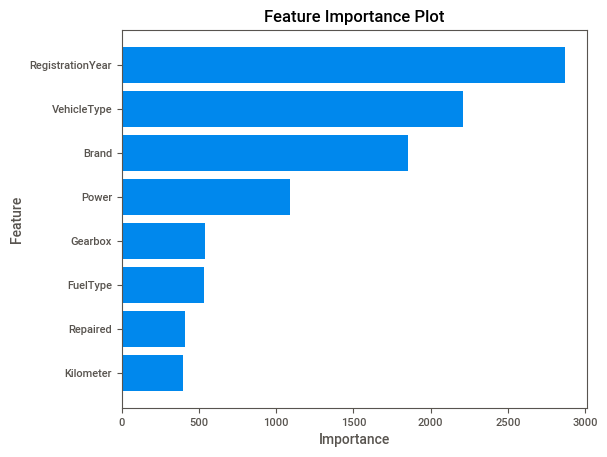

In [74]:
# Получим важность признаков
feature_importance = best_lgbmr_model.named_steps['model_lgbmr'].feature_importances_

# Получим названия признаков
feature_names = X_train.columns 

# Создадим DataFrame
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})

# Отсортируем DataFrame по важности признаков
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=True)

# Выведите график важности признаков
plt.figure(figsize=(6, 5))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance Plot')
plt.show()

Самым важным признаком в процессе моделирования является год регистрации автомобиля (RegistrationYear), самым незначитительным - пробег автомобиля (Kilometer).

### Вывод

На данном этапе исследования обучили лучшую модель (LGBM Regressor) на лучших гиперпараметрах, получили предсказания цен автомобилей на тестовой выборке. Замерили качество модели (RMSE) на тестовой выборке: 1556.90, что является хорошим показателям качества модели.
Также проанализировали важность признаков в процессе моделирования. Топ-3 важнейших признаков:
1. RegistrationYear - год регистрации автомобиля 
2. VehicleType — тип автомобильного кузова
3. Brand — марка автомобиля

## Вывод

**На этапе предобработки и исследовательского анализа данных:**. 

* Проверили и обработали типы значений в датасете 
* Проверим количество пропущенных значений для каждого столбца и избавились от пропусков   
* Удалили признаки, не влияющие на обучение моделей 
* Обработали аномалии и выбросы
* Изучили взаимосвязь между целевым и прочими признаками: 
    - Цены стремительно растут на автомобили, зарегистрированне с 1995г, резкий спад цен на автомобили, зарегистрированных в 2016 (т.к. выгрузка анкет датируется 2016 г).
    - Чем больше мощность автомобиля, тем выше цена (пропускаем интервал значений от 0 до 50 - это ошибки или заглушки для отсутствующих данных)
    - Чем меньше пробег у автомобилей, тем они дороже
    - Дороже всего автомобили с типом кузова: 'suv', дешевле всего - 'small'
    - Дороже всего автомобили с автоматической коробкой передач
    - Дороже всего автомобили с типом топлива: 'hybrid', 'gasoline', дешевле с 'petrol' и 'other'
    - Дороже стоят автомобили, не подвергавшиеся ремонту
    - Самый дорогой бренд автомобилей: porshe, самый дешевый: daewoo
    - Самая дорогая модель: gl, самая дешевая - samara
  
* Проверили значения на мультиколлинеарность. Удалили Model, так как он коррелирует с несколькими признаками, преодолевает пороговое значение 0.7
* Проверили датасет и удалили явные дубликаты

* Отобрали признаки для обучения моделей: 'VehicleType', 'RegistrationYear', 'Gearbox', 'Power', 'Kilometer', 'FuelType', 'Brand', 'Repaired'
* Целевой признак: 'Price'
    

**На этапе обучения моделей:**  

Было обучено 4 модели на тренировочном датасете с подбором лучших гиперпараметров, замером временем обучения, скорости предсказания и RMSE.

**На этапе анализа моделей**

| Модель                 | Время обучения | Скорость предсказания | RMSE           |
|------------------------|----------------|-----------------------|----------------|
| LinearRegression       | 3.323306       | 0.104598              | 2465.956623    |
| RandomForestRegressor  | 3.948922       | 0.176233              | 1579.005412    |
| LGBMRegressor          | 4.462087       | 0.302818              | 1530.594900    |
| CatBoostRegressor      | 4.155844       | 0.060371              | 1584.821281    |


Была выбрана лучшая модель LGBM Regressor, так как предоставляет хороший баланс между ключевыми параметрами:

* Время обучения: 4.46 сек  
* Скорость предсказания: 0.30 сек  
* RMSE: 1530.59 (по условиям заказчика, RMSE должно быть ниже 2500)  

**На этапе обучения лучшей модели и предсказания на тестовой выборке**

Обучили лучшую модель (LGBM Regressor) на лучших гиперпараметрах, получили предсказания цен автомобилей на тестовой выборке. Замерили качество модели (RMSE) на тестовой выборке: 1556.90, что является хорошим показателям качества модели. 

Также проанализировали важность признаков в процессе моделирования. 

Топ-3 важнейших признаков:

1. RegistrationYear - год регистрации автомобиля
2. VehicleType — тип автомобильного кузова
3. Brand — марка автомобиля